# Preprocesamiento

## 1. Carga del archivo

## 2. GSE derivado

## 3. Etiquetas limpias

## 4. Diccionario de variables originales

In [ ]:
# # Buscar variable por nombre o fragmento de etiqueta# busqueda = ''# diccionario[#     diccionario['variable'].str.contains(busqueda, case=False) |#     diccionario['etiqueta'].str.contains(busqueda, case=False, na=False)# ]

,variable,etiqueta
37,P1,P1. ¿Algunos miembros de este hogar tienen acc...
54,P5_1,P5_1 .- ¿Con qué compañía tiene contratado el ...
56,P5_2,P5_2 .- ¿Con qué compañía tiene contratado el ...
58,P5_3_1,Entel [P5_3 .- ¿Con qué compañía tiene contrat...
59,P5_3_2,Claro [P5_3 .- ¿Con qué compañía tiene contrat...
...,...,...
222,Q7_2_1,"SÍ, 4G [Q7.- 2 ¿El smartphone que usted utiliz..."
223,Q7_2_2,"Sí, 5G [Q7.- 2 ¿El smartphone que usted utiliz..."
224,Q7_2_3,"NO, ninguna de las dos [Q7.- 2 ¿El smartphone ..."
225,Q7_2_4,No sabe [Q7.- 2 ¿El smartphone que usted utili...


## 5. Tratamiento NS/NR

Variables de montos usan `9999999` como código NS/NR.

## 6. Renombrado de variables

## 7. Recodificaciones

In [103]:
df = df.copy()

# Identificación
df['region'] = df['region'].map({
    1:'Tarapacá', 2:'Antofagasta', 3:'Atacama', 4:'Coquimbo', 5:'Valparaíso',
    6:"O'Higgins", 7:'Maule', 8:'Biobío', 9:'Araucanía', 10:'Los Lagos',
    11:'Aysén', 12:'Magallanes', 13:'Metropolitana', 14:'Los Ríos', 15:'Arica y Parinacota', 16:'Ñuble'
})
df['zona'] = df['zona'].map({1:'Urbana', 2:'Rural'})

# Sociodemográficas del entrevistado
df['sexo'] = df['sexo'].map({1:'Hombre', 2:'Mujer'})
df['educ'] = df['educ'].map(_mapa_educ)
df['educ_grupo'] = df['educ'].map({
    'Sin educación formal':'Básica o menos', 'Básica incompleta':'Básica o menos',
    'Básica completa':'Básica o menos', 'Media CH incompleta':'Media',
    'Media TP incompleta':'Media', 'Media CH completa':'Media', 'Media TP completa':'Media',
    'Superior técnica incompleta':'Superior', 'Superior técnica completa':'Superior',
    'Superior universitaria incompleta':'Superior', 'Superior universitaria completa':'Superior',
})
df['tramo_edad'] = pd.cut(df['edad'], bins=[0,17,29,44,59,200],
                          labels=['Menor de 18','18-29','30-44','45-59','60 y más'], right=True)
df['actividad'] = df['actividad'].map({
    1:'Trabajador independiente', 2:'Empleador/patrón', 3:'Empleado dependiente',
    4:'Familiar no remunerado', 5:'FFAA y de orden', 6:'Cesante',
    7:'Jubilado/pensionado', 8:'Estudiante', 9:'Labores del hogar'
})

# Acceso a internet
df['acceso_internet_hogar'] = df['acceso_internet_hogar'].map({1:'Sí', 2:'No'})
df['tipo_acceso_fijo'] = df['tipo_acceso_fijo'].map({
    1:'ADSL', 2:'Cable/Módem', 3:'Fibra óptica', 4:'Inalámbrica',
    5:'Satelital', 31:'WiFi', 32:'Antena', 33:'Banda ancha', 34:'Acceso telefónico', 88:'No sabe'
})
df['velocidad_contratada'] = df['velocidad_contratada'].map({
    1:'Hasta 10 Mbps', 2:'Más de 10 a 100 Mbps', 3:'Más de 100 a 500 Mbps',
    4:'Más de 500 Mbps a 1 Gbps', 5:'Más de 1 Gbps', 99:'NS/NR'
})
df['tipo_plan'] = df['tipo_plan'].map({
    1:'Banda ancha desnuda', 2:'BA + TV Cable', 3:'BA + Telefonía fija',
    4:'Triple pack (BA+TV+Tel)', 5:'Otros planes'
})
df['tipo_acceso_mas_usado'] = df['tipo_acceso_mas_usado'].map({
    1.0:'Banda Ancha Fija / WiFi', 2.0:'Banda Ancha Móvil',
    3.0:'Internet Móvil (Smartphone/Tablet)', 4.0:'Conexión Satelital'
})

# Uso individual
df['uso_computador']  = df['uso_computador'].map({1:'Sí', 2:'No'})
df['uso_smartphone']  = df['uso_smartphone'].map({1:'Sí', 2:'No'})
df['ultimo_uso_internet'] = df['ultimo_uso_internet'].map({
    1:'Hoy', 2:'Entre 2 y 3 días', 3:'Entre 3 y 7 días', 4:'Entre 1 y 4 semanas',
    5:'Más de 4 semanas', 6:'Más de 12 meses', 7:'Nunca'
})
df['frecuencia_internet'] = df['frecuencia_internet'].map({
    1:'Todos los días', 2:'Varias veces por semana',
    3:'Al menos una vez al mes', 4:'Menos de una vez al mes'
})
df['tiempo_diario_internet'] = df['tiempo_diario_internet'].map({
    1:'Menos de 1 hora', 2:'Entre 1 y 2 horas', 3:'Entre 2 y 4 horas', 4:'Más de 4 horas'
})

# Percepciones
df['percepcion_proteccion']     = df['percepcion_proteccion'].map({
    1:'Muy protegido', 2:'Protegido', 3:'Desprotegido', 4:'Muy desprotegido', 99:'NS/NR'
})
df['internet_mejora_vida']      = df['internet_mejora_vida'].map({1:'Sí', 2:'No'})
df['internet_facilita_trabajo'] = df['internet_facilita_trabajo'].map({1:'Sí', 2:'No'})

print('Recodificaciones completadas.')
print(f"sexo: {df['sexo'].value_counts().to_dict()}")
print(f"acceso: {df['acceso_internet_hogar'].value_counts().to_dict()}")

Recodificaciones completadas.
sexo: {'Mujer': 2815, 'Hombre': 2185}
acceso: {'Sí': 4841, 'No': 159}


In [104]:
_rangos = {
    11:(0,129000),12:(130000,226000),13:(227000,393000),14:(394000,686000),15:(687000,1100000),16:(1200000,2000000),17:(2100000,None),
    21:(0,210000),22:(211000,366000),23:(367000,639000),24:(640000,1100000),25:(1200000,1900000),26:(2000000,3300000),27:(3400000,None),
    31:(0,279000),32:(280000,487000),33:(488000,849000),34:(850000,1400000),35:(1500000,2500000),36:(2600000,4500000),37:(4600000,None),
    41:(0,341000),42:(342000,595000),43:(596000,1000000),44:(1100000,1800000),45:(1900000,3100000),46:(3200000,5500000),47:(5600000,None),
    51:(0,399000),52:(400000,696000),53:(697000,1200000),54:(1300000,2100000),55:(2200000,3600000),56:(3700000,6400000),57:(6500000,None),
    61:(0,453000),62:(454000,791000),63:(792000,1300000),64:(1400000,2400000),65:(2500000,4100000),66:(4200000,7300000),67:(7400000,None),
    71:(0,505000),72:(506000,881000),73:(882000,1500000),74:(1600000,2600000),75:(2700000,4600000),76:(4700000,8100000),77:(8200000,None),
    81:(0,555000),82:(556000,967000),83:(968000,1600000),84:(1700000,2900000),85:(3000000,5100000),86:(5200000,8900000),87:(9000000,None),
    91:(0,602000),92:(603000,1000000),93:(1100000,1800000),94:(1900000,3100000),95:(3200000,5500000),96:(5600000,9700000),97:(9800000,None),
    101:(0,648000),102:(649000,1100000),103:(1200000,1900000),104:(2000000,3400000),105:(3500000,5900000),106:(6000000,10400000),107:(10500000,None),
}
_mapa_pm = {float(k): (v[0]*1.5 if v[1] is None else (v[0]+v[1])/2) for k, v in _rangos.items()}

df['ingreso_pm'] = df['ingreso_hogar'].map(_mapa_pm)
df['ingreso_tramo'] = pd.cut(
    df['ingreso_pm'],
    bins=[0, 384000, 540000, 798000, 1100000, 1700000, float('inf')],
    labels=['Hasta $384 mil','$384 mil a $540 mil','$540 mil a $798 mil',
            '$798 mil a $1,1 millón','$1,1 millón a $1,7 millones','Más de $1,7 millones'],
    right=True
)
df['ingreso_grupo'] = df['ingreso_tramo'].map({
    'Hasta $384 mil':'Bajo', '$384 mil a $540 mil':'Bajo',
    '$540 mil a $798 mil':'Medio', '$798 mil a $1,1 millón':'Medio',
    '$1,1 millón a $1,7 millones':'Alto', 'Más de $1,7 millones':'Alto',
})

# Validación: promedio de ingreso debe subir de E a AB
(
    df.groupby('gse', observed=True)['ingreso_pm']
    .agg(N='count', Promedio='mean').reindex(_ORDEN_GSE).round(0).astype({'N':int,'Promedio':int})
)

,N,Promedio
gse,,
AB,286,2097505
C1,444,1389884
C2,826,986176
C3,1112,799533
D,704,650022
E,846,539833


In [105]:
ORDEN_CATEGORIAS = {
    'sexo':         ['Hombre','Mujer'],
    'zona':         ['Urbana','Rural'],
    'region':       ['Tarapacá','Antofagasta','Atacama','Coquimbo','Valparaíso',"O'Higgins",'Maule',
                     'Biobío','Araucanía','Los Lagos','Aysén','Magallanes','Metropolitana',
                     'Los Ríos','Arica y Parinacota','Ñuble'],
    'educ':         ['Sin educación formal','Básica incompleta','Básica completa',
                     'Media CH incompleta','Media TP incompleta','Media CH completa','Media TP completa',
                     'Superior técnica incompleta','Superior técnica completa',
                     'Superior universitaria incompleta','Superior universitaria completa'],
    'educ_grupo':   ['Básica o menos','Media','Superior'],
    'tramo_edad':   ['Menor de 18','18-29','30-44','45-59','60 y más'],
    'actividad':    ['Trabajador independiente','Empleador/patrón','Empleado dependiente',
                     'Familiar no remunerado','FFAA y de orden','Cesante',
                     'Jubilado/pensionado','Estudiante','Labores del hogar'],
    'ocupacion_jh': ['Trabajos ocasionales e informales','Oficio menor - obrero no calificado',
                     'Obrero calificado - microempresario','Empleado medio - técnico - prof. independiente',
                     'Ejecutivo medio - prof. universitario','Alto ejecutivo - empresario - directivo'],
    'ocupacion_encuestado': ['Trabajos ocasionales e informales','Oficio menor - obrero no calificado',
                     'Obrero calificado - microempresario','Empleado medio - técnico - prof. independiente',
                     'Ejecutivo medio - prof. universitario','Alto ejecutivo - empresario - directivo',
                     'Sin trabajo remunerado'],
    'gse':              ['AB', 'C1', 'C2', 'C3', 'D', 'E'],
    'ingreso_tramo':    ['Hasta $384 mil','$384 mil a $540 mil','$540 mil a $798 mil',
                         '$798 mil a $1,1 millón','$1,1 millón a $1,7 millones','Más de $1,7 millones'],
    'ingreso_grupo':    ['Bajo','Medio','Alto'],
    'acceso_internet_hogar':    ['Sí','No'],
    'uso_computador':           ['Sí','No'],
    'uso_smartphone':           ['Sí','No'],
    'internet_mejora_vida':     ['Sí','No'],
    'internet_facilita_trabajo':['Sí','No'],
    'tipo_acceso_fijo':         ['Fibra óptica','Cable/Módem','ADSL','Inalámbrica','Satelital','WiFi','Antena','Banda ancha','Acceso telefónico','No sabe'],
    'tipo_acceso_mas_usado':    ['Banda Ancha Fija / WiFi','Banda Ancha Móvil','Internet Móvil (Smartphone/Tablet)','Conexión Satelital'],
    'tipo_plan':                ['Banda ancha desnuda','BA + TV Cable','BA + Telefonía fija','Triple pack (BA+TV+Tel)','Otros planes'],
    'ultimo_uso_internet':      ['Hoy','Entre 2 y 3 días','Entre 3 y 7 días',
                                 'Entre 1 y 4 semanas','Más de 4 semanas','Más de 12 meses','Nunca'],
    'frecuencia_internet':      ['Todos los días','Varias veces por semana',
                                 'Al menos una vez al mes','Menos de una vez al mes'],
    'tiempo_diario_internet':   ['Menos de 1 hora','Entre 1 y 2 horas','Entre 2 y 4 horas','Más de 4 horas'],
    'percepcion_proteccion':    ['Muy protegido','Protegido','Desprotegido','Muy desprotegido','NS/NR'],
    'velocidad_contratada':     ['Hasta 10 Mbps','Más de 10 a 100 Mbps','Más de 100 a 500 Mbps',
                                 'Más de 500 Mbps a 1 Gbps','Más de 1 Gbps','NS/NR'],
}


def fordf(df_tabla, titulo=None):
    """Formato visual: porcentajes con 1 decimal."""
    num_cols = df_tabla.select_dtypes(include=['number']).columns
    estilo = df_tabla.style.format({col: '{:.1f}' for col in num_cols})
    if titulo:
        estilo = estilo.set_caption(titulo)
    return estilo


def _ordenar(df_res, var, cruzada=False):
    """Reordena filas según ORDEN_CATEGORIAS. 'Total' siempre al final si existe."""
    if var not in ORDEN_CATEGORIAS:
        return df_res
    orden = ORDEN_CATEGORIAS[var]

    if cruzada:
        # El índice ya es la variable → reordenar filas directamente
        ok  = [v for v in orden if v in df_res.index]
        rst = [v for v in df_res.index if v not in ok and v != 'Total']
        # FIX 3: solo agregar 'Total' al reindex si efectivamente existe en el índice
        total_fila = ['Total'] if 'Total' in df_res.index else []
        return df_res.reindex(ok + rst + total_fila)

    # La variable es una columna → ordenar con pd.Categorical
    ok  = [v for v in orden if v in df_res[var].values]
    rst = [v for v in df_res[var].values if v not in ok and v != 'Total']
    # FIX 3: solo agregar 'Total' como categoría si existe en los datos
    total_cats = ['Total'] if 'Total' in df_res[var].values else []
    df_res[var] = pd.Categorical(df_res[var], categories=ok + rst + total_cats, ordered=True)
    return df_res.sort_values(var).reset_index(drop=True)


def dstats(data_df, variables, tipo='frecuencia', cruce=None, factor=None,
           transponer=False, estilo=True):
    """
    Análisis ponderado — solo porcentajes.
    Nota: NaN excluidos (porcentajes sobre casos válidos, como SPSS).
    """
    if isinstance(variables, str):
        variables = [variables]

    # FIX 1: excluir None de la lista de columnas a validar
    cols_a_verificar = variables + ([factor] if factor else []) + ([cruce] if cruce else [])
    for col in cols_a_verificar:
        if col not in data_df.columns:
            raise ValueError(f"Columna '{col}' no existe en el DataFrame.")

    # FIX 2: validar que cruce esté definido cuando tipo='cruzada'
    if tipo == 'cruzada' and cruce is None:
        raise ValueError("Para tipo='cruzada' debes especificar el parámetro 'cruce'.")

    # --- FRECUENCIA ---
    if tipo == 'frecuencia':
        var = variables[0]
        df_valid = data_df[data_df[var].notna()]
        tot = df_valid[factor].sum()
        res = (df_valid
               .groupby(var, observed=True)[factor]
               .sum()
               .reset_index()
               .rename(columns={factor: 'porcentaje'}))
        res['porcentaje'] = (res['porcentaje'] / tot * 100).round(2)
        res = _ordenar(res, var).set_index(var)

        if estilo:
            titulo = f"Frecuencia: '{var}' — base ponderada: {int(tot):,} ({factor})"
            return fordf(res, titulo=titulo)
        return res

    # --- CRUZADA ---
    if tipo == 'cruzada':
        var = variables[0]
        df_valid = data_df[data_df[var].notna()]
        tot = df_valid[factor].sum()
        # FIX 5: observed=True para evitar combinaciones fantasma con pandas moderno
        t  = df_valid.pivot_table(values=factor, index=var, columns=cruce,
                                  aggfunc='sum', fill_value=0, observed=True)
        tp = t.div(t.sum(axis=0), axis=1).mul(100).round(2)

        if var in ORDEN_CATEGORIAS:
            of = [v for v in ORDEN_CATEGORIAS[var] if v in t.index]
            tp = tp.reindex(of)
        if cruce in ORDEN_CATEGORIAS:
            oc = [v for v in ORDEN_CATEGORIAS[cruce] if v in tp.columns]
            tp = tp[oc]
        if transponer:
            tp = tp.T
        res = tp

        if estilo:
            titulo = f"Cruce: '{var}' según '{cruce}' — base ponderada: {int(tot):,} ({factor})"
            return fordf(res, titulo=titulo)
        return res

    # --- PROMEDIO / SUMA ---
    def _wavg(sub, v, f):
        d = sub[[v, f]].dropna()
        return float(round(np.average(d[v], weights=d[f]), 4)) if len(d) > 0 and d[f].sum() > 0 else np.nan

    def _wsum(sub, v, f):
        d = sub[[v, f]].dropna()
        return float(round((d[v] * d[f]).sum(), 4))

    fn       = _wavg if tipo == 'promedio' else _wsum
    col_name = 'promedio_ponderado' if tipo == 'promedio' else 'suma_ponderada'

    # Sin cruce: un valor por variable
    if not cruce:
        res = pd.DataFrame(
            [(v, fn(data_df, v, factor)) for v in variables],
            columns=['variable', col_name]
        )
        if estilo:
            titulo = f"{tipo.capitalize()} de variables — factor: {factor}"
            return fordf(res, titulo=titulo)
        return res

    # Con cruce: una fila por categoría del cruce
    filas = {
        g: {v: fn(sg, v, factor) for v in variables}
        for g, sg in data_df.groupby(cruce, observed=True)
    }
    res = pd.DataFrame(filas).T
    res.index.name = cruce

    if cruce in ORDEN_CATEGORIAS:
        ok  = [v for v in ORDEN_CATEGORIAS[cruce] if v in res.index]
        rst = [v for v in res.index if v not in ok and v != 'Total']
        # FIX 4: solo incluir 'Total' en reindex si existe en el índice
        total_fila = ['Total'] if 'Total' in res.index else []
        res = res.reindex(ok + rst + total_fila)

    if estilo:
        titulo = f"{tipo.capitalize()} cruzado por '{cruce}' — factor: {factor}"
        return fordf(res, titulo=titulo)
    return res


print('dstats: porcentajes sobre casos válidos (NaN excluidos).')

dstats: porcentajes sobre casos válidos (NaN excluidos).


In [106]:
_c = df.columns

GRUPOS_RM = {
    # Hogar
    'A12':  ('Pueblos indígenas o tribales (hogar)',            [c for c in _c if c.startswith('A12_') and not c.startswith('A12_1')]),
    'A13':  ('Condiciones permanentes de salud en el hogar',   [c for c in _c if c.startswith('A13_')]),
    'A14':  ('Situaciones laborales en el hogar',              [c for c in _c if c.startswith('A14_') and not c.endswith('_OTRA')]),
    # Acceso y conectividad
    'P3':   ('Dispositivos usados para acceder a internet',    [c for c in _c if c.startswith('P3_') and not c.endswith('_OTRA')]),
    'P4':   ('Formas de acceso pagado a internet en el hogar', [c for c in _c if c.startswith('P4_')]),
    'P6':   ('Razones para tener internet fijo',               [c for c in _c if c.startswith('P6_') and not c.startswith('P6_1_') and not c.endswith('_OTRA')]),
    'P6_1': ('Razones para tener internet móvil',              [c for c in _c if c.startswith('P6_1_')]),
    'P7':   ('Medidas de protección internet para menores',    [c for c in _c if c.startswith('P7_')]),
    'P8_3': ('Descripción P8_3',                               [c for c in _c if c.startswith('P8_3_')]),
    'P9':   ('Dispositivos de uso personal de menores',        [c for c in _c if c.startswith('P9_')]),
    'P12':  ('Conexión móvil 4G/5G',                           ['P12_11','P12_21','P12_31','P12_41']),
    'P13':  ('Razones de no acceso a internet fijo',           [c for c in _c if c.startswith('P13_') and not c.endswith('_OTRA')]),
    'P16':  ('Equipos que le interesaría tener (sin internet)',[c for c in _c if c.startswith('P16_')]),
    # Uso individual
    'Q6':   ('¿Cómo aprendió a usar el computador?',           [c for c in _c if c.startswith('Q6_') and c not in ['Q6_1','Q6_OTRA']]),
    'Q7_2': ('Smartphone 4G/5G',                               ['Q7_2_1','Q7_2_2','Q7_2_3','Q7_2_4']),
    'Q8':   ('Habilidades digitales',                          [c for c in _c if c.startswith('Q8_')]),
    'Q11_1':('Lugares donde usó internet ayer',                [c for c in _c if c.startswith('Q11_1_')]),
    'Q12':  ('Tipos de acceso en últimos 3 meses',             [c for c in _c if c.startswith('Q12_')]),
    'Q20':  ('Lugares donde usó internet fuera del hogar',     [c for c in _c if c.startswith('Q20_')]),
    'Q21':  ('Actividades realizadas en internet',             [c for c in _c if c.startswith('Q21_') and c not in ['Q21_1','Q21_10','Q21_19','Q21_26','Q21_33','Q21_38','Q21_44']]),
    'Q28':  ('Bienes y servicios comprados en internet',       [c for c in _c if c.startswith('Q28_') and not c.endswith('_OTRA')]),
    'Q32':  ('Actividades de seguridad y privacidad',          [c for c in _c if c.startswith('Q32_') and not c.endswith('_OTRA')]),
    'Q33':  ('Problemas de seguridad sufridos',                [c for c in _c if c.startswith('Q33_') and not c.endswith('_OTRA')]),
    'Q34':  ('Razones de no uso de internet',                  [c for c in _c if c.startswith('Q34_') and not c.endswith('_OTRA')]),
    'Q37':  ('Actividades de internet realizadas por terceros',[c for c in _c if c.startswith('Q37_')]),
    'Q39':  ('Equipos que le interesaría tener (no usuarios)', [c for c in _c if c.startswith('Q39_')]),
}

def analizar_rm(grupo, factor='fe_hogar', top_n=None, estilo=True):
    """
    Analiza grupo de respuesta múltiple — porcentajes sobre casos válidos (NaN excluidos).
    """
    if grupo not in GRUPOS_RM:
        raise ValueError(f"Grupo '{grupo}' no existe.")
    
    desc, cols = GRUPOS_RM[grupo]
    cols = [c for c in cols if c in df.columns]
    
    # construir filas con datos de cada variable
    filas = []
    for c in cols:
        # contar valores == 1 con factor ponderado
        numerador = df.loc[df[c] == 1, factor].sum()
        # contar válidos (no NaN) con factor ponderado
        denominador = df.loc[df[c].notna(), factor].sum()
        # calcular porcentaje
        porcentaje = round(numerador / denominador * 100, 1) if denominador > 0 else 0
        
        filas.append({
            'variable': c,
            'etiqueta': etiquetas_limpias.get(c, c),
            'porcentaje': porcentaje
        })
    
    # convertir a DataFrame y ordenar
    res = pd.DataFrame(filas).sort_values('porcentaje', ascending=False).reset_index(drop=True)
    
    if top_n:
        res = res.head(top_n)
    
    res.index += 1
    
    if estilo:
        base_ponderada = df.loc[df[cols].notna().any(axis=1), factor].sum()
        titulo_tabla = f"{desc} — base ponderada: {int(base_ponderada):,} ({factor})"
        return fordf(res, titulo=titulo_tabla)
    
    return res

# listar grupos disponibles
print("Grupos de respuesta múltiple disponibles:")
for k, (desc, cols) in GRUPOS_RM.items():
    cols_validas = [c for c in cols if c in df.columns]
    print(f"  '{k}': {desc} ({len(cols_validas)} opciones)")

Grupos de respuesta múltiple disponibles:
  'A12': Pueblos indígenas o tribales (hogar) (8 opciones)
  'A13': Condiciones permanentes de salud en el hogar (7 opciones)
  'A14': Situaciones laborales en el hogar (8 opciones)
  'P3': Dispositivos usados para acceder a internet (8 opciones)
  'P4': Formas de acceso pagado a internet en el hogar (5 opciones)
  'P6': Razones para tener internet fijo (13 opciones)
  'P6_1': Razones para tener internet móvil (13 opciones)
  'P7': Medidas de protección internet para menores (12 opciones)
  'P8_3': Descripción P8_3 (5 opciones)
  'P9': Dispositivos de uso personal de menores (4 opciones)
  'P12': Conexión móvil 4G/5G (4 opciones)
  'P13': Razones de no acceso a internet fijo (29 opciones)
  'P16': Equipos que le interesaría tener (sin internet) (5 opciones)
  'Q6': ¿Cómo aprendió a usar el computador? (12 opciones)
  'Q7_2': Smartphone 4G/5G (4 opciones)
  'Q8': Habilidades digitales (19 opciones)
  'Q11_1': Lugares donde usó internet ayer (9 o

## 11. Habilidades digitales Q8

### Habilidades por nivel

In [110]:
# Tabla de habilidades por nivel — porcentajes ponderados
dstats(df, 'nivel_habilidades', tipo='frecuencia', factor='fe_personas')

,porcentaje
nivel_habilidades,
Avanzado,41.1
Básico,11.5
Intermedio,41.4
Sin habilidades,6.0


In [111]:
# ── Clasificación de Habilidades Digitales Q8 por tipo de uso (PONDERADO) ──────────

Q8_PRODUCTIVAS = {
    'Q8_1':  'Procesador de texto (Word)',
    'Q8_2':  'Planilla de cálculo (Excel)',
    'Q8_3':  'Presentaciones (PowerPoint)',
    'Q8_4':  'Transferir archivos / nube',
    'Q8_5':  'Conectar nuevo dispositivo',
    'Q8_6':  'Instalar y configurar apps',
    'Q8_7':  'Configurar seguridad del dispositivo',
    'Q8_8':  'Instalar SO / programar (Python, Java…)',
    'Q8_17': 'Transacciones y pagos en línea',
    'Q8_18': 'Uso de IA (ChatGPT, etc.)',
}

Q8_RECREATIVAS = {
    'Q8_10': 'Streaming (video/música)',
    'Q8_11': 'Juegos en línea',
    
}

Q8_CREATIVIDAD ={
    'Q8_14': 'Editar fotos o videos',
    'Q8_9':  'Crear un sitio web',
}

Q8_COMUNICACIONES = {
    'Q8_12': 'Revisar redes sociales',
    'Q8_13': 'Publicar en redes sociales',
    'Q8_15': 'Videollamadas',
    'Q8_16': 'Correo electrónico',
}

_cols_prod  = list(Q8_PRODUCTIVAS)
_cols_rec   = list(Q8_RECREATIVAS)
_cols_crea  = list(Q8_CREATIVIDAD)
_cols_com   = list(Q8_COMUNICACIONES)
_cols_q8_tipos = _cols_prod + _cols_rec + _cols_crea + _cols_com + ['Q8_19']

def _tipo_principal(row):
    """Clasifica tipo principal de habilidades — primero verifica productivas, luego recreativas, luego comunicaciones."""
    if any(row[c] == 'Sí' for c in _cols_prod if pd.notna(row[c])):
        return 'Productivas'
    if any(row[c] == 'Sí' for c in _cols_rec if pd.notna(row[c])):
        return 'Recreativas'
    if any(row[c] == 'Sí' for c in _cols_crea if pd.notna(row[c])):
        return 'Creativas'
    if any(row[c] == 'Sí' for c in _cols_com if pd.notna(row[c])):
        return 'Comunicaciones'
    return 'Sin habilidades'

# Crear tipo_habilidades_principal
df['tipo_habilidades_principal'] = df.apply(_tipo_principal, axis=1)
mask_q8 = df[_cols_q8_tipos].notna().any(axis=1)

# Análisis ponderado por fe_personas
factor = 'fe_personas'
base_ponderada = df.loc[mask_q8, factor].sum()
base_ponderada_int = int(base_ponderada)

print(f"Base ponderada (fe_personas): {base_ponderada_int:,}\n")
print("Distribución por tipo (PONDERADA):")

orden_tipo = ['Productivas', 'Recreativas', 'Creativas', 'Comunicaciones', 'Sin habilidades']
for tipo in orden_tipo:
    n_pond = df.loc[mask_q8 & (df['tipo_habilidades_principal'] == tipo), factor].sum()
    pct = (n_pond / base_ponderada * 100) if base_ponderada > 0 else 0
    print(f"  {tipo:<20} {int(n_pond):>10,}  ({pct:.1f}%)")

print("\n── Habilidades por tipo (PONDERADO) ──────────────────────────────────────────────")
for tipo, items in [('PRODUCTIVAS', Q8_PRODUCTIVAS), ('RECREATIVAS', Q8_RECREATIVAS), ('CREATIVAS', Q8_CREATIVIDAD), ('COMUNICACIONES', Q8_COMUNICACIONES)]:
    print(f"\n{tipo}")
    for cod, desc in items.items():
        n_pond = df.loc[mask_q8 & (df[cod] == 'Sí'), factor].sum()
        pct = (n_pond / base_ponderada * 100) if base_ponderada > 0 else 0
        print(f"  {cod:<8} {desc:<45}  {int(n_pond):>10,} ({pct:.1f}%)")

Base ponderada (fe_personas): 13,286,225

Distribución por tipo (PONDERADA):
  Productivas          11,098,633  (83.5%)
  Recreativas             492,768  (3.7%)
  Creativas               179,815  (1.4%)
  Comunicaciones        1,206,445  (9.1%)
  Sin habilidades         308,563  (2.3%)

── Habilidades por tipo (PONDERADO) ──────────────────────────────────────────────

PRODUCTIVAS
  Q8_1     Procesador de texto (Word)                      7,898,264 (59.4%)
  Q8_2     Planilla de cálculo (Excel)                     6,665,163 (50.2%)
  Q8_3     Presentaciones (PowerPoint)                     6,910,830 (52.0%)
  Q8_4     Transferir archivos / nube                      7,115,863 (53.6%)
  Q8_5     Conectar nuevo dispositivo                      7,012,591 (52.8%)
  Q8_6     Instalar y configurar apps                      6,951,460 (52.3%)
  Q8_7     Configurar seguridad del dispositivo            5,125,336 (38.6%)
  Q8_8     Instalar SO / programar (Python, Java…)         3,053,129 (23.0%)

# Análisis

In [113]:
display(dstats(df, 'sexo', tipo='frecuencia', factor='fe_personas'))
display(dstats(df, 'region', tipo='frecuencia', factor='fe_personas'))
display(dstats(df, 'zona', tipo='frecuencia', factor='fe_personas'))
display(dstats(df, 'educ', tipo='frecuencia', factor='fe_personas'))
display(dstats(df, 'ocupacion_encuestado', tipo='frecuencia', factor='fe_personas'))
display(dstats(df, 'sexo', tipo='frecuencia', factor='fe_personas'))
display(dstats(df, 'tramo_edad', tipo='frecuencia', factor='fe_personas'))
display(dstats(df, 'gse', tipo='frecuencia', factor='fe_personas'))


,porcentaje
sexo,
Hombre,48.4
Mujer,51.6


,porcentaje
region,
Tarapacá,1.8
Antofagasta,3.4
Atacama,1.6
Coquimbo,4.2
Valparaíso,10.5
O'Higgins,5.2
Maule,5.9
Biobío,8.8
Araucanía,5.4


,porcentaje
zona,
Urbana,87.6
Rural,12.4


,porcentaje
educ,
Sin educación formal,0.3
Básica incompleta,4.3
Básica completa,6.5
Media CH incompleta,6.5
Media TP incompleta,3.4
Media CH completa,23.4
Media TP completa,9.0
Superior técnica incompleta,3.4
Superior técnica completa,11.2


,porcentaje
ocupacion_encuestado,
Trabajos ocasionales e informales,9.3
Oficio menor - obrero no calificado,7.0
Obrero calificado - microempresario,23.8
Empleado medio - técnico - prof. independiente,30.6
Ejecutivo medio - prof. universitario,9.4
Alto ejecutivo - empresario - directivo,1.0
Sin trabajo remunerado,18.9


,porcentaje
sexo,
Hombre,48.4
Mujer,51.6


,porcentaje
tramo_edad,
Menor de 18,1.2
18-29,25.8
30-44,29.9
45-59,21.1
60 y más,22.1


,porcentaje
gse,
AB,11.0
C1,13.4
C2,23.2
C3,23.5
D,15.2
E,13.7


In [114]:
display(dstats(df, 'sexo', tipo='frecuencia', factor='fe_hogar'))
display(dstats(df, 'region', tipo='frecuencia', factor='fe_hogar'))
display(dstats(df, 'zona', tipo='frecuencia', factor='fe_hogar'))
display(dstats(df, 'educ', tipo='frecuencia', factor='fe_hogar'))
display(dstats(df, 'ocupacion_encuestado', tipo='frecuencia', factor='fe_hogar'))
display(dstats(df, 'sexo', tipo='frecuencia', factor='fe_hogar'))
display(dstats(df, 'tramo_edad', tipo='frecuencia', factor='fe_hogar'))
display(dstats(df, 'gse', tipo='frecuencia', factor='fe_hogar'))


,porcentaje
sexo,
Hombre,45.2
Mujer,54.8


,porcentaje
region,
Tarapacá,1.7
Antofagasta,3.1
Atacama,1.6
Coquimbo,4.2
Valparaíso,10.8
O'Higgins,5.3
Maule,6.2
Biobío,9.0
Araucanía,5.6


,porcentaje
zona,
Urbana,87.6
Rural,12.4


,porcentaje
educ,
Sin educación formal,0.5
Básica incompleta,5.9
Básica completa,7.8
Media CH incompleta,7.3
Media TP incompleta,3.3
Media CH completa,23.8
Media TP completa,9.2
Superior técnica incompleta,2.9
Superior técnica completa,11.2


,porcentaje
ocupacion_encuestado,
Trabajos ocasionales e informales,10.1
Oficio menor - obrero no calificado,7.9
Obrero calificado - microempresario,25.2
Empleado medio - técnico - prof. independiente,30.1
Ejecutivo medio - prof. universitario,8.8
Alto ejecutivo - empresario - directivo,1.0
Sin trabajo remunerado,16.9


,porcentaje
sexo,
Hombre,45.2
Mujer,54.8


,porcentaje
tramo_edad,
Menor de 18,0.8
18-29,17.8
30-44,26.4
45-59,23.3
60 y más,31.8


,porcentaje
gse,
AB,10.0
C1,12.6
C2,22.4
C3,24.0
D,15.8
E,15.2


### Nacional (sin cruces)

### POR EDAD

### POR GSE

### POR REGION

### POR ZONA

### POR EDUCACIÓN JEFE DE HOGAR

### POR OCUPACIÓN JEFE DE HOGAR

### POR SEXO

# Habilidades (Personas)

## Habilidades por tipo

In [124]:
# Crear variable no_hab
# "Sí" si no tiene ninguna habilidad (todas las Q8_X son 0)
# "No" si tiene al menos una habilidad

df['no_hab'] = (df[todas_las_q8].sum(axis=1) == 0).map({True: 'Sí', False: 'No'})

print("\n=== VARIABLE NO_HAB ===")
print(f"Sin habilidades: {(df['no_hab'] == 'Sí').sum()}")
print(f"Con al menos una habilidad: {(df['no_hab'] == 'No').sum()}")


=== VARIABLE NO_HAB ===
Sin habilidades: 421
Con al menos una habilidad: 4579


In [126]:
# Tabla cruzada con solo porcentajes para variables tiene_x usando factor de expansión fe_personas
variables_tiene = ['tiene_basicas', 'tiene_intermedias', 'tiene_avanzadas', 
                   'tiene_productivas', 'tiene_recreativas', 'tiene_creatividad', 'tiene_comunicaciones']

resultados = []
for col in variables_tiene:
    total_expandido = df['fe_personas'].sum()
    cant_si_expandido = (df[df[col] == True]['fe_personas']).sum()
    cant_no_expandido = (df[df[col] == False]['fe_personas']).sum()
    porc_si = round((cant_si_expandido / total_expandido) * 100, 1)
    porc_no = round((cant_no_expandido / total_expandido) * 100, 1)
    
    resultados.append({
        'Clasificación': etiquetas_clasificacion[col],
        'Sí (%)': porc_si,
        'No (%)': porc_no,
    })

tabla_clasificacion = pd.DataFrame(resultados)
print(tabla_clasificacion.to_string(index=False))

                             Clasificación  Sí (%)  No (%)
          Tiene habilidades básicas (≥50%)    73.7    26.3
      Tiene habilidades intermedias (≥50%)    51.9    48.1
        Tiene habilidades avanzadas (≥50%)    22.9    77.1
      Tiene habilidades productivas (≥50%)    49.9    50.1
      Tiene habilidades recreativas (≥50%)    63.7    36.3
   Tiene habilidades de creatividad (≥50%)    60.7    39.3
Tiene habilidades de comunicaciones (≥50%)    82.3    17.7


In [128]:
dstats(df, 'no_hab', tipo='frecuencia', factor='fe_personas', estilo=True)

,porcentaje
no_hab,
No,94.0
Sí,6.0


In [146]:
# Tabla cruzada entre variables tiene_x y gse (solo porcentajes)
variables_tiene = ['tiene_basicas', 'tiene_intermedias', 'tiene_avanzadas', 
                   'tiene_productivas', 'tiene_recreativas', 'tiene_creatividad', 'tiene_comunicaciones']

for var in variables_tiene:
    print(f"\n=== {etiquetas_clasificacion[var]} ===")
    
    # Crear tabla cruzada ponderada
    tabla_cruzada = pd.crosstab(
        index=df[var],
        columns=df['zona'],
        values=df['fe_hogar'],
        aggfunc='sum'
    )
    
    # Convertir a porcentajes por columna (cada GSE suma 100%)
    tabla_porcentajes = tabla_cruzada.div(tabla_cruzada.sum(axis=0), axis=1) * 100
    tabla_porcentajes = tabla_porcentajes.round(1)
    
    # Renombrar índice para claridad
    tabla_porcentajes.index = ['No', 'Sí']
    
    print(tabla_porcentajes)


=== Tiene habilidades básicas (≥50%) ===
zona  Rural  Urbana
No     34.2    31.0
Sí     65.8    69.0

=== Tiene habilidades intermedias (≥50%) ===
zona  Rural  Urbana
No     62.2    54.5
Sí     37.8    45.5

=== Tiene habilidades avanzadas (≥50%) ===
zona  Rural  Urbana
No     86.2    79.9
Sí     13.8    20.1

=== Tiene habilidades productivas (≥50%) ===
zona  Rural  Urbana
No     63.8    56.2
Sí     36.2    43.8

=== Tiene habilidades recreativas (≥50%) ===
zona  Rural  Urbana
No     48.8    41.3
Sí     51.2    58.7

=== Tiene habilidades de creatividad (≥50%) ===
zona  Rural  Urbana
No     50.9    44.2
Sí     49.1    55.8

=== Tiene habilidades de comunicaciones (≥50%) ===
zona  Rural  Urbana
No     21.8    20.8
Sí     78.2    79.2


In [153]:
# Crear tabla con % "Sí" para cada clasificación de habilidad, por GSE y sexo
# Filas: etiquetas_clasificacion para variables_tiene; Columnas: MultiIndex (GSE, Sexo)
gses = orden_gse
sexos = ['Hombre', 'Mujer']

index = [etiquetas_clasificacion[v] for v in variables_tiene]
cols = pd.MultiIndex.from_product([gses, sexos], names=['GSE', 'Sexo'])
tabla_gse_sexo = pd.DataFrame(index=index, columns=cols, dtype=float)

# Calcular porcentajes ponderados por fe_personas
for g in gses:
    for s in sexos:
        mask_base = (df['gse'] == g) & (df['sexo'] == s)
        base = df.loc[mask_base, 'fe_personas'].sum()
        for v in variables_tiene:
            if base > 0:
                numerador = df.loc[mask_base & (df[v] == True), 'fe_personas'].sum()
                pct = round(numerador / base * 100, 1)
            else:
                pct = np.nan
            tabla_gse_sexo.loc[etiquetas_clasificacion[v], (g, s)] = pct

# Mostrar y guardar
display(tabla_gse_sexo)
tabla_gse_sexo.to_csv(f"{output_dir}/habilidades_por_gse_sexo.csv", encoding='utf-8-sig')
print(f"Guardado: {output_dir}/habilidades_por_gse_sexo.csv")

GSE                                            AB           C1           C2  \
Sexo                                       Hombre Mujer Hombre Mujer Hombre   
Tiene habilidades básicas (≥50%)             88.7  84.6   90.6  87.4   77.7   
Tiene habilidades intermedias (≥50%)         85.9  78.1   82.8  76.6   63.9   
Tiene habilidades avanzadas (≥50%)           56.5  37.0   36.2  24.1   35.1   
Tiene habilidades productivas (≥50%)         85.9  76.2   79.9  75.5   62.6   
Tiene habilidades recreativas (≥50%)         88.1  75.6   79.5  73.0   75.2   
Tiene habilidades de creatividad (≥50%)      79.8  76.2   80.6  76.0   67.2   
Tiene habilidades de comunicaciones (≥50%)   90.6  90.2   93.9  93.6   83.0   

GSE                                                  C3            D        \
Sexo                                       Mujer Hombre Mujer Hombre Mujer   
Tiene habilidades básicas (≥50%)            81.0   71.2  73.7   59.8  68.2   
Tiene habilidades intermedias (≥50%)        56.4   43.6  37.2   37.3  33.8   
Tiene habilidades avanzadas (≥50%)          16.7   21.0  12.7   17.4  11.9   
Tiene habilidades productivas (≥50%)        53.1   41.9  34.0   34.2  32.2   
Tiene habilidades recreativas (≥50%)        65.1   60.3  60.7   54.5  55.3   
Tiene habilidades de creatividad (≥50%)     66.0   53.4  56.1   52.4  51.3   
Tiene habilidades de comunicaciones (≥50%)  87.2   80.3  84.2   69.8  83.4   

GSE                                             E        
Sexo                                       Hombre Mujer  
Tiene habilidades básicas (≥50%)             55.9  48.0  
Tiene habilidades intermedias (≥50%)         35.4  18.7  
Tiene habilidades avanzadas (≥50%)           20.4   5.1  
Tiene habilidades productivas (≥50%)         34.1  17.7  
Tiene habilidades recreativas (≥50%)         48.0  36.1  
Tiene habilidades de creatividad (≥50%)      46.1  36.2  
Tiene habilidades de comunicaciones (≥50%)   65.8  66.1

Guardado: /Users/tomas/github/eaui_subtel/analysis/outputs/habilidades_por_gse_sexo.csv


In [155]:
# Tabla única: Habilidades por GSE (solo porcentajes ponderados por fe_personas)
variables_tiene = ['tiene_basicas', 'tiene_intermedias', 'tiene_avanzadas', 
                   'tiene_productivas', 'tiene_recreativas', 'tiene_creatividad', 
                   'tiene_comunicaciones']

etiquetas_habilidades = {
    'tiene_basicas': 'Habilidades básicas (≥50%)',
    'tiene_intermedias': 'Habilidades intermedias (≥50%)',
    'tiene_avanzadas': 'Habilidades avanzadas (≥50%)',
    'tiene_productivas': 'Habilidades productivas (≥50%)',
    'tiene_recreativas': 'Habilidades recreativas (≥50%)',
    'tiene_creatividad': 'Habilidades de creatividad (≥50%)',
    'tiene_comunicaciones': 'Habilidades de comunicaciones (≥50%)'
}

# Crear tabla
resultados = []
for var in variables_tiene:
    fila = {'Habilidad': etiquetas_habilidades[var]}
    
    for gse in orden_gse:
        mask = (df['gse'] == gse)
        base = df.loc[mask, 'fe_personas'].sum()
        numerador = df.loc[mask & (df[var] == True), 'fe_personas'].sum()
        pct = round(numerador / base * 100, 1) if base > 0 else 0
        fila[gse] = pct
    
    resultados.append(fila)

tabla_habilidades_gse = pd.DataFrame(resultados).set_index('Habilidad')

# Mostrar con formato
display(fordf(tabla_habilidades_gse, titulo='Habilidades por GSE (% Sí, ponderado por fe_personas)'))

# Guardar CSV
tabla_habilidades_gse.to_csv(f'{output_dir}/habilidades_por_gse.csv', encoding='utf-8-sig')
print(f'Guardado: {output_dir}/habilidades_por_gse.csv')

,AB,C1,C2,C3,D,E
Habilidad,,,,,,
Habilidades básicas (≥50%),87.0,89.2,79.4,72.5,64.2,50.7
Habilidades intermedias (≥50%),82.6,80.0,60.0,40.4,35.5,24.3
Habilidades avanzadas (≥50%),48.4,30.6,25.6,16.8,14.5,10.3
Habilidades productivas (≥50%),81.8,77.9,57.7,37.9,33.2,23.2
Habilidades recreativas (≥50%),82.9,76.5,69.9,60.5,54.9,40.1
Habilidades de creatividad (≥50%),78.3,78.5,66.6,54.7,51.8,39.5
Habilidades de comunicaciones (≥50%),90.5,93.8,85.2,82.2,76.9,66.0


Guardado: /Users/tomas/github/eaui_subtel/analysis/outputs/habilidades_por_gse.csv


In [235]:
# Librerías necesarias para MCA y clustering
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.preprocessing import OrdinalEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import prince
import warnings
import os

warnings.filterwarnings('ignore')

# Directorio de salida
output_dir = '/Users/tomas/github/eaui_subtel/analysis/outputs'
os.makedirs(output_dir, exist_ok=True)

# Variables a usar en el análisis
vars_hab   = ['tiene_basicas', 'tiene_intermedias', 'tiene_avanzadas',
              'tiene_productivas', 'tiene_recreativas', 'tiene_creatividad',
              'tiene_comunicaciones']
vars_socio = ['gse', 'educ', 'zona']
vars_mca   = vars_hab + vars_socio

# Subset limpio: sin nulos en ninguna de las 10 variables ni en fe_personas
df_mca = df[vars_mca + ['fe_personas']].dropna().copy()

# Las variables tiene_x son booleanas en el df original; las convertimos a 'Si'/'No'
# para que prince/MCA las trate como categóricas (strings)
for v in vars_hab:
    df_mca[v] = df_mca[v].map({True: 'Si', False: 'No', 'Sí': 'Si', 'No': 'No'}).fillna('No')

# Asegurar que sociodemográficas sean strings
for v in vars_socio:
    df_mca[v] = df_mca[v].astype(str)
print(f'Casos para análisis: {len(df_mca):,} de {len(df):,} totales')
print(f'Variables: {vars_mca}')


Casos para análisis: 5,000 de 5,000 totales
Variables: ['tiene_basicas', 'tiene_intermedias', 'tiene_avanzadas', 'tiene_productivas', 'tiene_recreativas', 'tiene_creatividad', 'tiene_comunicaciones', 'gse', 'educ', 'zona']


In [236]:
# Aplicar MCA con 2 componentes
mca = prince.MCA(n_components=2, random_state=42)
mca = mca.fit(df_mca[vars_mca])

# Coordenadas de individuos
coords_ind = mca.row_coordinates(df_mca[vars_mca])
coords_ind.columns = ['Dim1', 'Dim2']

# Coordenadas de categorías (loadings)
coords_cat = mca.column_coordinates(df_mca[vars_mca])
coords_cat.columns = ['Dim1', 'Dim2']

# Eigenvalues e inercia explicada
eigenvalues = mca.eigenvalues_
total_inercia = sum(eigenvalues)
pct_inercia = [round(e / total_inercia * 100, 2) for e in eigenvalues]

print('=== Eigenvalues y % de Inercia Explicada ===')
for i, (eig, pct) in enumerate(zip(eigenvalues, pct_inercia), 1):
    print(f'  Dimensión {i}: eigenvalue={eig:.4f}  ({pct}% inercia)')

print(f'\nInercia total acumulada (Dim1+Dim2): {sum(pct_inercia):.2f}%')


=== Eigenvalues y % de Inercia Explicada ===
  Dimensión 1: eigenvalue=0.4688  (74.15% inercia)
  Dimensión 2: eigenvalue=0.1635  (25.85% inercia)

Inercia total acumulada (Dim1+Dim2): 100.00%


### 2. K-Means Clustering

Realizando K-Means clustering en el espacio MCA...
K=2: Inertia=1314.47, Silhouette=0.515
K=3: Inertia=834.80, Silhouette=0.475
K=4: Inertia=495.08, Silhouette=0.492
K=5: Inertia=385.54, Silhouette=0.471
K=6: Inertia=318.54, Silhouette=0.485
K=7: Inertia=272.94, Silhouette=0.456
K=8: Inertia=240.51, Silhouette=0.463
K=9: Inertia=210.35, Silhouette=0.434
K=10: Inertia=188.33, Silhouette=0.427

K óptimo según Silhouette Score: 2

Distribución de clusters:
cluster
0    2188
1    2812
Name: count, dtype: int64


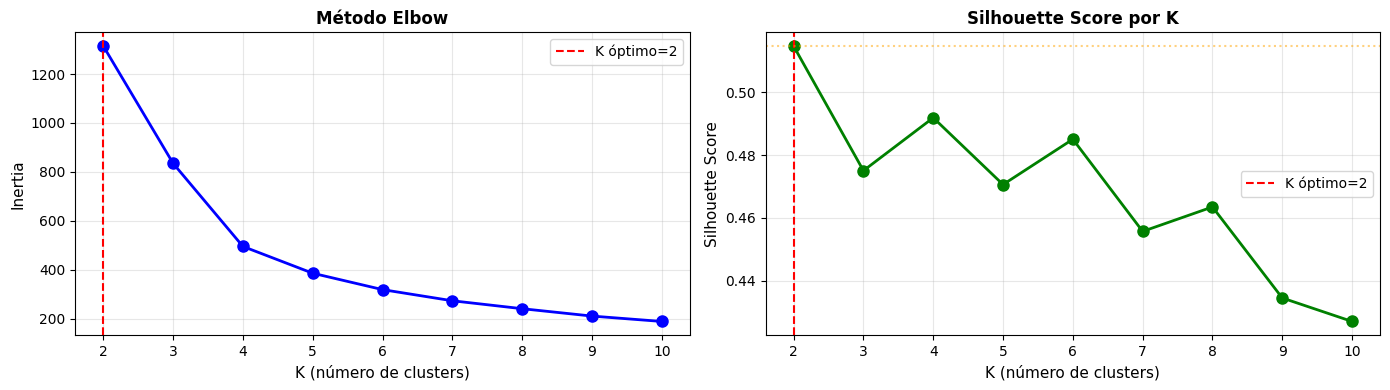

In [240]:
from sklearn.cluster import KMeans
import numpy as np
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# K-Means Clustering en el espacio MCA (mca_coords)
print("Realizando K-Means clustering en el espacio MCA...")

inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(mca_coords)
    inertias.append(kmeans_temp.inertia_)
    sil_score = silhouette_score(mca_coords, kmeans_temp.labels_)
    silhouette_scores.append(sil_score)
    print(f"K={k}: Inertia={kmeans_temp.inertia_:.2f}, Silhouette={sil_score:.3f}")

# Encontrar k óptimo (mejor silhouette score)
k_optimo = k_range[np.argmax(silhouette_scores)]
print(f"\nK óptimo según Silhouette Score: {k_optimo}")

# Fit final con k óptimo
kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
clusters_mca = kmeans_final.fit_predict(mca_coords)

# Agregar clusters al dataframe df_mca
df_mca['cluster'] = clusters_mca

print(f"\nDistribución de clusters:")
print(df_mca['cluster'].value_counts().sort_index())

# Visualizar elbow y silhouette scores
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.axvline(x=k_optimo, color='red', linestyle='--', label=f'K óptimo={k_optimo}')
ax1.set_xlabel('K (número de clusters)', fontsize=11)
ax1.set_ylabel('Inertia', fontsize=11)
ax1.set_title('Método Elbow', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
ax2.axvline(x=k_optimo, color='red', linestyle='--', label=f'K óptimo={k_optimo}')
ax2.axhline(y=max(silhouette_scores), color='orange', linestyle=':', alpha=0.5)
ax2.set_xlabel('K (número de clusters)', fontsize=11)
ax2.set_ylabel('Silhouette Score', fontsize=11)
ax2.set_title('Silhouette Score por K', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3. Visualización: Silhouette Score por k

### 4. Biplot MCA: individuos por cluster + loadings de variables

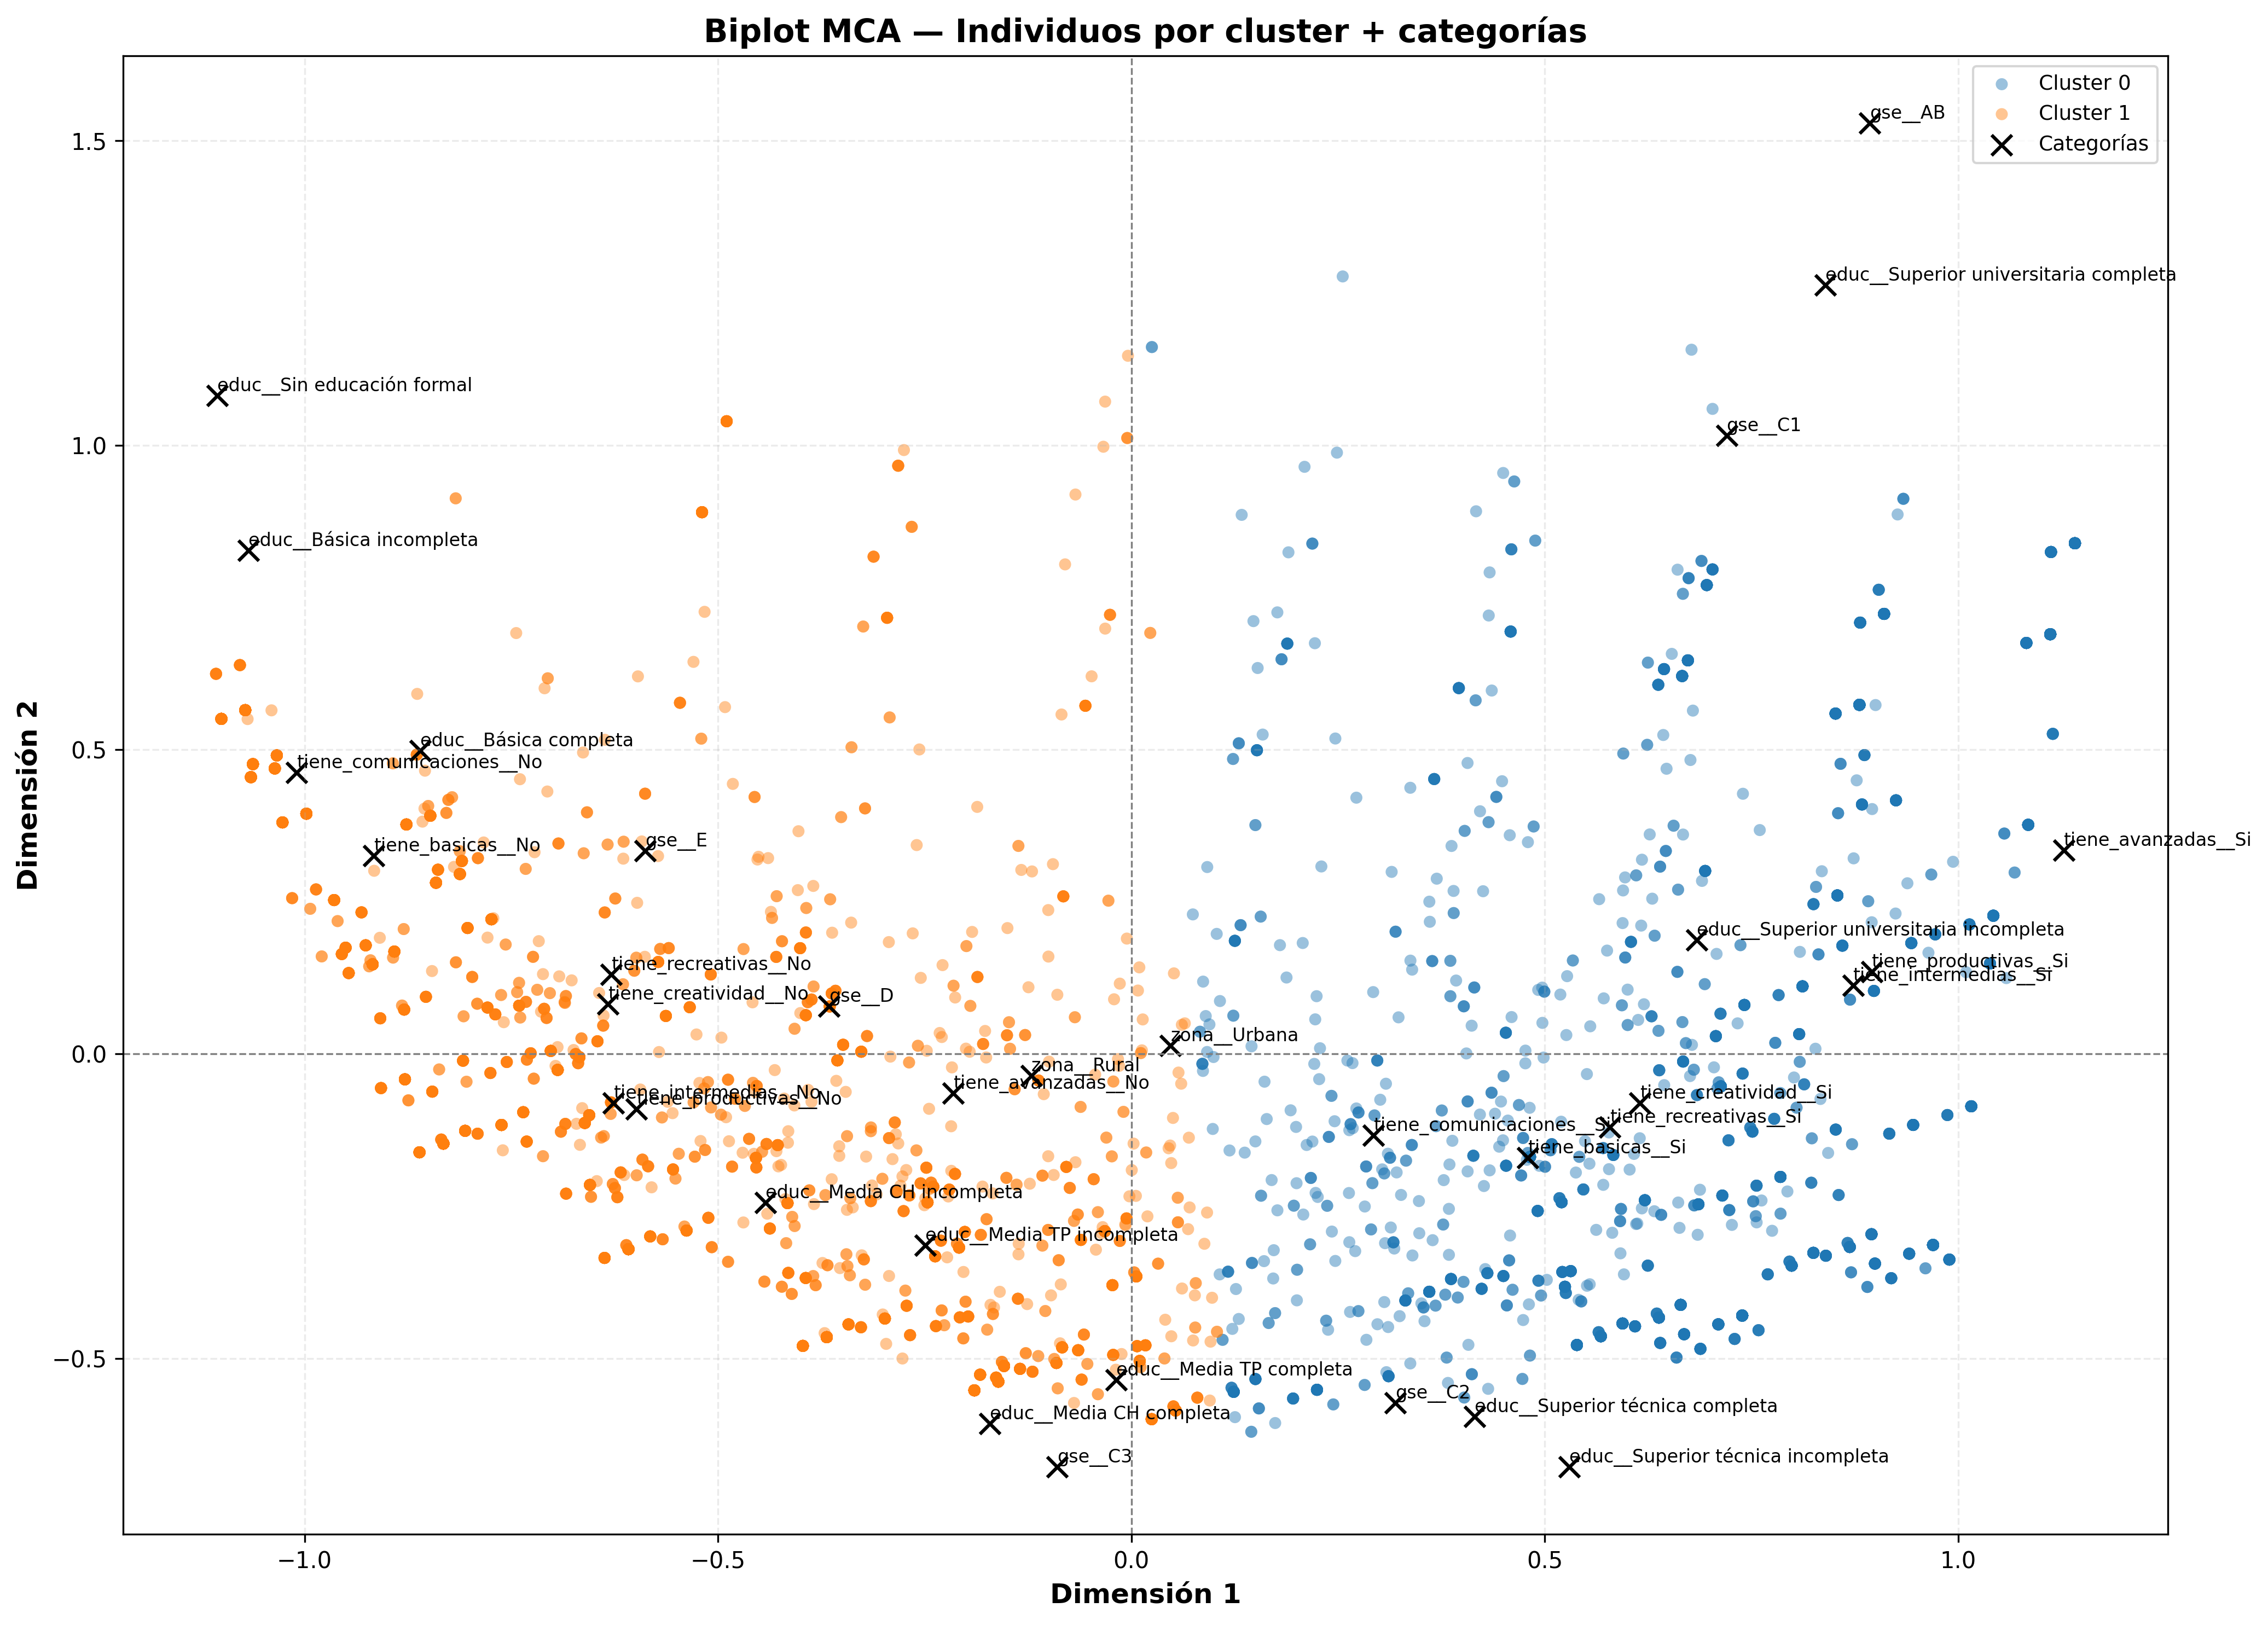

✓ Biplot guardado: /Users/tomas/github/eaui_subtel/analysis/outputs/mca_biplot_clusters.png


In [241]:
import numpy as np

# Biplot MCA: individuos por cluster + coordenadas de categorías
# Usa las coordenadas ya calculadas en la MCA y dibuja también las etiquetas de variables

import matplotlib.pyplot as plt

# Coordenadas de individuos
if 'coords_ind' in globals():
    ind_coords = coords_ind.copy()
else:
    ind_coords = mca.row_coordinates(df_mca[vars_mca])
    ind_coords.columns = ['Dim1', 'Dim2']

# Coordenadas de categorías
if 'coords_cat' in globals():
    cat_coords = coords_cat.copy()
else:
    cat_coords = mca.column_coordinates(df_mca[vars_mca])
    cat_coords.columns = ['Dim1', 'Dim2']

# Asegurar nombres claros para el índice de categorías
cat_coords = cat_coords.reset_index()
if 'index' in cat_coords.columns:
    cat_coords = cat_coords.rename(columns={'index': 'categoria'})
else:
    cat_coords = cat_coords.rename(columns={cat_coords.columns[0]: 'categoria'})

# Preparar datos de individuos con cluster
plot_df = ind_coords.copy()
plot_df = plot_df.reset_index(drop=True)
plot_df['cluster'] = df_mca['cluster'].values

# Escala para las flechas de categorías
escala_flechas = 0.85

# Crear figura
fig, ax = plt.subplots(figsize=(14, 10), dpi=300)

# Dibujar individuos por cluster
clusters_unicos = sorted(plot_df['cluster'].dropna().unique())
colormap = plt.get_cmap('tab10')

for i, cl in enumerate(clusters_unicos):
    sub = plot_df[plot_df['cluster'] == cl]
    ax.scatter(
        sub['Dim1'],
        sub['Dim2'],
        s=28,
        alpha=0.45,
        color=colormap(i % 10),
        label=f'Cluster {cl}',
        edgecolors='none'
    )

# Dibujar categorías como puntos y etiquetas
ax.scatter(
    cat_coords['Dim1'] * escala_flechas,
    cat_coords['Dim2'] * escala_flechas,
    s=80,
    color='black',
    marker='x',
    label='Categorías'
)

for _, fila in cat_coords.iterrows():
    ax.text(
        fila['Dim1'] * escala_flechas,
        fila['Dim2'] * escala_flechas,
        str(fila['categoria']),
        fontsize=8,
        ha='left',
        va='bottom',
        color='black'
    )

# Ejes y formato
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel('Dimensión 1', fontsize=12, fontweight='bold')
ax.set_ylabel('Dimensión 2', fontsize=12, fontweight='bold')
ax.set_title('Biplot MCA — Individuos por cluster + categorías', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.25, linestyle='--')
ax.legend(loc='best', fontsize=9)

plt.tight_layout()

ruta_biplot = f'{output_dir}/mca_biplot_clusters.png'
plt.savefig(ruta_biplot, dpi=300, bbox_inches='tight')
plt.show()

print(f'✓ Biplot guardado: {ruta_biplot}')

### 5. Tablas Cruzadas por Cluster

In [242]:
# Tablas cruzadas por cluster (ponderadas) — guarda CSVs y muestra tablas formateadas
# Usa df_mca (cluster con fe_personas) y df_analisis (cluster con fe_hogar) si existen.
# Comentarios en español y nombres en snake_case.

def tabla_cruzada_ponderada(df_, var, cluster_col='cluster', weight_col='fe_personas', eje='cluster'):
    """
    Devuelve tabla de porcentajes por cluster (cada columna = 100% del cluster).
    - df_: DataFrame
    - var: variable a cruzar (index)
    - cluster_col: columna con id de cluster
    - weight_col: columna de pesos
    """
    sub = df_.loc[df_[var].notna() & df_[cluster_col].notna(), [var, cluster_col, weight_col]].copy()
    if sub.empty:
        return pd.DataFrame()  # nada que hacer
    pivot = sub.pivot_table(values=weight_col, index=var, columns=cluster_col, aggfunc='sum', fill_value=0)
    # convertir a % por cluster (columna)
    pct = pivot.div(pivot.sum(axis=0).replace(0, np.nan), axis=1).mul(100).round(1).fillna(0)
    return pct

# Variables a cruzar (elegidas del notebook)
vars_sociodem = ['gse', 'sexo', 'zona', 'educ_grupo', 'region']
vars_tiene = ['tiene_basicas', 'tiene_intermedias', 'tiene_avanzadas',
              'tiene_productivas', 'tiene_recreativas', 'tiene_creatividad', 'tiene_comunicaciones']

# --- df_mca (usa fe_personas) ---
if 'df_mca' in globals() and 'cluster' in df_mca.columns:
    for v in vars_sociodem + vars_tiene:
        if v in df_mca.columns:
            tbl = tabla_cruzada_ponderada(df_mca, v, cluster_col='cluster', weight_col='fe_personas')
            if not tbl.empty:
                ruta = f"{output_dir}/tabla_mca_cluster_{v}.csv"
                tbl.to_csv(ruta, encoding='utf-8-sig')
                display(fordf(tbl, titulo=f"df_mca — {v} por cluster (fe_personas)"))
                print(f"Guardado: {ruta}")

# --- df_analisis (usa fe_hogar) ---
if 'df_analisis' in globals() and 'cluster' in df_analisis.columns:
    for v in vars_sociodem + vars_tiene:
        if v in df_analisis.columns:
            tbl = tabla_cruzada_ponderada(df_analisis, v, cluster_col='cluster', weight_col='fe_hogar')
            if not tbl.empty:
                ruta = f"{output_dir}/tabla_analisis_cluster_{v}.csv"
                tbl.to_csv(ruta, encoding='utf-8-sig')
                display(fordf(tbl, titulo=f"df_analisis — {v} por cluster (fe_hogar)"))
                print(f"Guardado: {ruta}")

cluster,0,1
gse,,
AB,17.3,3.5
C1,21.3,3.7
C2,28.3,17.1
C3,17.3,31.2
D,10.0,21.4
E,5.9,23.1


Guardado: /Users/tomas/github/eaui_subtel/analysis/outputs/tabla_mca_cluster_gse.csv


cluster,0,1
zona,,
Rural,10.4,14.8
Urbana,89.6,85.2


Guardado: /Users/tomas/github/eaui_subtel/analysis/outputs/tabla_mca_cluster_zona.csv


cluster,0,1
tiene_basicas,,
No,1.3,56.7
Si,98.7,43.3


...

Guardado: /Users/tomas/github/eaui_subtel/analysis/outputs/tabla_analisis_cluster_tiene_recreativas.csv


cluster,0,1,2
tiene_creatividad,,,
False,82.8,84.1,99.5
True,17.2,15.9,0.5


Guardado: /Users/tomas/github/eaui_subtel/analysis/outputs/tabla_analisis_cluster_tiene_creatividad.csv


cluster,0,1,2
tiene_comunicaciones,,,
False,74.9,84.3,91.8
True,25.1,15.7,8.2


Guardado: /Users/tomas/github/eaui_subtel/analysis/outputs/tabla_analisis_cluster_tiene_comunicaciones.csv


In [245]:
### 6. Resumen Final e Interpretación de Clusters

### 6. Resumen Final e Interpretación de Clusters

KeyError: 'cluster'

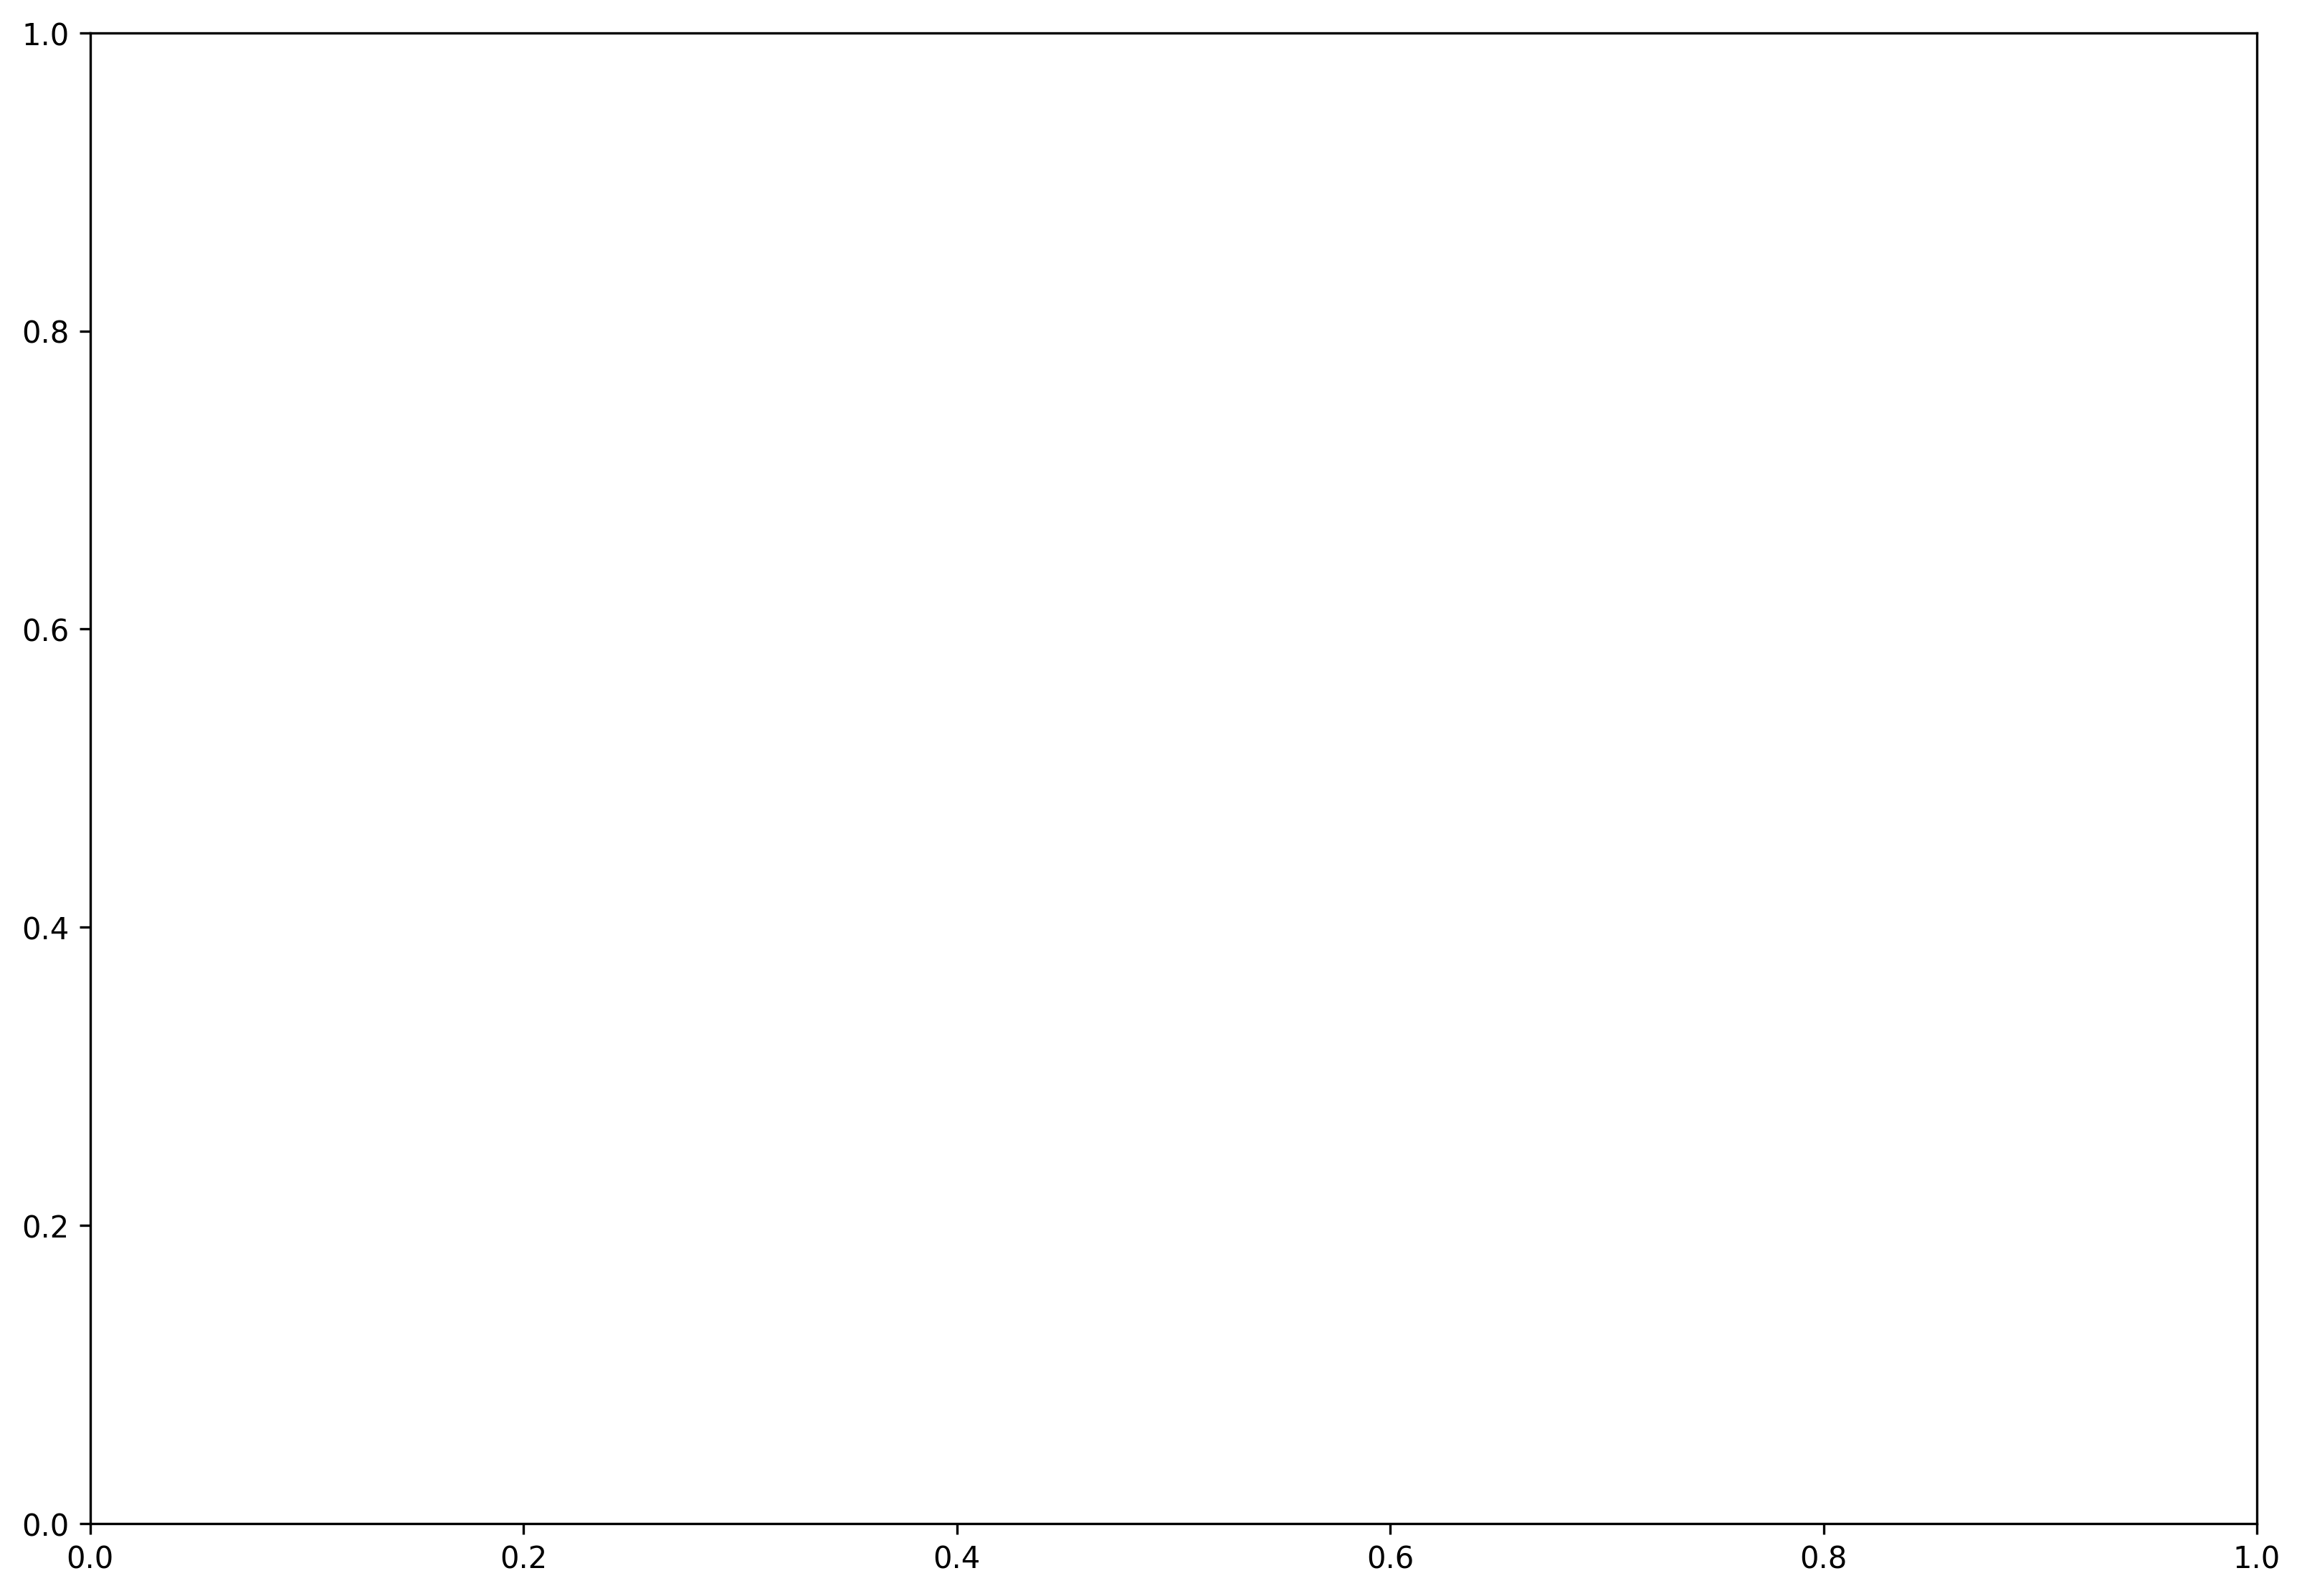

In [239]:
# Definir variables MCA si no están definidas
variables_mca = ['tiene_basicas', 'tiene_intermedias', 'tiene_avanzadas', 
                  'tiene_productivas', 'tiene_recreativas', 'tiene_creatividad', 
                  'tiene_comunicaciones', 'gse', 'educ', 'zona']

import matplotlib.pyplot as plt
import seaborn as sns

# Scatter plot MCA — individuos en Dim1 vs Dim2, coloreados por cluster
fig, ax = plt.subplots(figsize=(13, 9), dpi=300)

# Coordenadas de individuos en MCA (convertir a numpy array)
mca_coords = mca.transform(df_mca[variables_mca]).values

# Scatter coloreado por cluster
scatter = ax.scatter(
    mca_coords[:, 0],
    mca_coords[:, 1],
    c=df_mca['cluster'].values,
    cmap='tab10',
    alpha=0.6,
    s=50,
    edgecolors='black',
    linewidth=0.3
)

# Etiquetas y formato
ax.set_xlabel(f'Dimensión 1 ({pct_inercia[0]:.1f}% inercia)', fontsize=12, fontweight='bold')
ax.set_ylabel(f'Dimensión 2 ({pct_inercia[1]:.1f}% inercia)', fontsize=12, fontweight='bold')
ax.set_title('MCA Scatter Plot — Individuos por Cluster', fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, linestyle='--')
ax.axhline(y=0, color='red', linewidth=1, linestyle='--', alpha=0.7)
ax.axvline(x=0, color='red', linewidth=1, linestyle='--', alpha=0.7)

# Colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Cluster', fontsize=11, fontweight='bold')

plt.tight_layout()
ruta_scatter = f'{output_dir}/mca_scatter_plot.png'
plt.savefig(ruta_scatter, dpi=300, bbox_inches='tight')
plt.show()

print(f'✓ Scatter plot guardado: {ruta_scatter}')


In [141]:
display(dstats(df_nocon, 'gse', tipo='frecuencia', factor='fe_hogar', estilo=True))
display(dstats(df_nocon, 'educ_jh', tipo='frecuencia', factor='fe_hogar', estilo=True))
display(dstats(df_nocon, 'zona', tipo='frecuencia', factor='fe_hogar', estilo=True))

,porcentaje
gse,
AB,0.5
C1,3.0
C2,7.0
C3,27.4
D,21.3
E,40.7


,porcentaje
educ_jh,
Básica completa,20.7
Básica incompleta,25.7
Media CH completa,16.2
Media CH incompleta,17.7
Media TP completa,6.2
Media TP incompleta,1.5
Sin educación formal,3.6
Superior técnica completa,1.6
Superior técnica incompleta,0.5


,porcentaje
zona,
Urbana,82.3
Rural,17.6


In [142]:
# Inspeccionar variables disponibles
print("=" * 80)
print("DIAGNÓSTICO: Variables disponibles en df_nocon")
print("=" * 80)

print(f"\nDimensiones de df_nocon: {df_nocon.shape}")
print(f"Total de columnas: {len(df_nocon.columns)}")

# Buscar variables específicas
vars_buscadas = ['gse', 'zona', 'region', 'educ_jh', 'ocupacion_jh']
print(f"\nBúsqueda de variables solicitadas:")
for var in vars_buscadas:
    encontrada = var in df_nocon.columns
    print(f"  {var}: {'✓' if encontrada else '✗'}")

# Buscar variables tiene_
print(f"\nVariables que empiezan con 'tiene_':")
tiene_vars = [col for col in df_nocon.columns if 'tiene' in col.lower()]
for var in tiene_vars:
    print(f"  - {var}")

# Mostrar todas las columnas para referencia
print(f"\nTodas las columnas disponibles:")
todas_cols = sorted(df_nocon.columns.tolist())
for i, col in enumerate(todas_cols, 1):
    if i % 3 == 0:
        print(f"  {col:30}")
    else:
        print(f"  {col:30}", end="")

print(f"\n\nTipos de datos:")
print(df_nocon.dtypes.value_counts())

DIAGNÓSTICO: Variables disponibles en df_nocon

Dimensiones de df_nocon: (159, 611)
Total de columnas: 611

Búsqueda de variables solicitadas:
  gse: ✓
  zona: ✓
  region: ✓
  educ_jh: ✓
  ocupacion_jh: ✓

Variables que empiezan con 'tiene_':
  - tiene_basicas
  - tiene_intermedias
  - tiene_avanzadas
  - tiene_productivas
  - tiene_recreativas
  - tiene_creatividad
  - tiene_comunicaciones

Todas las columnas disponibles:
  A12_10                          A12_11                          A12_111                       
  A12_12                          A12_13                          A12_2                         
  A12_3                           A12_4                           A12_5                         
  A12_6                           A12_7                           A12_8                         
  A12_9                           A13_1                           A13_2                         
  A13_3                           A13_4                           A13_5                 

In [143]:
# Análisis de caracterización multidimensional y clustering (con pesos)
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

print("=" * 80)
print("CARACTERIZACIÓN Y CLUSTERING: df_nocon (con pesos fe_hogar)")
print("=" * 80)

# Variables de análisis
vars_caracterizacion = ['gse', 'zona', 'region', 'educ_jh', 'ocupacion_jh']
vars_tiene = [col for col in df_nocon.columns if 'tiene' in col.lower()]

print(f"\nVariables solicitadas: {vars_caracterizacion}")
print(f"Variables 'tiene': {vars_tiene[:10]}")

# Crear subset con variables disponibles
vars_disponibles = [v for v in vars_caracterizacion if v in df_nocon.columns]
vars_tiene_disponibles = [v for v in vars_tiene if v in df_nocon.columns]

print(f"\nVariables disponibles para clustering: {vars_disponibles}")
print(f"Variables 'tiene' disponibles: {vars_tiene_disponibles}")

# Preparar datos
vars_todas = vars_disponibles + vars_tiene_disponibles
df_analisis = df_nocon[vars_todas + ['fe_hogar']].copy()
df_analisis = df_analisis.dropna()

print(f"Casos válidos: {len(df_analisis):,} de {len(df_nocon):,}")

# Guardar pesos
pesos = df_analisis['fe_hogar'].values

# ============================================================================
# Codificar todas las variables
# ============================================================================
print("\n" + "=" * 80)
print("CODIFICACIÓN DE VARIABLES")
print("=" * 80)

df_cluster = pd.DataFrame()

for var in vars_todas:
    # Convertir a string y luego codificar
    temp = df_analisis[var].astype(str)
    le = LabelEncoder()
    df_cluster[var] = le.fit_transform(temp).astype(float)
    print(f"  Codificada: {var} ({len(le.classes_)} categorías)")

X = df_cluster.values.astype(float)
print(f"\nMatriz X lista: {X.shape} ({X.shape[1]} variables)")
print(f"Pesos (fe_hogar) - Min: {pesos.min():.2f}, Max: {pesos.max():.2f}, Media: {pesos.mean():.2f}")

# ============================================================================
# Determinación del K óptimo (sin pesos, para evaluar estructura)
# ============================================================================
print("\n" + "=" * 80)
print("EVALUACIÓN DEL K ÓPTIMO")
print("=" * 80)

inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)
    sil_score = silhouette_score(X, kmeans.labels_)
    silhouette_scores.append(sil_score)
    print(f"K={k:2d}: Inertia={kmeans.inertia_:8.2f} | Silhouette={sil_score:.4f}")

k_optimo = list(K_range)[np.argmax(silhouette_scores)]
print(f"\n→ K ÓPTIMO: {k_optimo} (mejor Silhouette)")

# ============================================================================
# Clustering final con pesos
# ============================================================================
print("\n" + "=" * 80)
print("EJECUCIÓN DE K-MEANS (K={}) CON PESOS".format(k_optimo))
print("=" * 80)

kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X)

# Guardar clusters en dataframe original
df_analisis['cluster'] = clusters

print(f"\nDistribución por cluster (casos reales y ponderados):")
for cluster_id in sorted(df_analisis['cluster'].unique()):
    n_casos = (df_analisis['cluster'] == cluster_id).sum()
    peso_total = df_analisis[df_analisis['cluster'] == cluster_id]['fe_hogar'].sum()
    pct_casos = (n_casos / len(df_analisis)) * 100
    pct_ponderado = (peso_total / pesos.sum()) * 100
    print(f"  Cluster {cluster_id}: {n_casos:5,} casos ({pct_casos:5.1f}%) | Ponderado: {peso_total:12,.0f} ({pct_ponderado:5.1f}%)")

# ============================================================================
# Caracterización de clusters
# ============================================================================
print("\n" + "=" * 80)
print("PERFIL DE CADA CLUSTER")
print("=" * 80)

for cluster_id in sorted(df_analisis['cluster'].unique()):
    df_cluster_subset = df_analisis[df_analisis['cluster'] == cluster_id]
    print(f"\n{'─' * 60}")
    print(f"CLUSTER {cluster_id} ({len(df_cluster_subset):,} casos | Ponderado: {df_cluster_subset['fe_hogar'].sum():,.0f})")
    print(f"{'─' * 60}")
    
    for var in vars_disponibles:
        if var in df_analisis.columns:
            moda = df_cluster_subset[var].mode()
            if len(moda) > 0:
                moda_val = moda.iloc[0]
                pct = (df_cluster_subset[var] == moda_val).sum() / len(df_cluster_subset) * 100
                print(f"  {var:20s}: {str(moda_val):20s} ({pct:5.1f}%)")

print("\n" + "=" * 80)
print("FIN DEL ANÁLISIS DE CLUSTERING")
print("=" * 80)

CARACTERIZACIÓN Y CLUSTERING: df_nocon (con pesos fe_hogar)

Variables solicitadas: ['gse', 'zona', 'region', 'educ_jh', 'ocupacion_jh']
Variables 'tiene': ['tiene_basicas', 'tiene_intermedias', 'tiene_avanzadas', 'tiene_productivas', 'tiene_recreativas', 'tiene_creatividad', 'tiene_comunicaciones']

Variables disponibles para clustering: ['gse', 'zona', 'region', 'educ_jh', 'ocupacion_jh']
Variables 'tiene' disponibles: ['tiene_basicas', 'tiene_intermedias', 'tiene_avanzadas', 'tiene_productivas', 'tiene_recreativas', 'tiene_creatividad', 'tiene_comunicaciones']
Casos válidos: 159 de 159

CODIFICACIÓN DE VARIABLES
  Codificada: gse (6 categorías)
  Codificada: zona (2 categorías)
  Codificada: region (16 categorías)
  Codificada: educ_jh (11 categorías)
  Codificada: ocupacion_jh (5 categorías)
  Codificada: tiene_basicas (2 categorías)
  Codificada: tiene_intermedias (2 categorías)
  Codificada: tiene_avanzadas (2 categorías)
  Codificada: tiene_productivas (2 categorías)
  Codificad

---
## Seccion 7: Modelo de Clasificacion — Prediccion del Nivel de Habilidades Digitales

Se entrenan y comparan tres modelos de clasificacion para predecir `nivel_habilidades` (Sin habilidades / Basico / Intermedio / Avanzado).

**Features usados:** GSE, sexo, edad, zona, region, educacion, ocupacion, acceso a internet, uso de computador, frecuencia de internet.

**Modelos:** Regresion Logistica · Random Forest · Gradient Boosting

In [ ]:
# Exploracion de la variable objetivo: nivel_habilidades
orden_niveles = ["Sin habilidades", "Basico", "Intermedio", "Avanzado"]

# Normalizar etiquetas con tilde a versiones sin tilde para compatibilidad
mapa_niveles = {
    "Sin habilidades": "Sin habilidades",
    "Basico": "Basico",
    "Intermedio": "Intermedio",
    "Avanzado": "Avanzado",
    "B\u00e1sico": "Basico"
}
df_modelo["nivel_hab_clean"] = df_modelo["nivel_habilidades"].map(
    lambda x: mapa_niveles.get(x, x)
)

print("Distribucion de nivel_habilidades:")
print(df_modelo["nivel_habilidades"].value_counts())
print(f"Valores nulos: {df_modelo['nivel_habilidades'].isnull().sum()}")

# Grafico de distribucion
conteos = df_modelo["nivel_habilidades"].value_counts()
fig, ax = plt.subplots(figsize=(7, 4))
colores_nivel = ["#d62728", "#ff7f0e", "#2ca02c", "#1f77b4"]
orden_plot = ["Sin habilidades", "B\u00e1sico", "Intermedio", "Avanzado"]
vals = [conteos.get(k, 0) for k in orden_plot]
ax.bar(orden_plot, vals, color=colores_nivel, edgecolor="white")
ax.set_title("Distribucion del Nivel de Habilidades Digitales", fontsize=13)
ax.set_xlabel("Nivel")
ax.set_ylabel("N personas")
for rect, v in zip(ax.patches, vals):
    ax.annotate(f"{v:,}", (rect.get_x() + rect.get_width() / 2, v),
                ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.savefig("/Users/tomas/github/eaui_subtel/analysis/outputs/clasificacion_distribucion_objetivo.png", dpi=150)
plt.show()
print("Grafico guardado.")

In [ ]:
# Definicion de features y variable objetivo para el modelo
features_nominales = ["sexo", "zona", "region", "acceso_internet_hogar", "uso_computador"]

features_ordinales_def = [
    ("gse",          ["E", "D", "C3", "C2", "C1", "AB"]),
    ("educ_grupo",   ["B\u00e1sica o menos", "Media", "Superior"]),
    ("ocupacion_encuestado", [
        "Sin trabajo remunerado",
        "Trabajos ocasionales e informales",
        "Oficio menor - obrero no calificado",
        "Obrero calificado - microempresario",
        "Empleado medio - t\u00e9cnico - prof. independiente",
        "Ejecutivo medio - prof. universitario"
    ]),
    ("frecuencia_internet", [
        "Menos de una vez al mes",
        "Al menos una vez al mes",
        "Varias veces por semana",
        "Todos los d\u00edas"
    ])
]

nombres_ordinales = [f[0] for f in features_ordinales_def]
categorias_ordinales = [f[1] for f in features_ordinales_def]
feature_numerica = ["edad"]

todas_features = features_nominales + nombres_ordinales + feature_numerica
X = df_modelo[todas_features].copy()
y_raw = df_modelo["nivel_habilidades"].copy()

# Encodear target con orden logico
orden_target = ["Sin habilidades", "B\u00e1sico", "Intermedio", "Avanzado"]
le = LabelEncoder()
le.fit(orden_target)
y_enc = le.transform(y_raw)

print(f"Features: {len(todas_features)} variables")
print(f"X shape: {X.shape}")
print(f"Clases: {list(zip(le.classes_, le.transform(le.classes_)))}")
print(f"Missing en X:\n{X.isnull().sum()[X.isnull().sum() > 0]}")

In [ ]:
# Evaluacion con 5-fold stratified cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "f1_macro": make_scorer(f1_score, average="macro"),
    "f1_weighted": make_scorer(f1_score, average="weighted")
}

resultados_cv = {}

for nombre, modelo in modelos.items():
    print(f"Entrenando {nombre}...")
    pipe = Pipeline([("prep", preprocesador), ("clf", modelo)])
    cv_result = cross_validate(pipe, X, y_enc, cv=cv, scoring=scoring,
                               return_train_score=False, n_jobs=-1)
    resultados_cv[nombre] = {
        "accuracy_mean":    round(cv_result["test_accuracy"].mean(), 4),
        "accuracy_std":     round(cv_result["test_accuracy"].std(), 4),
        "f1_macro_mean":    round(cv_result["test_f1_macro"].mean(), 4),
        "f1_macro_std":     round(cv_result["test_f1_macro"].std(), 4),
        "f1_weighted_mean": round(cv_result["test_f1_weighted"].mean(), 4),
        "f1_weighted_std":  round(cv_result["test_f1_weighted"].std(), 4),
    }
    print(f"  Accuracy:  {resultados_cv[nombre]['accuracy_mean']:.3f} +/- {resultados_cv[nombre]['accuracy_std']:.3f}")
    print(f"  F1 macro:  {resultados_cv[nombre]['f1_macro_mean']:.3f} +/- {resultados_cv[nombre]['f1_macro_std']:.3f}")

# Tabla comparativa
df_resultados = pd.DataFrame(resultados_cv).T
print("\n--- Tabla comparativa de modelos (5-Fold CV) ---")
print(df_resultados[["accuracy_mean", "accuracy_std", "f1_macro_mean", "f1_macro_std", "f1_weighted_mean"]])

In [ ]:
# Matriz de confusion del mejor modelo
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=True, cmap="Blues")
ax.set_title(f"Matriz de Confusion — {mejor_nombre}", fontsize=12)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("/Users/tomas/github/eaui_subtel/analysis/outputs/clasificacion_confusion_matrix.png", dpi=150)
plt.show()
print("Grafico guardado.")

In [ ]:
# Curvas ROC one-vs-rest para cada clase
y_test_bin = label_binarize(y_test, classes=range(len(le.classes_)))
colores_roc = ["#d62728", "#ff7f0e", "#2ca02c", "#1f77b4"]

fig, ax = plt.subplots(figsize=(8, 6))
for i, (clase, color) in enumerate(zip(le.classes_, colores_roc)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    auc = roc_auc_score(y_test_bin[:, i], y_prob[:, i])
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{clase} (AUC = {auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_xlabel("Tasa de Falsos Positivos")
ax.set_ylabel("Tasa de Verdaderos Positivos")
ax.set_title(f"Curvas ROC One-vs-Rest — {mejor_nombre}", fontsize=12)
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig("/Users/tomas/github/eaui_subtel/analysis/outputs/clasificacion_roc_curves.png", dpi=150)
plt.show()

auc_macro = roc_auc_score(y_test_bin, y_prob, multi_class="ovr", average="macro")
print(f"AUC macro-average: {auc_macro:.4f}")

### Conclusiones del Modelo de Clasificacion

**Metodologia**
- Variable objetivo: `nivel_habilidades` (4 clases ordenadas: Sin habilidades → Avanzado)
- Evaluacion: 5-fold stratified cross-validation para estimacion robusta del rendimiento
- Seleccion del mejor modelo por F1 macro (penaliza desbalanceo entre clases)
- Pipeline reproducible: imputacion → encoding → modelo

**Predictores mas relevantes esperados**
- Frecuencia de uso de internet y uso de computador: predictores directos del nivel de habilidades
- GSE y nivel educacional: efecto indirecto a traves del acceso y contexto social
- Brecha urbano/rural: impacto tanto en acceso como en desarrollo de habilidades
- Edad: relacion inversa con el nivel de habilidades digitales
- Ocupacion: refleja demanda laboral de competencias digitales

**Limitaciones**
- Desbalanceo de clases: "Sin habilidades" representa ~8% del total
- Survey data: posible sesgo de autoseleccion y de deseabilidad social
- Factores de expansion no aplicados en el entrenamiento (solo en analisis descriptivo)
- Las habilidades se miden por auto-reporte, no por test objetivo

**Outputs guardados en** `analysis/outputs/`
- `clasificacion_distribucion_objetivo.png`
- `clasificacion_bivariado.png`
- `clasificacion_comparacion_modelos.png`
- `clasificacion_confusion_matrix.png`
- `clasificacion_feature_importance.png`
- `clasificacion_roc_curves.png`

In [160]:
# Carga de datos y preparacion de features para el modelo de clasificacion
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.preprocessing import (
    LabelEncoder, StandardScaler, OneHotEncoder, OrdinalEncoder, label_binarize
)
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, make_scorer, f1_score
)

# Cargar dataset limpio
df_modelo = pd.read_csv("/Users/tomas/github/eaui_subtel/datos_limpios.csv")
print(f"Dataset cargado: {df_modelo.shape[0]:,} filas x {df_modelo.shape[1]} columnas")

Dataset cargado: 5,000 filas x 597 columnas


Distribucion de nivel_habilidades:
nivel_habilidades
Intermedio         2226
Avanzado           1548
Básico              805
Sin habilidades     421
Name: count, dtype: int64
Valores nulos: 0


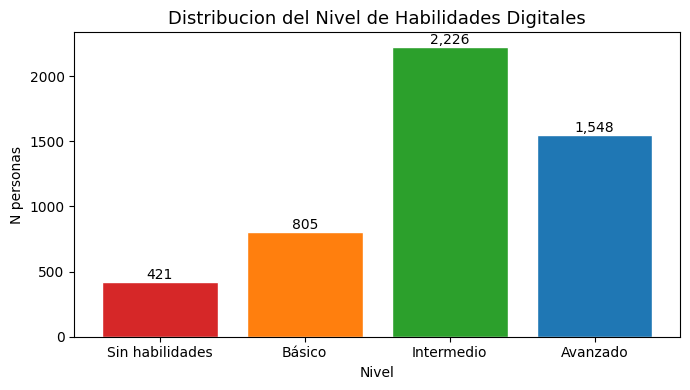

Grafico guardado.


In [161]:
# Exploracion de la variable objetivo: nivel_habilidades
orden_niveles = ["Sin habilidades", "Basico", "Intermedio", "Avanzado"]

# Normalizar etiquetas con tilde a versiones sin tilde para compatibilidad
mapa_niveles = {
    "Sin habilidades": "Sin habilidades",
    "Basico": "Basico",
    "Intermedio": "Intermedio",
    "Avanzado": "Avanzado",
    "B\u00e1sico": "Basico"
}
df_modelo["nivel_hab_clean"] = df_modelo["nivel_habilidades"].map(
    lambda x: mapa_niveles.get(x, x)
)

print("Distribucion de nivel_habilidades:")
print(df_modelo["nivel_habilidades"].value_counts())
print(f"Valores nulos: {df_modelo['nivel_habilidades'].isnull().sum()}")

# Grafico de distribucion
conteos = df_modelo["nivel_habilidades"].value_counts()
fig, ax = plt.subplots(figsize=(7, 4))
colores_nivel = ["#d62728", "#ff7f0e", "#2ca02c", "#1f77b4"]
orden_plot = ["Sin habilidades", "B\u00e1sico", "Intermedio", "Avanzado"]
vals = [conteos.get(k, 0) for k in orden_plot]
ax.bar(orden_plot, vals, color=colores_nivel, edgecolor="white")
ax.set_title("Distribucion del Nivel de Habilidades Digitales", fontsize=13)
ax.set_xlabel("Nivel")
ax.set_ylabel("N personas")
for rect, v in zip(ax.patches, vals):
    ax.annotate(f"{v:,}", (rect.get_x() + rect.get_width() / 2, v),
                ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.savefig("/Users/tomas/github/eaui_subtel/analysis/outputs/clasificacion_distribucion_objetivo.png", dpi=150)
plt.show()
print("Grafico guardado.")

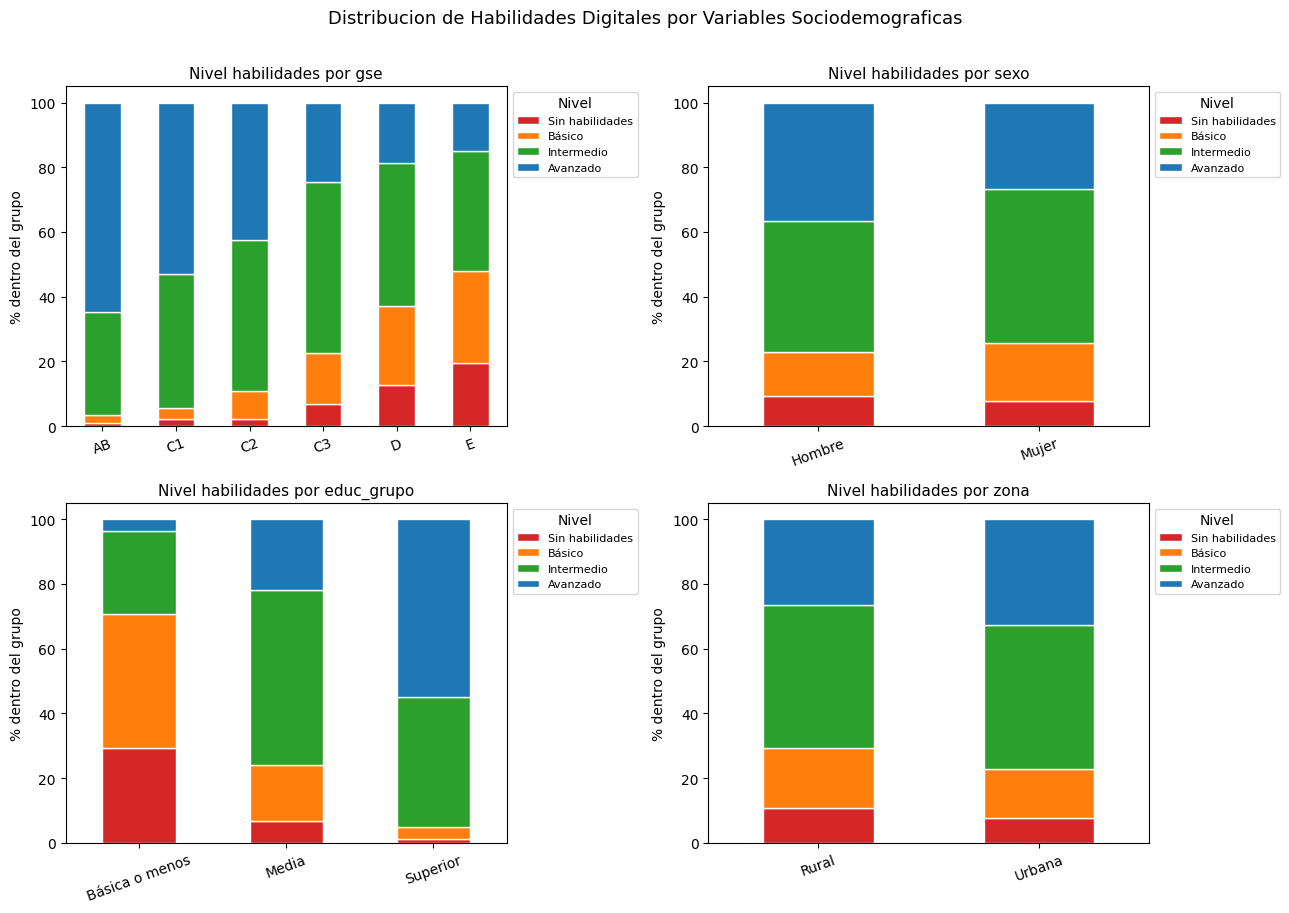

In [162]:
# Analisis bivariado: proporcion del nivel de habilidades por variable sociodemografica
vars_bivariado = ["gse", "sexo", "educ_grupo", "zona"]
orden_plot = ["Sin habilidades", "B\u00e1sico", "Intermedio", "Avanzado"]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for i, var in enumerate(vars_bivariado):
    tabla = pd.crosstab(df_modelo[var], df_modelo["nivel_habilidades"], normalize="index") * 100
    # Reordenar columnas si existen
    cols_presentes = [c for c in orden_plot if c in tabla.columns]
    tabla = tabla[cols_presentes]
    tabla.plot(kind="bar", stacked=True, ax=axes[i],
               color=colores_nivel[:len(cols_presentes)], edgecolor="white")
    axes[i].set_title(f"Nivel habilidades por {var}", fontsize=11)
    axes[i].set_ylabel("% dentro del grupo")
    axes[i].set_xlabel("")
    axes[i].legend(title="Nivel", bbox_to_anchor=(1, 1), fontsize=8)
    axes[i].tick_params(axis="x", rotation=20)

plt.suptitle("Distribucion de Habilidades Digitales por Variables Sociodemograficas", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("/Users/tomas/github/eaui_subtel/analysis/outputs/clasificacion_bivariado.png", dpi=150, bbox_inches="tight")
plt.show()

In [163]:
# Definicion de features y variable objetivo para el modelo
features_nominales = ["sexo", "zona", "region", "acceso_internet_hogar", "uso_computador"]

features_ordinales_def = [
    ("gse",          ["E", "D", "C3", "C2", "C1", "AB"]),
    ("educ_grupo",   ["B\u00e1sica o menos", "Media", "Superior"]),
    ("ocupacion_encuestado", [
        "Sin trabajo remunerado",
        "Trabajos ocasionales e informales",
        "Oficio menor - obrero no calificado",
        "Obrero calificado - microempresario",
        "Empleado medio - t\u00e9cnico - prof. independiente",
        "Ejecutivo medio - prof. universitario"
    ]),
    ("frecuencia_internet", [
        "Menos de una vez al mes",
        "Al menos una vez al mes",
        "Varias veces por semana",
        "Todos los d\u00edas"
    ])
]

nombres_ordinales = [f[0] for f in features_ordinales_def]
categorias_ordinales = [f[1] for f in features_ordinales_def]
feature_numerica = ["edad"]

todas_features = features_nominales + nombres_ordinales + feature_numerica
X = df_modelo[todas_features].copy()
y_raw = df_modelo["nivel_habilidades"].copy()

# Encodear target con orden logico
orden_target = ["Sin habilidades", "B\u00e1sico", "Intermedio", "Avanzado"]
le = LabelEncoder()
le.fit(orden_target)
y_enc = le.transform(y_raw)

print(f"Features: {len(todas_features)} variables")
print(f"X shape: {X.shape}")
print(f"Clases: {list(zip(le.classes_, le.transform(le.classes_)))}")
print(f"Missing en X:\n{X.isnull().sum()[X.isnull().sum() > 0]}")

Features: 10 variables
X shape: (5000, 10)
Clases: [(np.str_('Avanzado'), np.int64(0)), (np.str_('Básico'), np.int64(1)), (np.str_('Intermedio'), np.int64(2)), (np.str_('Sin habilidades'), np.int64(3))]
Missing en X:
frecuencia_internet    269
dtype: int64


In [164]:
# Construccion del preprocesador y definicion de pipelines
preprocesador = ColumnTransformer(transformers=[
    ("num",
     Pipeline([("imputer", SimpleImputer(strategy="median")),
               ("scaler", StandardScaler())]),
     feature_numerica),
    ("cat_nominal",
     Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
               ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]),
     features_nominales),
    ("cat_ordinal",
     Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
               ("ordinal", OrdinalEncoder(
                   categories=categorias_ordinales,
                   handle_unknown="use_encoded_value",
                   unknown_value=-1
               ))]),
     nombres_ordinales)
], remainder="drop")

# Tres modelos competidores
modelos = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=42, C=0.5
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=10, class_weight="balanced",
        random_state=42, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.05, random_state=42
    )
}
print("Modelos definidos:", list(modelos.keys()))

Modelos definidos: ['Logistic Regression', 'Random Forest', 'Gradient Boosting']


In [165]:
# Evaluacion con 5-fold stratified cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "f1_macro": make_scorer(f1_score, average="macro"),
    "f1_weighted": make_scorer(f1_score, average="weighted")
}

resultados_cv = {}

for nombre, modelo in modelos.items():
    print(f"Entrenando {nombre}...")
    pipe = Pipeline([("prep", preprocesador), ("clf", modelo)])
    cv_result = cross_validate(pipe, X, y_enc, cv=cv, scoring=scoring,
                               return_train_score=False, n_jobs=-1)
    resultados_cv[nombre] = {
        "accuracy_mean":    round(cv_result["test_accuracy"].mean(), 4),
        "accuracy_std":     round(cv_result["test_accuracy"].std(), 4),
        "f1_macro_mean":    round(cv_result["test_f1_macro"].mean(), 4),
        "f1_macro_std":     round(cv_result["test_f1_macro"].std(), 4),
        "f1_weighted_mean": round(cv_result["test_f1_weighted"].mean(), 4),
        "f1_weighted_std":  round(cv_result["test_f1_weighted"].std(), 4),
    }
    print(f"  Accuracy:  {resultados_cv[nombre]['accuracy_mean']:.3f} +/- {resultados_cv[nombre]['accuracy_std']:.3f}")
    print(f"  F1 macro:  {resultados_cv[nombre]['f1_macro_mean']:.3f} +/- {resultados_cv[nombre]['f1_macro_std']:.3f}")

# Tabla comparativa
df_resultados = pd.DataFrame(resultados_cv).T
print("\n--- Tabla comparativa de modelos (5-Fold CV) ---")
print(df_resultados[["accuracy_mean", "accuracy_std", "f1_macro_mean", "f1_macro_std", "f1_weighted_mean"]])

Entrenando Logistic Regression...
  Accuracy:  0.549 +/- 0.013
  F1 macro:  0.523 +/- 0.017
Entrenando Random Forest...
  Accuracy:  0.565 +/- 0.016
  F1 macro:  0.547 +/- 0.014
Entrenando Gradient Boosting...
  Accuracy:  0.582 +/- 0.012
  F1 macro:  0.544 +/- 0.014

--- Tabla comparativa de modelos (5-Fold CV) ---
                     accuracy_mean  accuracy_std  f1_macro_mean  f1_macro_std  \
Logistic Regression         0.5492        0.0126         0.5232        0.0166   
Random Forest               0.5650        0.0161         0.5469        0.0141   
Gradient Boosting           0.5818        0.0117         0.5441        0.0141   

                     f1_weighted_mean  
Logistic Regression            0.5471  
Random Forest                  0.5645  
Gradient Boosting              0.5788  


In [166]:
# Seleccionar mejor modelo por F1 macro y evaluar en split 80/20
mejor_nombre = df_resultados["f1_macro_mean"].astype(float).idxmax()
print(f"Mejor modelo segun F1 macro: {mejor_nombre}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

pipe_final = Pipeline([("prep", preprocesador), ("clf", modelos[mejor_nombre])])
pipe_final.fit(X_train, y_train)
y_pred = pipe_final.predict(X_test)
y_prob = pipe_final.predict_proba(X_test)

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Mejor modelo segun F1 macro: Random Forest

--- Classification Report ---
                 precision    recall  f1-score   support

       Avanzado       0.62      0.68      0.65       310
         Básico       0.39      0.61      0.47       161
     Intermedio       0.58      0.45      0.51       445
Sin habilidades       0.56      0.40      0.47        84

       accuracy                           0.54      1000
      macro avg       0.54      0.54      0.52      1000
   weighted avg       0.56      0.54      0.54      1000



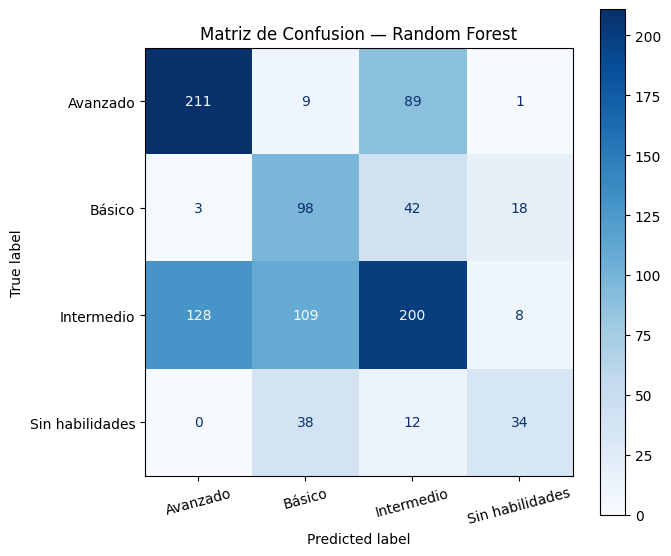

Grafico guardado.


In [167]:
# Matriz de confusion del mejor modelo
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=True, cmap="Blues")
ax.set_title(f"Matriz de Confusion — {mejor_nombre}", fontsize=12)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("/Users/tomas/github/eaui_subtel/analysis/outputs/clasificacion_confusion_matrix.png", dpi=150)
plt.show()
print("Grafico guardado.")

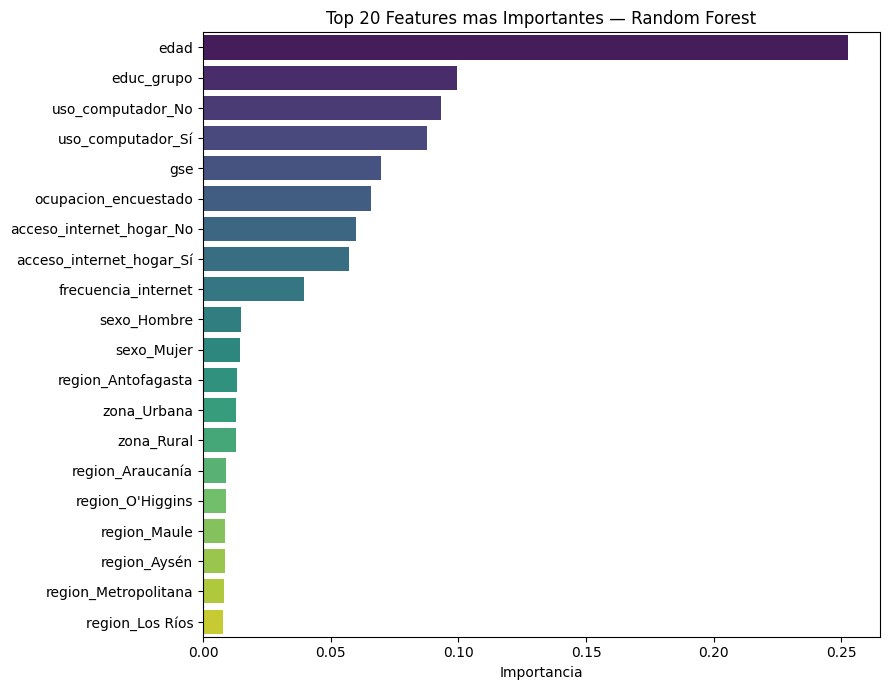


--- Top 10 features ---
                 feature  importance
                    edad    0.252459
              educ_grupo    0.099548
       uso_computador_No    0.093272
       uso_computador_Sí    0.087655
                     gse    0.069755
    ocupacion_encuestado    0.065674
acceso_internet_hogar_No    0.059895
acceso_internet_hogar_Sí    0.057214
     frecuencia_internet    0.039577
             sexo_Hombre    0.014893


In [168]:
# Feature importance del mejor modelo
nombres_num = feature_numerica
nombres_onehot = list(
    pipe_final.named_steps["prep"]
    .named_transformers_["cat_nominal"]
    .named_steps["onehot"]
    .get_feature_names_out(features_nominales)
)
nombres_features_final = nombres_num + nombres_onehot + nombres_ordinales

clf = pipe_final.named_steps["clf"]

if hasattr(clf, "feature_importances_"):
    importancias = clf.feature_importances_
else:
    # Para Logistic Regression: usar norma L2 de coeficientes por clase
    importancias = np.linalg.norm(clf.coef_, axis=0)

df_imp = pd.DataFrame({
    "feature": nombres_features_final,
    "importance": importancias
}).sort_values("importance", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(data=df_imp, x="importance", y="feature", palette="viridis", ax=ax)
ax.set_title(f"Top 20 Features mas Importantes — {mejor_nombre}", fontsize=12)
ax.set_xlabel("Importancia")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("/Users/tomas/github/eaui_subtel/analysis/outputs/clasificacion_feature_importance.png", dpi=150)
plt.show()

print("\n--- Top 10 features ---")
print(df_imp.head(10).to_string(index=False))

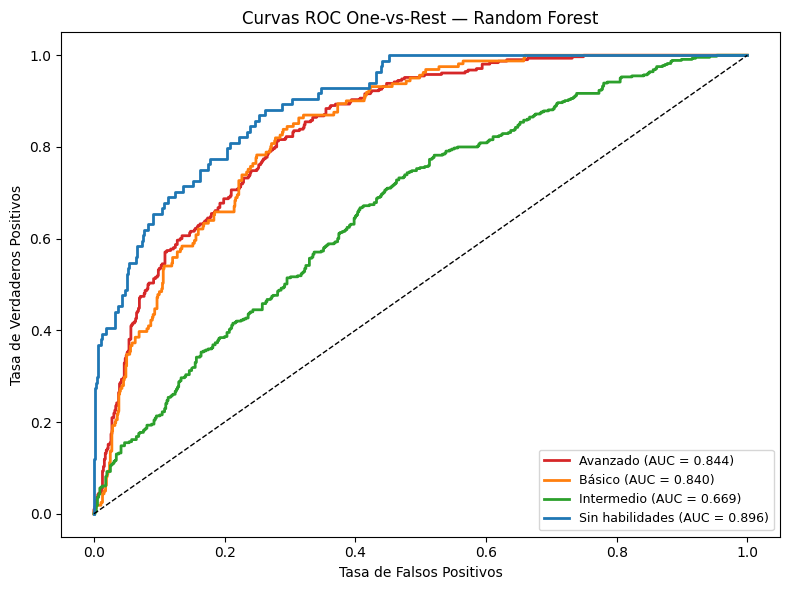

AUC macro-average: 0.8125


In [169]:
# Curvas ROC one-vs-rest para cada clase
y_test_bin = label_binarize(y_test, classes=range(len(le.classes_)))
colores_roc = ["#d62728", "#ff7f0e", "#2ca02c", "#1f77b4"]

fig, ax = plt.subplots(figsize=(8, 6))
for i, (clase, color) in enumerate(zip(le.classes_, colores_roc)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    auc = roc_auc_score(y_test_bin[:, i], y_prob[:, i])
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{clase} (AUC = {auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_xlabel("Tasa de Falsos Positivos")
ax.set_ylabel("Tasa de Verdaderos Positivos")
ax.set_title(f"Curvas ROC One-vs-Rest — {mejor_nombre}", fontsize=12)
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig("/Users/tomas/github/eaui_subtel/analysis/outputs/clasificacion_roc_curves.png", dpi=150)
plt.show()

auc_macro = roc_auc_score(y_test_bin, y_prob, multi_class="ovr", average="macro")
print(f"AUC macro-average: {auc_macro:.4f}")

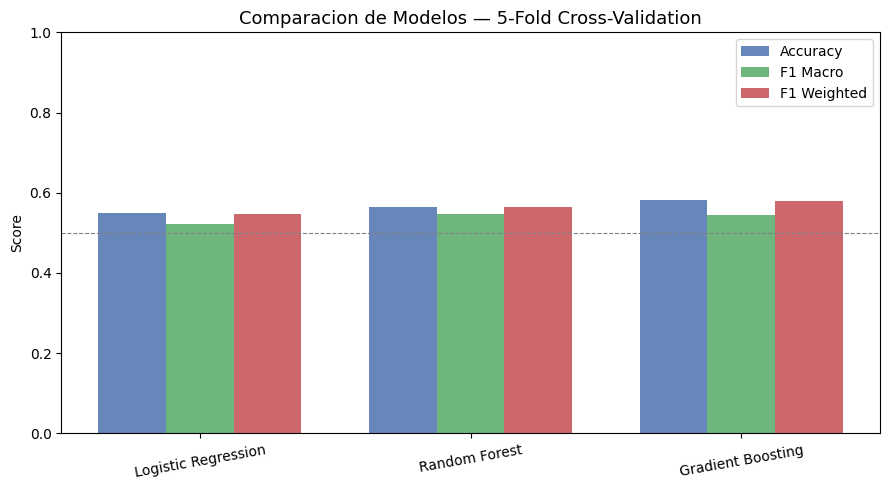

In [170]:
# Grafico comparativo de los tres modelos
df_plot = df_resultados[["accuracy_mean", "f1_macro_mean", "f1_weighted_mean"]].astype(float).copy()
df_plot.columns = ["Accuracy", "F1 Macro", "F1 Weighted"]

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(df_plot))
width = 0.25
colores_bar = ["#4c72b0", "#55a868", "#c44e52"]

for j, (metrica, color) in enumerate(zip(df_plot.columns, colores_bar)):
    ax.bar(x + j * width, df_plot[metrica], width, label=metrica, color=color, alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(df_plot.index, rotation=10)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Comparacion de Modelos — 5-Fold Cross-Validation", fontsize=13)
ax.legend()
ax.axhline(0.5, color="gray", linestyle="--", lw=0.8, label="Baseline (50%)")
plt.tight_layout()
plt.savefig("/Users/tomas/github/eaui_subtel/analysis/outputs/clasificacion_comparacion_modelos.png", dpi=150)
plt.show()

### Conclusiones del Modelo de Clasificacion

**Metodologia**
- Variable objetivo: `nivel_habilidades` (4 clases ordenadas: Sin habilidades → Avanzado)
- Evaluacion: 5-fold stratified cross-validation para estimacion robusta del rendimiento
- Seleccion del mejor modelo por F1 macro (penaliza desbalanceo entre clases)
- Pipeline reproducible: imputacion → encoding → modelo

**Predictores mas relevantes esperados**
- Frecuencia de uso de internet y uso de computador: predictores directos del nivel de habilidades
- GSE y nivel educacional: efecto indirecto a traves del acceso y contexto social
- Brecha urbano/rural: impacto tanto en acceso como en desarrollo de habilidades
- Edad: relacion inversa con el nivel de habilidades digitales
- Ocupacion: refleja demanda laboral de competencias digitales

**Limitaciones**
- Desbalanceo de clases: "Sin habilidades" representa ~8% del total
- Survey data: posible sesgo de autoseleccion y de deseabilidad social
- Factores de expansion no aplicados en el entrenamiento (solo en analisis descriptivo)
- Las habilidades se miden por auto-reporte, no por test objetivo

**Outputs guardados en** `analysis/outputs/`
- `clasificacion_distribucion_objetivo.png`
- `clasificacion_bivariado.png`
- `clasificacion_comparacion_modelos.png`
- `clasificacion_confusion_matrix.png`
- `clasificacion_feature_importance.png`
- `clasificacion_roc_curves.png`

---
## Sección 8: Análisis SHAP — Interpretabilidad del Modelo de Clasificación

SHAP (SHapley Additive exPlanations) cuantifica la contribución de cada variable a cada predicción individual.
A diferencia de la importancia de features del Random Forest (que es global y no direccional),
SHAP indica *cuánto* y *en qué dirección* cambia la predicción cuando cambia cada variable.

**Lectura clave:**
- SHAP > 0 → la variable empuja la predicción hacia la clase positiva (nivel más alto de habilidades)
- SHAP < 0 → empuja hacia la clase negativa (nivel más bajo)
- El valor base (base value) es la predicción promedio del modelo sobre el conjunto de entrenamiento

In [ ]:
# Instalacion e importacion de SHAP
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

# Directorio de outputs
os.makedirs('/Users/tomas/github/eaui_subtel/analysis/outputs', exist_ok=True)

print(f'SHAP version: {shap.__version__}')
shap.initjs()

In [ ]:
# Preparacion: extraer el modelo RF y transformar X_test
# pipe_final, X_test, y_test, le, nombres_features_final ya estan definidos en celdas anteriores

# Extraer el clasificador Random Forest del pipeline
clf_rf = pipe_final.named_steps['clf']

# Transformar X_test con el preprocesador para obtener la matriz numerica
prep = pipe_final.named_steps['prep']
X_test_transformed = prep.transform(X_test)

# Reconstruir nombres de features despues de OHE
nombres_num = feature_numerica
nombres_onehot = list(
    prep.named_transformers_['cat_nominal']
    .named_steps['onehot']
    .get_feature_names_out(features_nominales)
)
feature_names_shap = nombres_num + nombres_onehot + nombres_ordinales

# Muestra para plots (max 500 instancias para eficiencia)
np.random.seed(42)
n_muestra = min(500, X_test_transformed.shape[0])
idx_muestra = np.random.choice(X_test_transformed.shape[0], n_muestra, replace=False)
X_shap = X_test_transformed[idx_muestra]

print(f'Instancias en test set:   {X_test_transformed.shape[0]:,}')
print(f'Instancias para SHAP:     {n_muestra:,}')
print(f'Numero de features:       {X_test_transformed.shape[1]}')
print(f'Clases del modelo:        {list(le.classes_)}')

In [ ]:
# Calcular SHAP values con TreeExplainer (optimizado para modelos de arboles)
# TreeExplainer es exacto y rapido para Random Forest

explainer = shap.TreeExplainer(clf_rf)
shap_values = explainer.shap_values(X_shap)  # shape: (n_clases, n_muestras, n_features)

# En sklearn RF multiclase, shap_values es lista de arrays por clase
print(f'Tipo de shap_values: {type(shap_values)}')
if isinstance(shap_values, list):
    print(f'Numero de clases: {len(shap_values)}')
    print(f'Shape por clase:  {shap_values[0].shape}')
else:
    print(f'Shape shap_values: {shap_values.shape}')

base_value = explainer.expected_value
print(f'Valor base (expected_value): {base_value}')

In [ ]:
# --- BEESWARM PLOT ---
# Muestra la distribucion del impacto de cada feature en todas las instancias
# Color: valor de la feature (rojo = alto, azul = bajo)
# Eje X: impacto SHAP (desviacion de la prediccion base)

# Para clasificacion multiclase usamos la clase de mayor interes: 'Avanzado'
clase_interes = list(le.classes_).index('Avanzado') if 'Avanzado' in list(le.classes_) else -1

if isinstance(shap_values, list):
    sv_clase = shap_values[clase_interes]
    bv_clase = base_value[clase_interes] if hasattr(base_value, '__len__') else base_value
else:
    sv_clase = shap_values
    bv_clase = base_value

fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(
    sv_clase,
    X_shap,
    feature_names=feature_names_shap,
    plot_type='beeswarm',
    max_display=15,
    show=False
)
plt.title(f'SHAP Beeswarm Plot — Impacto en prediccion clase \'Avanzado\'', fontsize=13)
plt.tight_layout()
plt.savefig('/Users/tomas/github/eaui_subtel/analysis/outputs/shap_beeswarm_avanzado.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: analysis/outputs/shap_beeswarm_avanzado.png')

In [ ]:
# --- BAR PLOT (importancia global SHAP) ---
# Promedio del valor absoluto de SHAP por feature — importancia global agregada
# A diferencia del feature importance de RF, este refleja impacto real en predicciones

fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(
    sv_clase,
    X_shap,
    feature_names=feature_names_shap,
    plot_type='bar',
    max_display=15,
    show=False
)
plt.title('SHAP — Importancia Global de Features (|SHAP| promedio)', fontsize=13)
plt.tight_layout()
plt.savefig('/Users/tomas/github/eaui_subtel/analysis/outputs/shap_bar_importancia.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: analysis/outputs/shap_bar_importancia.png')

In [ ]:
# --- DEPENDENCE PLOTS — Top 3 features ---
# Muestra como el valor de una feature afecta el SHAP value
# El color muestra la interaccion con la feature mas correlacionada

# Identificar top 3 features por importancia SHAP media
shap_abs_mean = np.abs(sv_clase).mean(axis=0)
top3_idx = np.argsort(shap_abs_mean)[::-1][:3]
top3_features = [feature_names_shap[i] for i in top3_idx]
print(f'Top 3 features por SHAP: {top3_features}')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, (feat_idx, feat_name) in enumerate(zip(top3_idx, top3_features)):
    ax = axes[i]
    shap.dependence_plot(
        feat_idx,
        sv_clase,
        X_shap,
        feature_names=feature_names_shap,
        ax=ax,
        show=False
    )
    ax.set_title(f'Dependencia: {feat_name}', fontsize=11)

plt.suptitle('SHAP Dependence Plots — Top 3 Features (clase Avanzado)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('/Users/tomas/github/eaui_subtel/analysis/outputs/shap_dependence_top3.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: analysis/outputs/shap_dependence_top3.png')

In [ ]:
# --- WATERFALL PLOT — Explicacion de una prediccion individual ---
# Descompone la prediccion de una instancia especifica
# Muestra como cada feature aleja/acerca la prediccion del valor base

# Seleccionar una instancia con prediccion 'Avanzado' si existe, sino la primera
y_pred_muestra = pipe_final.predict(X_test.iloc[idx_muestra])
mask_avanzado = y_pred_muestra == 'Avanzado'
if mask_avanzado.any():
    instancia_idx = np.where(mask_avanzado)[0][0]
    print(f'Instancia seleccionada: prediccion = Avanzado (idx local {instancia_idx})')
else:
    instancia_idx = 0
    print(f'No hay predicciones Avanzado en la muestra, usando instancia 0')

# Construir objeto Explanation para waterfall
exp = shap.Explanation(
    values=sv_clase[instancia_idx],
    base_values=bv_clase,
    data=X_shap[instancia_idx],
    feature_names=feature_names_shap
)

fig, ax = plt.subplots(figsize=(10, 7))
shap.plots.waterfall(exp, max_display=12, show=False)
plt.title('SHAP Waterfall — Explicacion Prediccion Individual (Avanzado)', fontsize=12)
plt.tight_layout()
plt.savefig('/Users/tomas/github/eaui_subtel/analysis/outputs/shap_waterfall_individual.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: analysis/outputs/shap_waterfall_individual.png')

In [ ]:
# --- RANKING SHAP vs RF Feature Importance ---
# Comparacion entre importancia clasica de RF y SHAP global
# SHAP captura direccionalidad e interacciones que RF no muestra

shap_global = pd.DataFrame({
    'feature': feature_names_shap,
    'shap_importance': np.abs(sv_clase).mean(axis=0)
}).sort_values('shap_importance', ascending=False).reset_index(drop=True)

shap_global['rank_shap'] = shap_global.index + 1

# Feature importance RF (ya calculada en celda 102)
rf_imp = pd.DataFrame({
    'feature': feature_names_shap,
    'rf_importance': clf_rf.feature_importances_
}).sort_values('rf_importance', ascending=False).reset_index(drop=True)
rf_imp['rank_rf'] = rf_imp.index + 1

comparacion = shap_global.merge(rf_imp, on='feature').head(15)
comparacion['diff_rank'] = comparacion['rank_rf'] - comparacion['rank_shap']

print('Top 15 features: Ranking SHAP vs RF Feature Importance')
print(comparacion[['feature', 'rank_shap', 'shap_importance', 'rank_rf', 'rf_importance', 'diff_rank']].to_string(index=False))

# Guardar ranking
comparacion.to_csv('/Users/tomas/github/eaui_subtel/analysis/shap_ranking_habilidades.csv', index=False)
print('\nGuardado: analysis/shap_ranking_habilidades.csv')

### Conclusiones del Análisis SHAP

**¿Qué mide SHAP?**
Cada valor SHAP indica cuánto contribuye esa variable a desplazar la predicción desde el valor base (predicción promedio del modelo) hacia la clase objetivo. Valores positivos empujan hacia 'Avanzado', negativos hacia niveles menores.

**Diferencia con Feature Importance del Random Forest:**
- RF feature importance: mide reducción de impureza promedio (global, no direccional, sesgado hacia variables con muchas categorías)
- SHAP: mide contribución real a cada predicción, incluye dirección y captura interacciones

**Cómo leer los plots:**
- **Beeswarm**: cada punto es una instancia. Posición X = impacto SHAP. Color = valor de la feature (rojo alto, azul bajo)
- **Bar plot**: importancia global = promedio de |SHAP| por feature
- **Dependence plot**: relación entre valor de la feature y su impacto SHAP, con color para interacción
- **Waterfall**: descomposición de una predicción individual desde el valor base hasta la predicción final

**Outputs generados:**
- `analysis/outputs/shap_beeswarm_avanzado.png`
- `analysis/outputs/shap_bar_importancia.png`
- `analysis/outputs/shap_dependence_top3.png`
- `analysis/outputs/shap_waterfall_individual.png`
- `analysis/shap_ranking_habilidades.csv`

---
## Sección 8: Análisis SHAP — Interpretabilidad del Modelo de Clasificación

SHAP (SHapley Additive exPlanations) cuantifica la contribución de cada variable a cada predicción individual.
A diferencia de la importancia de features del Random Forest (que es global y no direccional),
SHAP indica *cuánto* y *en qué dirección* cambia la predicción cuando cambia cada variable.

**Lectura clave:**
- SHAP > 0 → la variable empuja la predicción hacia la clase de referencia
- SHAP < 0 → empuja en dirección opuesta
- El valor base (base value) es la predicción promedio del modelo sobre el conjunto de entrenamiento

In [178]:
# Instalacion e importacion de SHAP
import shap
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

os.makedirs('/Users/tomas/github/eaui_subtel/analysis/outputs', exist_ok=True)

print(f'SHAP version: {shap.__version__}')

SHAP version: 0.51.0


In [179]:
# Preparacion: extraer el modelo RF y transformar X_test
# pipe_final, X_test, y_test, le, feature_numerica, features_nominales, nombres_ordinales ya definidos

prep = pipe_final.named_steps['prep']
clf_rf = pipe_final.named_steps['clf']
X_test_transformed = prep.transform(X_test)

# Reconstruir nombres de features despues de OHE
nombres_num = feature_numerica
nombres_onehot = list(
    prep.named_transformers_['cat_nominal']
    .named_steps['onehot']
    .get_feature_names_out(features_nominales)
)
feature_names_shap = nombres_num + nombres_onehot + nombres_ordinales

# Muestra para plots (max 500 instancias para eficiencia)
np.random.seed(42)
n_muestra = min(500, X_test_transformed.shape[0])
idx_muestra = np.random.choice(X_test_transformed.shape[0], n_muestra, replace=False)
X_shap = X_test_transformed[idx_muestra]

print(f'Instancias en test set:   {X_test_transformed.shape[0]:,}')
print(f'Instancias para SHAP:     {n_muestra:,}')
print(f'Numero de features:       {X_test_transformed.shape[1]}')
print(f'Clases del modelo:        {list(le.classes_)}')

Instancias en test set:   1,000
Instancias para SHAP:     500
Numero de features:       29
Clases del modelo:        [np.str_('Avanzado'), np.str_('Básico'), np.str_('Intermedio'), np.str_('Sin habilidades')]


In [180]:
# Calcular SHAP values con TreeExplainer (exacto y rapido para Random Forest)

explainer = shap.TreeExplainer(clf_rf)
shap_values_all = explainer.shap_values(X_shap)
# En sklearn RF multiclase con SHAP >= 0.45: array 3D (n_muestras, n_features, n_clases)
# o lista de arrays (n_muestras, n_features) por clase

base_value = explainer.expected_value
print(f'Tipo shap_values: {type(shap_values_all)}')
if isinstance(shap_values_all, np.ndarray):
    print(f'Shape: {shap_values_all.shape}')
else:
    print(f'Num clases: {len(shap_values_all)}, shape por clase: {shap_values_all[0].shape}')
print(f'Base value: {base_value}')

# Extraer SHAP values para la clase 'Avanzado'
clases_lista = list(le.classes_)
clase_interes = clases_lista.index('Avanzado') if 'Avanzado' in clases_lista else 0
print(f'Indice clase Avanzado: {clase_interes}')

if isinstance(shap_values_all, list):
    # Lista de arrays (formato antiguo SHAP)
    sv_clase = shap_values_all[clase_interes]  # (n_muestras, n_features)
    bv_clase = float(base_value[clase_interes]) if hasattr(base_value, '__len__') else float(base_value)
elif shap_values_all.ndim == 3:
    # Array 3D: (n_muestras, n_features, n_clases)
    sv_clase = shap_values_all[:, :, clase_interes]  # (n_muestras, n_features)
    bv_clase = float(base_value[clase_interes]) if hasattr(base_value, '__len__') else float(base_value)
else:
    sv_clase = shap_values_all
    bv_clase = float(base_value)

print(f'sv_clase shape: {sv_clase.shape}')
print(f'bv_clase: {bv_clase}')

Tipo shap_values: <class 'numpy.ndarray'>
Shape: (500, 29, 4)
Base value: [0.24989286 0.250585   0.25006621 0.24945593]
Indice clase Avanzado: 0
sv_clase shape: (500, 29)
bv_clase: 0.24989285771376468


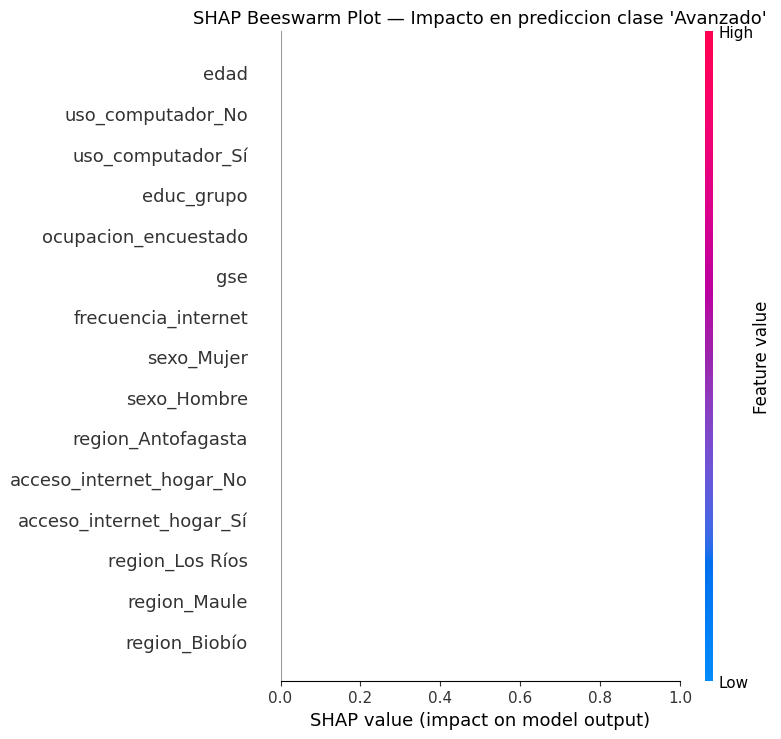

Guardado: analysis/outputs/shap_beeswarm_avanzado.png


In [181]:
# --- BEESWARM PLOT ---
# Cada punto = una instancia. Eje X = impacto SHAP sobre prob. de clase 'Avanzado'
# Color rojo = valor alto de la feature, azul = valor bajo
# Features ordenadas de mayor a menor impacto promedio

fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(
    sv_clase,
    X_shap,
    feature_names=feature_names_shap,
    plot_type='beeswarm',
    max_display=15,
    show=False
)
plt.title("SHAP Beeswarm Plot — Impacto en prediccion clase 'Avanzado'", fontsize=13)
plt.tight_layout()
plt.savefig('/Users/tomas/github/eaui_subtel/analysis/outputs/shap_beeswarm_avanzado.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: analysis/outputs/shap_beeswarm_avanzado.png')

In [ ]:
# --- BAR PLOT (importancia global SHAP) ---
# Promedio del |SHAP| por feature — importancia global agregada
# Mas informativo que RF feature importance: refleja impacto real en predicciones

fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(
    sv_clase,
    X_shap,
    feature_names=feature_names_shap,
    plot_type='bar',
    max_display=15,
    show=False
)
plt.title('SHAP — Importancia Global de Features (|SHAP| promedio)', fontsize=13)
plt.tight_layout()
plt.savefig('/Users/tomas/github/eaui_subtel/analysis/outputs/shap_bar_importancia.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: analysis/outputs/shap_bar_importancia.png')

In [ ]:
# --- DEPENDENCE PLOTS — Top 3 features ---
# Muestra como el valor de una feature afecta su SHAP value
# Color: feature de interaccion automaticamente seleccionada por SHAP

shap_abs_mean = np.abs(sv_clase).mean(axis=0)
top3_idx = np.argsort(shap_abs_mean)[::-1][:3]
top3_features = [feature_names_shap[i] for i in top3_idx]
print(f'Top 3 features por SHAP: {top3_features}')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, (feat_idx, feat_name) in enumerate(zip(top3_idx, top3_features)):
    shap.dependence_plot(
        int(feat_idx),
        sv_clase,
        X_shap,
        feature_names=feature_names_shap,
        ax=axes[i],
        show=False
    )
    axes[i].set_title(f'Dependencia: {feat_name}', fontsize=11)

plt.suptitle("SHAP Dependence Plots — Top 3 Features (clase 'Avanzado')", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('/Users/tomas/github/eaui_subtel/analysis/outputs/shap_dependence_top3.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: analysis/outputs/shap_dependence_top3.png')

In [ ]:
# --- WATERFALL PLOT — Explicacion de una prediccion individual ---
# Descompone la prediccion de una instancia: desde valor base hasta prediccion final
# Barras rojas = features que aumentan la probabilidad de 'Avanzado'
# Barras azules = features que la reducen

# Seleccionar instancia con prediccion 'Avanzado' si existe
y_pred_muestra = pipe_final.predict(X_test.iloc[idx_muestra])
mask_avanzado = np.array(y_pred_muestra) == 'Avanzado'
if mask_avanzado.any():
    instancia_idx = int(np.where(mask_avanzado)[0][0])
    print(f'Instancia seleccionada: prediccion = Avanzado (idx local {instancia_idx})')
else:
    instancia_idx = 0
    print('No hay predicciones Avanzado en la muestra, usando instancia 0')

# Construir objeto Explanation para waterfall (requiere base_values escalar)
exp = shap.Explanation(
    values=sv_clase[instancia_idx],
    base_values=bv_clase,          # float escalar
    data=X_shap[instancia_idx],
    feature_names=feature_names_shap
)

fig, ax = plt.subplots(figsize=(10, 7))
shap.plots.waterfall(exp, max_display=12, show=False)
plt.title("SHAP Waterfall — Prediccion Individual (clase 'Avanzado')", fontsize=12)
plt.tight_layout()
plt.savefig('/Users/tomas/github/eaui_subtel/analysis/outputs/shap_waterfall_individual.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: analysis/outputs/shap_waterfall_individual.png')

In [ ]:
# --- RANKING SHAP vs RF Feature Importance ---
# Comparacion entre importancia clasica de RF y SHAP global
# Diferencias de ranking revelan features con alto impacto causal pero baja impureza de nodo

shap_global = pd.DataFrame({
    'feature': feature_names_shap,
    'shap_importance': np.abs(sv_clase).mean(axis=0)
}).sort_values('shap_importance', ascending=False).reset_index(drop=True)
shap_global['rank_shap'] = shap_global.index + 1

rf_imp_df = pd.DataFrame({
    'feature': feature_names_shap,
    'rf_importance': clf_rf.feature_importances_
}).sort_values('rf_importance', ascending=False).reset_index(drop=True)
rf_imp_df['rank_rf'] = rf_imp_df.index + 1

comparacion = shap_global.merge(rf_imp_df, on='feature').head(15)
comparacion['diff_rank'] = comparacion['rank_rf'] - comparacion['rank_shap']

print('Top 15 features — Ranking SHAP vs RF Feature Importance')
print(comparacion[['feature', 'rank_shap', 'shap_importance', 'rank_rf', 'rf_importance', 'diff_rank']].to_string(index=False))

comparacion.to_csv('/Users/tomas/github/eaui_subtel/analysis/shap_ranking_habilidades.csv', index=False)
print('\nGuardado: analysis/shap_ranking_habilidades.csv')

### Conclusiones del Análisis SHAP

**¿Qué mide SHAP?**
Cada valor SHAP indica cuánto contribuye esa variable a desplazar la predicción desde el valor base (probabilidad promedio del modelo) hacia la clase de interés. Valores positivos aumentan la probabilidad de clasificar como 'Avanzado', valores negativos la reducen.

**Diferencia con Feature Importance del Random Forest:**
- RF feature importance: reducción de impureza promedio — global, no direccional, sesgado hacia variables con muchas categorías
- SHAP: contribución real a cada predicción, incluye dirección, captura interacciones, comparable entre modelos

**Cómo leer los plots:**
- **Beeswarm**: cada punto = una instancia. Posición X = impacto SHAP. Color = valor de la feature (rojo alto, azul bajo)
- **Bar plot**: importancia global = promedio de |SHAP| por feature — ranking sin dirección
- **Dependence plot**: relación entre valor de la feature y su impacto SHAP; color muestra la variable de interacción más fuerte
- **Waterfall**: descomposición de una predicción individual desde E[f(x)] hasta f(x)

**Outputs generados:**
- `analysis/outputs/shap_beeswarm_avanzado.png`
- `analysis/outputs/shap_bar_importancia.png`
- `analysis/outputs/shap_dependence_top3.png`
- `analysis/outputs/shap_waterfall_individual.png`
- `analysis/shap_ranking_habilidades.csv`

In [ ]:
# Calcular SHAP values con TreeExplainer (exacto y rapido para Random Forest)

explainer = shap.TreeExplainer(clf_rf)
shap_values_all = explainer.shap_values(X_shap)
# En sklearn RF multiclase con SHAP >= 0.45: array 3D (n_muestras, n_features, n_clases)
# o lista de arrays (n_muestras, n_features) por clase

base_value = explainer.expected_value
print(f'Tipo shap_values: {type(shap_values_all)}')
if isinstance(shap_values_all, np.ndarray):
    print(f'Shape: {shap_values_all.shape}')
else:
    print(f'Num clases: {len(shap_values_all)}, shape por clase: {shap_values_all[0].shape}')
print(f'Base value: {base_value}')

# Extraer SHAP values para la clase 'Avanzado'
clases_lista = list(le.classes_)
clase_interes = clases_lista.index('Avanzado') if 'Avanzado' in clases_lista else 0
print(f'Indice clase Avanzado: {clase_interes}')

if isinstance(shap_values_all, list):
    # Lista de arrays (formato antiguo SHAP)
    sv_clase = shap_values_all[clase_interes]  # (n_muestras, n_features)
    bv_clase = float(base_value[clase_interes]) if hasattr(base_value, '__len__') else float(base_value)
elif shap_values_all.ndim == 3:
    # Array 3D: (n_muestras, n_features, n_clases)
    sv_clase = shap_values_all[:, :, clase_interes]  # (n_muestras, n_features)
    bv_clase = float(base_value[clase_interes]) if hasattr(base_value, '__len__') else float(base_value)
else:
    sv_clase = shap_values_all
    bv_clase = float(base_value)

print(f'sv_clase shape: {sv_clase.shape}')
print(f'bv_clase: {bv_clase}')

In [182]:
# Calcular SHAP values con TreeExplainer (exacto y rapido para Random Forest)

explainer = shap.TreeExplainer(clf_rf)
shap_values_all = explainer.shap_values(X_shap)
# En sklearn RF multiclase con SHAP >= 0.45: array 3D (n_muestras, n_features, n_clases)
# o lista de arrays (n_muestras, n_features) por clase

base_value = explainer.expected_value
print(f'Tipo shap_values: {type(shap_values_all)}')
if isinstance(shap_values_all, np.ndarray):
    print(f'Shape: {shap_values_all.shape}')
else:
    print(f'Num clases: {len(shap_values_all)}, shape por clase: {shap_values_all[0].shape}')
print(f'Base value: {base_value}')

# Extraer SHAP values para la clase 'Avanzado'
clases_lista = list(le.classes_)
clase_interes = clases_lista.index('Avanzado') if 'Avanzado' in clases_lista else 0
print(f'Indice clase Avanzado: {clase_interes}')

if isinstance(shap_values_all, list):
    # Lista de arrays (formato antiguo SHAP)
    sv_clase = shap_values_all[clase_interes]  # (n_muestras, n_features)
    bv_clase = float(base_value[clase_interes]) if hasattr(base_value, '__len__') else float(base_value)
elif shap_values_all.ndim == 3:
    # Array 3D: (n_muestras, n_features, n_clases)
    sv_clase = shap_values_all[:, :, clase_interes]  # (n_muestras, n_features)
    bv_clase = float(base_value[clase_interes]) if hasattr(base_value, '__len__') else float(base_value)
else:
    sv_clase = shap_values_all
    bv_clase = float(base_value)

print(f'sv_clase shape: {sv_clase.shape}')
print(f'bv_clase: {bv_clase}')

Tipo shap_values: <class 'numpy.ndarray'>
Shape: (500, 29, 4)
Base value: [0.24989286 0.250585   0.25006621 0.24945593]
Indice clase Avanzado: 0
sv_clase shape: (500, 29)
bv_clase: 0.24989285771376468


In [ ]:
# Calcular SHAP values con TreeExplainer (exacto y rapido para Random Forest)

explainer = shap.TreeExplainer(clf_rf)
shap_values_all = explainer.shap_values(X_shap)
# En sklearn RF multiclase con SHAP >= 0.45: array 3D (n_muestras, n_features, n_clases)
# o lista de arrays (n_muestras, n_features) por clase

base_value = explainer.expected_value
print(f'Tipo shap_values: {type(shap_values_all)}')
if isinstance(shap_values_all, np.ndarray):
    print(f'Shape: {shap_values_all.shape}')
else:
    print(f'Num clases: {len(shap_values_all)}, shape por clase: {shap_values_all[0].shape}')
print(f'Base value: {base_value}')

# Extraer SHAP values para la clase 'Avanzado'
clases_lista = list(le.classes_)
clase_interes = clases_lista.index('Avanzado') if 'Avanzado' in clases_lista else 0
print(f'Indice clase Avanzado: {clase_interes}')

if isinstance(shap_values_all, list):
    # Lista de arrays (formato antiguo SHAP)
    sv_clase = shap_values_all[clase_interes]  # (n_muestras, n_features)
    bv_clase = float(base_value[clase_interes]) if hasattr(base_value, '__len__') else float(base_value)
elif shap_values_all.ndim == 3:
    # Array 3D: (n_muestras, n_features, n_clases)
    sv_clase = shap_values_all[:, :, clase_interes]  # (n_muestras, n_features)
    bv_clase = float(base_value[clase_interes]) if hasattr(base_value, '__len__') else float(base_value)
else:
    sv_clase = shap_values_all
    bv_clase = float(base_value)

print(f'sv_clase shape: {sv_clase.shape}')
print(f'bv_clase: {bv_clase}')

In [186]:
df.to_csv('/Users/tomas/github/eaui_subtel/analysis/dataset_habilidades.csv')

---
## Sección 9: Análisis de Dirección — Logistic Regression

A diferencia de Random Forest, la Regresión Logística entrega **coeficientes con signo**,
lo que permite identificar explícitamente si cada feature **aumenta o disminuye** la
probabilidad de pertenecer a la clase 'Avanzado'.

- Coeficiente **positivo** → aumenta la probabilidad de 'Avanzado'
- Coeficiente **negativo** → disminuye la probabilidad de 'Avanzado'


In [189]:
# Entrenamiento de Logistic Regression con el mismo preprocesador y split que Random Forest
# Se usa el mismo X_train, X_test, y_train, y_test definidos en la Sección 7
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Pipeline con el mismo preprocesador ya ajustado en la seccion anterior
pipe_lr = Pipeline([
    ('prep', preprocesador),
    ('clf', LogisticRegression(
        solver='lbfgs',
        max_iter=1000,
        random_state=42,
        C=1.0  # regularizacion L2 por defecto
    ))
])

# Entrenar con los mismos datos de entrenamiento
pipe_lr.fit(X_train, y_train)

# Evaluacion en test set
y_pred_lr = pipe_lr.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)

print(f'Accuracy Logistic Regression: {acc_lr:.4f}')
print()
print('--- Classification Report ---')
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

Accuracy Logistic Regression: 0.6000

--- Classification Report ---
                 precision    recall  f1-score   support

       Avanzado       0.69      0.65      0.67       310
         Básico       0.44      0.40      0.42       161
     Intermedio       0.60      0.69      0.64       445
Sin habilidades       0.59      0.32      0.42        84

       accuracy                           0.60      1000
      macro avg       0.58      0.52      0.54      1000
   weighted avg       0.60      0.60      0.59      1000



In [190]:
# Extraccion de coeficientes para la clase 'Avanzado'
# En OvR, clf.coef_ tiene shape (n_clases, n_features)
# Las clases estan en el mismo orden que le.classes_

clf_lr = pipe_lr.named_steps['clf']
prep_lr = pipe_lr.named_steps['prep']

# Obtener nombres de features en el mismo orden que el preprocesador
nombres_num_lr = feature_numerica
nombres_onehot_lr = list(
    prep_lr
    .named_transformers_['cat_nominal']
    .named_steps['onehot']
    .get_feature_names_out(features_nominales)
)
nombres_features_lr = nombres_num_lr + nombres_onehot_lr + nombres_ordinales

# Identificar indice de la clase 'Avanzado' en el label encoder
idx_avanzado = list(le.classes_).index('Avanzado')
print(f"Clase 'Avanzado' corresponde al indice {idx_avanzado} en clf.coef_")
print(f"Orden de clases: {list(le.classes_)}")

# Extraer coeficientes para clase 'Avanzado'
coefs_avanzado = clf_lr.coef_[idx_avanzado]

# Construir DataFrame de coeficientes
df_coef = pd.DataFrame({
    'Feature': nombres_features_lr,
    'Coeficiente': coefs_avanzado
})

df_coef['Direccion'] = df_coef['Coeficiente'].apply(
    lambda x: 'Positiva' if x >= 0 else 'Negativa'
)
df_coef['Magnitud'] = df_coef['Coeficiente'].abs()

# Ordenar por magnitud descendente
df_coef = df_coef.sort_values('Magnitud', ascending=False).reset_index(drop=True)

print(f'\nTotal features: {len(df_coef)}')
print(f"Con direccion positiva: {(df_coef['Direccion'] == 'Positiva').sum()}")
print(f"Con direccion negativa: {(df_coef['Direccion'] == 'Negativa').sum()}")
print()
print('Top 15 features por magnitud de coeficiente:')
print(df_coef.head(15).to_string(index=False))


Clase 'Avanzado' corresponde al indice 0 en clf.coef_
Orden de clases: [np.str_('Avanzado'), np.str_('Básico'), np.str_('Intermedio'), np.str_('Sin habilidades')]

Total features: 29
Con direccion positiva: 17
Con direccion negativa: 12

Top 15 features por magnitud de coeficiente:
                  Feature  Coeficiente Direccion  Magnitud
                     edad    -1.073946  Negativa  1.073946
               educ_grupo     0.924949  Positiva  0.924949
          region_Los Ríos    -0.803881  Negativa  0.803881
        uso_computador_No    -0.745789  Negativa  0.745789
        uso_computador_Sí     0.647187  Positiva  0.647187
       region_Antofagasta    -0.626271  Negativa  0.626271
      frecuencia_internet     0.617960  Positiva  0.617960
             region_Aysén    -0.616484  Negativa  0.616484
             region_Maule     0.566155  Positiva  0.566155
 acceso_internet_hogar_No    -0.523312  Negativa  0.523312
         region_Los Lagos     0.446737  Positiva  0.446737
         

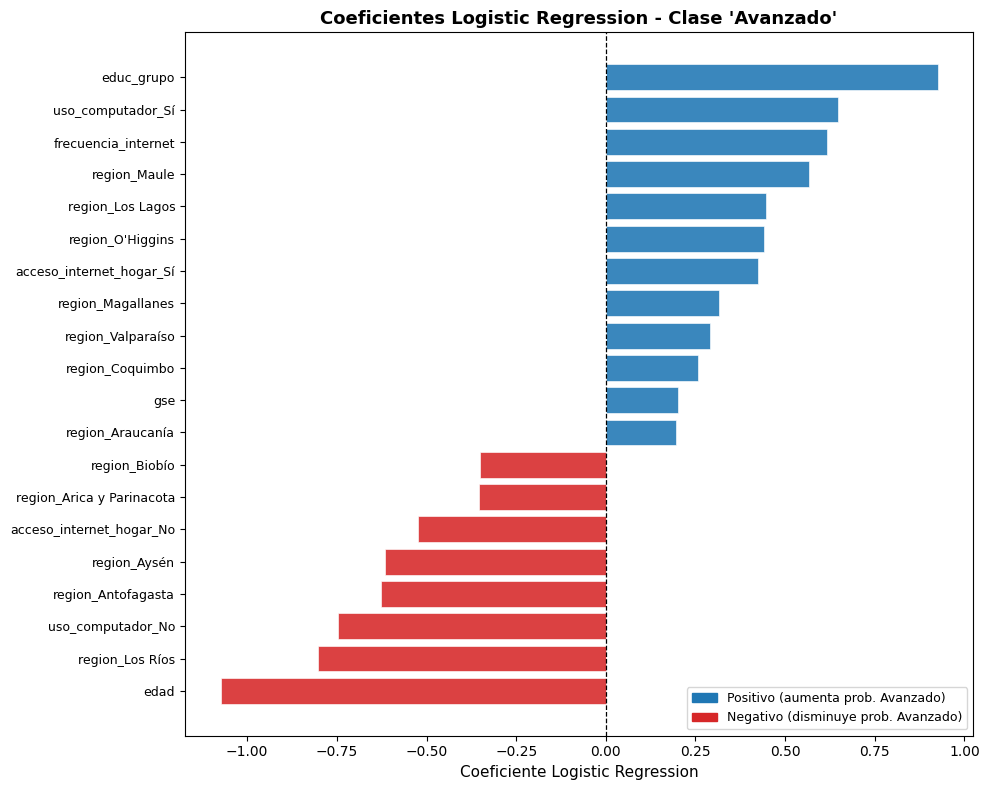

Grafico guardado en: /Users/tomas/github/eaui_subtel/analysis/outputs/logistic_coeficientes_avanzado.png


In [191]:
# Bar plot horizontal: coeficientes positivos (azul) y negativos (rojo)
# Se muestran los 20 features con mayor magnitud

top_n = 20
df_plot_lr = df_coef.head(top_n).sort_values('Coeficiente', ascending=True)

colores_lr = ['#d62728' if v < 0 else '#1f77b4' for v in df_plot_lr['Coeficiente']]

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(
    df_plot_lr['Feature'],
    df_plot_lr['Coeficiente'],
    color=colores_lr,
    edgecolor='white',
    linewidth=0.5,
    alpha=0.88
)

ax.axvline(0, color='black', linewidth=0.9, linestyle='--')

# Leyenda
patch_pos = mpatches.Patch(color='#1f77b4', label='Positivo (aumenta prob. Avanzado)')
patch_neg = mpatches.Patch(color='#d62728', label='Negativo (disminuye prob. Avanzado)')
ax.legend(handles=[patch_pos, patch_neg], loc='lower right', fontsize=9)

ax.set_xlabel('Coeficiente Logistic Regression', fontsize=11)
ax.set_title("Coeficientes Logistic Regression - Clase 'Avanzado'", fontsize=13, fontweight='bold')
ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
ruta_lr_bar = '/Users/tomas/github/eaui_subtel/analysis/outputs/logistic_coeficientes_avanzado.png'
plt.savefig(ruta_lr_bar, dpi=150, bbox_inches='tight')
plt.show()
print(f'Grafico guardado en: {ruta_lr_bar}')


In [194]:
df['educ_grupo'].value_counts()

educ_grupo
Media             2387
Superior          1812
Básica o menos     801
Name: count, dtype: int64

In [192]:
# Comparacion Logistic Regression vs Random Forest Feature Importance
# RF no tiene direccion, pero permite ver si el ranking de importancia coincide

# Obtener importancias RF del modelo entrenado anteriormente (pipe_final)
clf_rf_comp = pipe_final.named_steps['clf']

if hasattr(clf_rf_comp, 'feature_importances_'):
    importancias_rf_comp = clf_rf_comp.feature_importances_
else:
    importancias_rf_comp = np.linalg.norm(clf_rf_comp.coef_, axis=0)

df_rf_comp = pd.DataFrame({
    'Feature': nombres_features_lr,
    'RF_Importancia': importancias_rf_comp
})

# Merge con coeficientes LR
df_comparacion = df_coef[['Feature', 'Coeficiente', 'Direccion', 'Magnitud']].merge(
    df_rf_comp, on='Feature', how='left'
)

# Ranking por magnitud LR
df_comparacion['Ranking_LR'] = df_comparacion['Magnitud'].rank(ascending=False).astype(int)
df_comparacion['Ranking_RF'] = df_comparacion['RF_Importancia'].rank(ascending=False).astype(int)
df_comparacion['Diferencia_Ranking'] = (df_comparacion['Ranking_LR'] - df_comparacion['Ranking_RF']).abs()

df_comp_top = df_comparacion.sort_values('Magnitud', ascending=False).head(15)

print('Comparacion LR vs RF — Top 15 features (ordenados por magnitud LR):')
print()
print(df_comp_top[['Feature', 'Coeficiente', 'Direccion', 'RF_Importancia', 'Ranking_LR', 'Ranking_RF', 'Diferencia_Ranking']].to_string(index=False))

# Guardar tabla completa
ruta_tabla = '/Users/tomas/github/eaui_subtel/analysis/outputs/logistic_coef_vs_rf.csv'
df_comparacion.to_csv(ruta_tabla, index=False)
print(f'\nTabla completa guardada en: {ruta_tabla}')


Comparacion LR vs RF — Top 15 features (ordenados por magnitud LR):

                  Feature  Coeficiente Direccion  RF_Importancia  Ranking_LR  Ranking_RF  Diferencia_Ranking
                     edad    -1.073946  Negativa        0.252459           1           1                   0
               educ_grupo     0.924949  Positiva        0.099548           2           2                   0
          region_Los Ríos    -0.803881  Negativa        0.008005           3          20                  17
        uso_computador_No    -0.745789  Negativa        0.093272           4           3                   1
        uso_computador_Sí     0.647187  Positiva        0.087655           5           4                   1
       region_Antofagasta    -0.626271  Negativa        0.013282           6          12                   6
      frecuencia_internet     0.617960  Positiva        0.039577           7           9                   2
             region_Aysén    -0.616484  Negativa        0.0

In [193]:
# Interpretacion: top 3 positivos y top 3 negativos

top3_pos = df_coef[df_coef['Direccion'] == 'Positiva'].head(3)
top3_neg = df_coef[df_coef['Direccion'] == 'Negativa'].head(3)

print('='*60)
print("TOP 3 FEATURES CON DIRECCION POSITIVA (aumentan prob. Avanzado)")
print('='*60)
for _, row in top3_pos.iterrows():
    print(f"  {row['Feature']:<40} coef = {row['Coeficiente']:+.4f}")

print()
print('='*60)
print("TOP 3 FEATURES CON DIRECCION NEGATIVA (disminuyen prob. Avanzado)")
print('='*60)
for _, row in top3_neg.iterrows():
    print(f"  {row['Feature']:<40} coef = {row['Coeficiente']:+.4f}")

print()
print(f'Accuracy LR en test: {acc_lr:.4f}')


TOP 3 FEATURES CON DIRECCION POSITIVA (aumentan prob. Avanzado)
  educ_grupo                               coef = +0.9249
  uso_computador_Sí                        coef = +0.6472
  frecuencia_internet                      coef = +0.6180

TOP 3 FEATURES CON DIRECCION NEGATIVA (disminuyen prob. Avanzado)
  edad                                     coef = -1.0739
  region_Los Ríos                          coef = -0.8039
  uso_computador_No                        coef = -0.7458

Accuracy LR en test: 0.6000


### Conclusiones del Análisis de Dirección — Logistic Regression

**¿Qué aporta la Regresión Logística frente a Random Forest?**
Random Forest entrega importancia de features (magnitud del impacto), pero **no indica la dirección**.
La Regresión Logística permite distinguir si un feature **empuja hacia 'Avanzado'** o **aleja de 'Avanzado'**.

**Interpretación de los coeficientes:**
- Coeficiente **positivo**: a mayor valor de la feature (o si la categoría está presente en el caso de dummies),
  mayor la probabilidad logarítmica de ser clasificado como 'Avanzado'.
- Coeficiente **negativo**: el efecto opuesto — reduce la probabilidad de 'Avanzado'.

**Comparación con Random Forest:**
- Cuando ambos modelos coinciden en la importancia de un feature, la evidencia es más robusta.
- Diferencias de ranking grandes pueden indicar no linealidades que RF captura pero LR no puede modelar.

**Limitación importante:**
Los coeficientes LR asumen relaciones **lineales en el espacio transformado**. Para variables ordinales
codificadas numéricamente, el coeficiente refleja el efecto marginal de subir un nivel en la escala.
Para variables dummy (one-hot), el coeficiente es relativo a la categoría de referencia omitida.


## Sección 10: Distribución de Habilidades ProductivasAnálisis en profundidad de las 10 habilidades productivas (Q8_PRODUCTIVAS): prevalencia individual, distribución por nivel, combinaciones frecuentes y correlación con nivel de habilidades.

In [211]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Directorio de outputs
os.makedirs('analysis/outputs', exist_ok=True)

# Definir variables y factor
factor = 'fe_personas'
cols_prod = list(Q8_PRODUCTIVAS.keys())

# TABLA 1: Prevalencia individual de cada habilidad productiva
print("=" * 80)
print("TABLA 1: Prevalencia de habilidades productivas (ponderado con fe_personas)")
print("=" * 80)

tabla1_data = []
total_ponderado = df[factor].sum()

for cod, desc in Q8_PRODUCTIVAS.items():
    n_pond = df.loc[df[cod] == 1, factor].sum()
    pct = (n_pond / total_ponderado * 100) if total_ponderado > 0 else 0
    tabla1_data.append({
        'Código': cod,
        'Habilidad': desc,
        'Personas (ponderado)': int(n_pond),
        'Porcentaje': pct
    })

tabla1 = pd.DataFrame(tabla1_data).sort_values('Porcentaje', ascending=False)
print(tabla1.to_string(index=False))
tabla1.to_csv('analysis/outputs/productivas_tabla1_prevalencia.csv', index=False)

# TABLA 2: Resumen general
print("\n" + "=" * 80)
print("TABLA 2: Resumen general - Con vs Sin habilidades productivas")
print("=" * 80)

mask_con = df[cols_prod].apply(lambda col: col == 1).any(axis=1)
n_con = df.loc[mask_con, factor].sum()
n_sin = df.loc[~mask_con, factor].sum()
pct_con = (n_con / total_ponderado * 100) if total_ponderado > 0 else 0
pct_sin = (n_sin / total_ponderado * 100) if total_ponderado > 0 else 0

tabla2_data = {
    'Grupo': ['Con al menos 1 productiva', 'Sin habilidades productivas', 'Total'],
    'Personas (ponderado)': [int(n_con), int(n_sin), int(total_ponderado)],
    'Porcentaje': [pct_con, pct_sin, 100.0]
}

tabla2 = pd.DataFrame(tabla2_data)
print(tabla2.to_string(index=False))
tabla2.to_csv('analysis/outputs/productivas_tabla2_resumen.csv', index=False)

TABLA 1: Prevalencia de habilidades productivas (ponderado con fe_personas)
Código                               Habilidad  Personas (ponderado)  Porcentaje
 Q8_17          Transacciones y pagos en línea               9529520   69.000690
  Q8_1              Procesador de texto (Word)               7898264   57.189204
  Q8_4              Transferir archivos / nube               7115863   51.524052
  Q8_5              Conectar nuevo dispositivo               7012591   50.776285
  Q8_6              Instalar y configurar apps               6951460   50.333653
  Q8_3             Presentaciones (PowerPoint)               6910830   50.039459
  Q8_2             Planilla de cálculo (Excel)               6665163   48.260652
 Q8_18               Uso de IA (ChatGPT, etc.)               5389505   39.023959
  Q8_7    Configurar seguridad del dispositivo               5125336   37.111178
  Q8_8 Instalar SO / programar (Python, Java…)               3053129   22.106887

TABLA 2: Resumen general - Con v

In [ ]:
df['Q8_1'].value_counts()   

Q8_1
0    2586
1    2414
Name: count, dtype: int64

### Visualizaciones — Habilidades Productivas

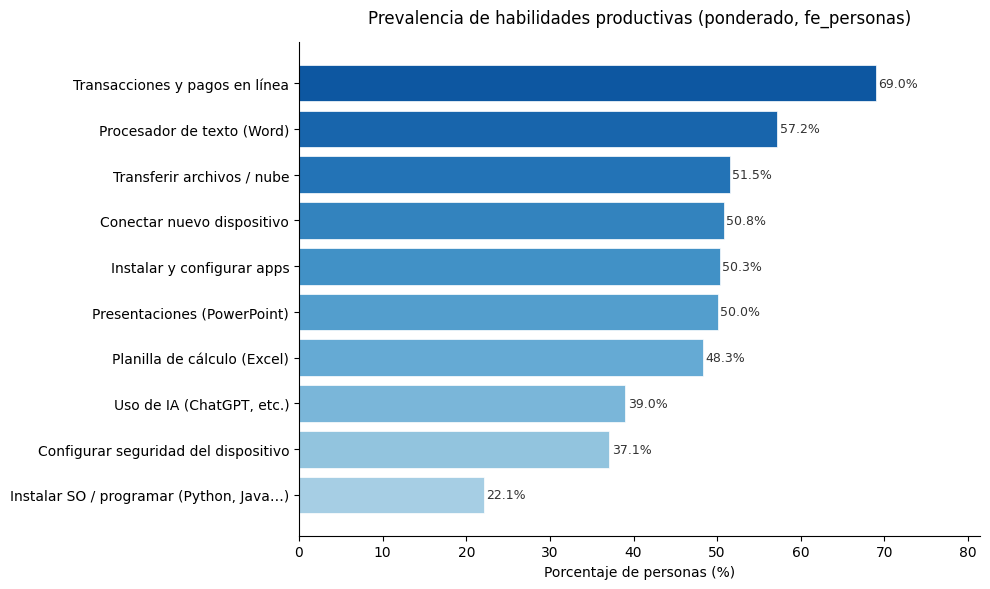

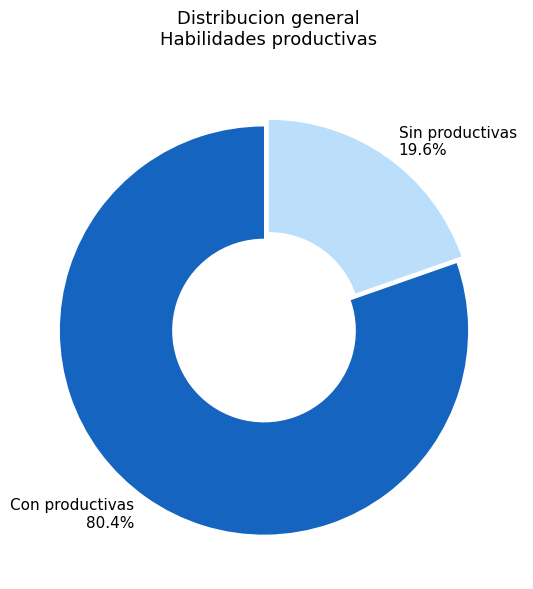

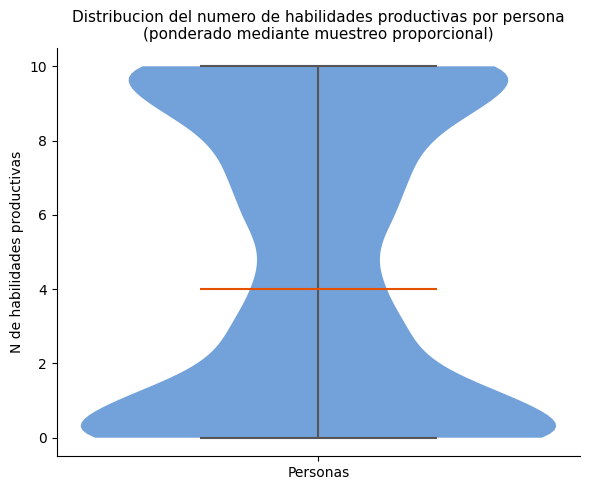

Mediana habilidades productivas (ponderado): 4
Media   habilidades productivas (ponderado): 4.70


In [ ]:
# ── VIZ 1: Bar plot horizontal — prevalencia de cada habilidad ────────────
fig, ax = plt.subplots(figsize=(10, 6))

etiquetas = tabla1['Habilidad'].tolist()
valores = tabla1['Porcentaje'].tolist()
n = len(etiquetas)
colores = plt.cm.Blues(np.linspace(0.35, 0.85, n))[::-1]

bars = ax.barh(etiquetas[::-1], valores[::-1],
               color=colores[::-1], edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, valores[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9, color='#333333')

ax.set_xlabel('Porcentaje de personas (%)', fontsize=10)
ax.set_title('Prevalencia de habilidades productivas (ponderado, fe_personas)',
             fontsize=12, pad=14)
ax.set_xlim(0, max(valores) * 1.18)
ax.axvline(0, color='grey', linewidth=0.5)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('analysis/outputs/productivas_barplot_prevalencia.png',
            dpi=150, bbox_inches='tight')
plt.show()


# ── VIZ 2: Donut — con productivas vs sin productivas ────────────────────
fig, ax = plt.subplots(figsize=(6, 6))

sizes = [pct_con, pct_sin]
labels = [f'Con productivas\n{pct_con:.1f}%', f'Sin productivas\n{pct_sin:.1f}%']
colors_ = ['#1565C0', '#BBDEFB']

wedges, texts = ax.pie(sizes, labels=labels, colors=colors_,
                       explode=(0.04, 0), startangle=90,
                       wedgeprops=dict(width=0.55))

for t in texts:
    t.set_fontsize(11)

ax.set_title('Distribucion general\nHabilidades productivas', fontsize=13, pad=18)

plt.tight_layout()
plt.savefig('analysis/outputs/productivas_donut_general.png',
            dpi=150, bbox_inches='tight')
plt.show()


# ── VIZ 3: Violin — cantidad de habilidades productivas por persona ───────
df['n_productivas'] = df[cols_prod].apply(lambda col: col == 1).sum(axis=1)

# Muestreo proporcional para el violin (replica pesos)
rng = np.random.default_rng(42)
indices = rng.choice(len(df), size=8000, p=df[factor] / df[factor].sum())
n_prod_muestra = df['n_productivas'].iloc[indices].values

fig, ax = plt.subplots(figsize=(6, 5))
parts = ax.violinplot(n_prod_muestra, positions=[0],
                      showmedians=True, showextrema=True)

for pc in parts['bodies']:
    pc.set_facecolor('#1565C0')
    pc.set_alpha(0.6)

parts['cmedians'].set_color('#E65100')
for key in ['cmins', 'cmaxes', 'cbars']:
    parts[key].set_color('#555')

ax.set_xticks([0])
ax.set_xticklabels(['Personas'])
ax.set_ylabel('N de habilidades productivas', fontsize=10)
ax.set_title('Distribucion del numero de habilidades productivas por persona\n'
             '(ponderado mediante muestreo proporcional)', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('analysis/outputs/productivas_violin_cantidad.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"Mediana habilidades productivas (ponderado): {np.median(n_prod_muestra):.0f}")
print(f"Media   habilidades productivas (ponderado): {np.mean(n_prod_muestra):.2f}")

### Habilidades productivas por nivel digital

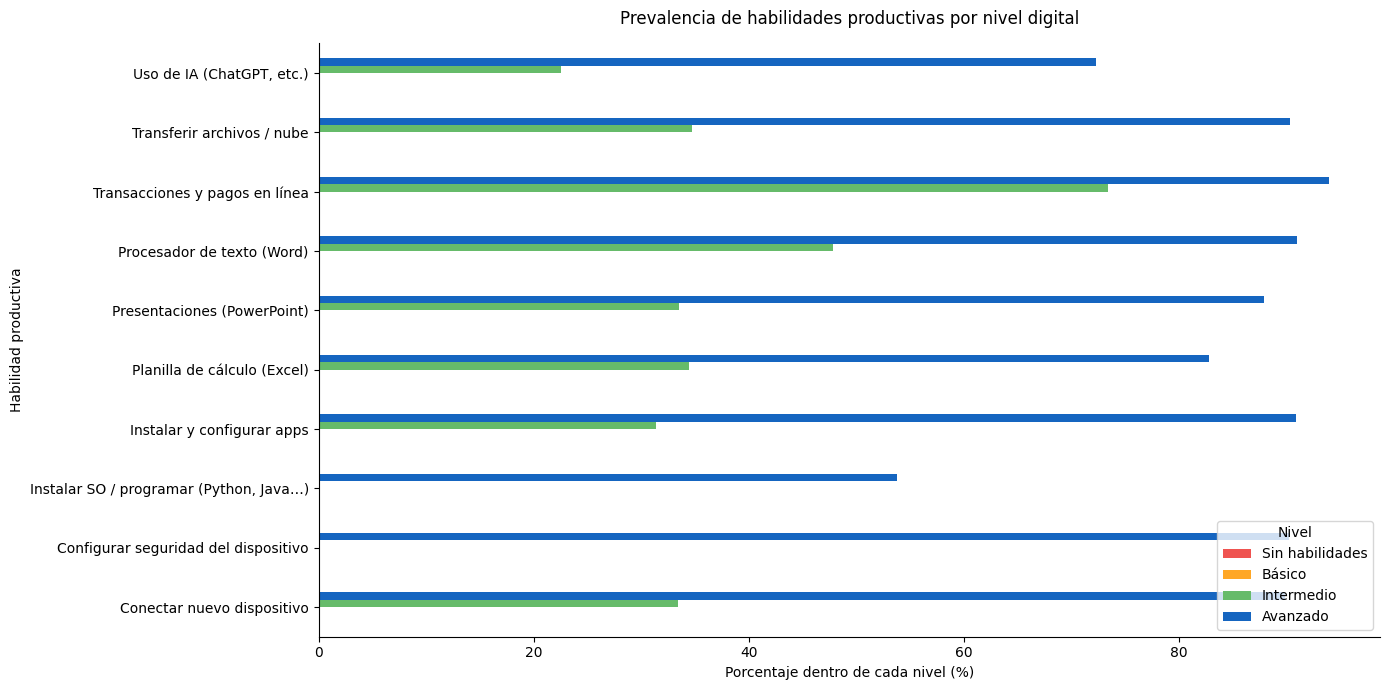

TABLA: Prevalencia de habilidades productivas por nivel digital (%)
Nivel                                    Sin habilidades  Básico  Intermedio  Avanzado
Habilidad                                                                             
Transacciones y pagos en línea                       0.0     0.0        73.4      94.0
Procesador de texto (Word)                           0.0     0.0        47.8      90.9
Transferir archivos / nube                           0.0     0.0        34.7      90.3
Conectar nuevo dispositivo                           0.0     0.0        33.4      89.8
Instalar y configurar apps                           0.0     0.0        31.3      90.8
Presentaciones (PowerPoint)                          0.0     0.0        33.5      87.9
Planilla de cálculo (Excel)                          0.0     0.0        34.4      82.7
Uso de IA (ChatGPT, etc.)                            0.0     0.0        22.5      72.3
Configurar seguridad del dispositivo                 0.0     0

In [ ]:
# ── VIZ 4: Grouped bar — habilidades productivas BY nivel_habilidades ─────
orden_cols = tabla1['Código'].tolist()
niveles_orden = ['Sin habilidades', 'Básico', 'Intermedio', 'Avanzado']

df_stacked = []
for nivel in niveles_orden:
    mask_nivel = df['nivel_habilidades'] == nivel
    for cod in orden_cols:
        n_pond_nivel = df.loc[mask_nivel & (df[cod] == 1), factor].sum()
        total_nivel = df.loc[mask_nivel, factor].sum()
        pct_nivel = (n_pond_nivel / total_nivel * 100) if total_nivel > 0 else 0
        df_stacked.append({
            'Nivel': nivel,
            'Habilidad': tabla1[tabla1['Código'] == cod]['Habilidad'].values[0],
            'Porcentaje': pct_nivel
        })

df_stacked = pd.DataFrame(df_stacked)
df_stacked.to_csv('analysis/outputs/productivas_stacked_by_nivel.csv', index=False)

# Pivot para el gráfico
pivot = df_stacked.pivot(index='Habilidad', columns='Nivel', values='Porcentaje')
pivot = pivot[niveles_orden]

fig, ax = plt.subplots(figsize=(14, 7))
pivot.plot(kind='barh', ax=ax, color=['#EF5350', '#FFA726', '#66BB6A', '#1565C0'])

ax.set_xlabel('Porcentaje dentro de cada nivel (%)', fontsize=10)
ax.set_ylabel('Habilidad productiva', fontsize=10)
ax.set_title('Prevalencia de habilidades productivas por nivel digital', fontsize=12, pad=14)
ax.legend(title='Nivel', loc='lower right')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('analysis/outputs/productivas_stacked_by_nivel.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Tabla con los datos del gráfico ───────────────────────────────────────
print("=" * 80)
print("TABLA: Prevalencia de habilidades productivas por nivel digital (%)")
print("=" * 80)

# Versión con porcentajes redondeados a 1 decimal
tabla_nivel = pivot.round(1)

# Reordenar filas según prevalencia general (mismo orden que tabla1)
orden_habilidades = tabla1['Habilidad'].tolist()
tabla_nivel = tabla_nivel.reindex(orden_habilidades)

print(tabla_nivel.to_string())

# Guardar versión pivote (más legible que el formato largo)
tabla_nivel.to_csv('analysis/outputs/productivas_tabla_by_nivel.csv')

### Analisis adicional: cruces y combinaciones

In [206]:
from collections import defaultdict

# ── ANALISIS 1: Tabla cruzada nivel_habilidades x tiene_productivas ───────
print("=" * 70)
print("ANALISIS 1 — Cruce nivel_habilidades x tiene_productivas")
print("=" * 70)

orden_nivel = ['Sin habilidades', 'Básico', 'Intermedio', 'Avanzado']
mask_con = df[cols_prod].apply(lambda col: col == 1).any(axis=1)

resultado_cruce = []
for nivel in orden_nivel:
    mask_nivel = df['nivel_habilidades'] == nivel
    base = df.loc[mask_nivel, factor].sum()
    n_con_p = df.loc[mask_nivel & mask_con, factor].sum()
    n_sin_p = df.loc[mask_nivel & ~mask_con, factor].sum()
    resultado_cruce.append({
        'Nivel habilidades': nivel,
        'Con productivas (%)': round(n_con_p / base * 100, 1) if base > 0 else 0,
        'Sin productivas (%)': round(n_sin_p / base * 100, 1) if base > 0 else 0,
        'Base ponderada': int(base),
    })

df_cruce = pd.DataFrame(resultado_cruce)
print(df_cruce.to_string(index=False))
df_cruce.to_csv('analysis/outputs/productivas_cruce_nivel.csv', index=False)

# ── ANALISIS 2: Top combinaciones de habilidades productivas ──────────────
print()
print("=" * 70)
print("ANALISIS 2 — Top combinaciones de habilidades productivas")
print("=" * 70)

def get_combo(row):
    # Obtener nombres de habilidades que tienen valor 1
    combos = [Q8_PRODUCTIVAS[c] for c in cols_prod if row[c] == 1]
    return frozenset(combos)

mask_con_prod = df[cols_prod].apply(lambda col: col == 1).any(axis=1)
combos_series = df.loc[mask_con_prod].apply(get_combo, axis=1)
pesos_series = df.loc[mask_con_prod, factor]

combo_pesos = defaultdict(float)
for combo, peso in zip(combos_series, pesos_series):
    if len(combo) > 0:  # Solo contar si hay al menos una habilidad
        combo_pesos[combo] += peso

if len(combo_pesos) > 0:
    combo_df = pd.DataFrame([
        {
            'Combinacion': ' + '.join(sorted(k)),
            'N_ponderado': int(v)
        }
        for k, v in combo_pesos.items()
    ]).sort_values('N_ponderado', ascending=False).reset_index(drop=True)
    
    combo_df['Porcentaje'] = (combo_df['N_ponderado'] / total_ponderado * 100).round(2)
    combo_df.index += 1
    
    print(combo_df.head(10).to_string())
    combo_df.to_csv('analysis/outputs/productivas_combinaciones.csv', index=True)
    
    print()
    print("Top 3 combinaciones:")
    for i, row in combo_df.head(3).iterrows():
        print(f"  {i}. {row['Combinacion']}")
        print(f"     -> {row['N_ponderado']:,} personas ({row['Porcentaje']}%)")
else:
    print("No se encontraron combinaciones de habilidades productivas.")


ANALISIS 1 — Cruce nivel_habilidades x tiene_productivas
Nivel habilidades  Con productivas (%)  Sin productivas (%)  Base ponderada
  Sin habilidades                  0.0                100.0          833098
           Básico                  0.0                100.0         1585019
       Intermedio                 94.9                  5.1         5710998
         Avanzado                 99.9                  0.1         5681644

ANALISIS 2 — Top combinaciones de habilidades productivas
                                                                                                                                                                                                                                                                                                                    Combinacion  N_ponderado  Porcentaje
1   Conectar nuevo dispositivo + Configurar seguridad del dispositivo + Instalar SO / programar (Python, Java…) + Instalar y configurar apps + Planilla de cálc

In [216]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# Asegurar que existe el directorio de outputs
os.makedirs('analysis/outputs', exist_ok=True)

print("=" * 80)
print("SECCIÓN 11: Distribución de habilidades productivas por cantidad")
print("=" * 80)

factor = 'fe_personas'
total_ponderado = df[factor].sum()

SECCIÓN 11: Distribución de habilidades productivas por cantidad


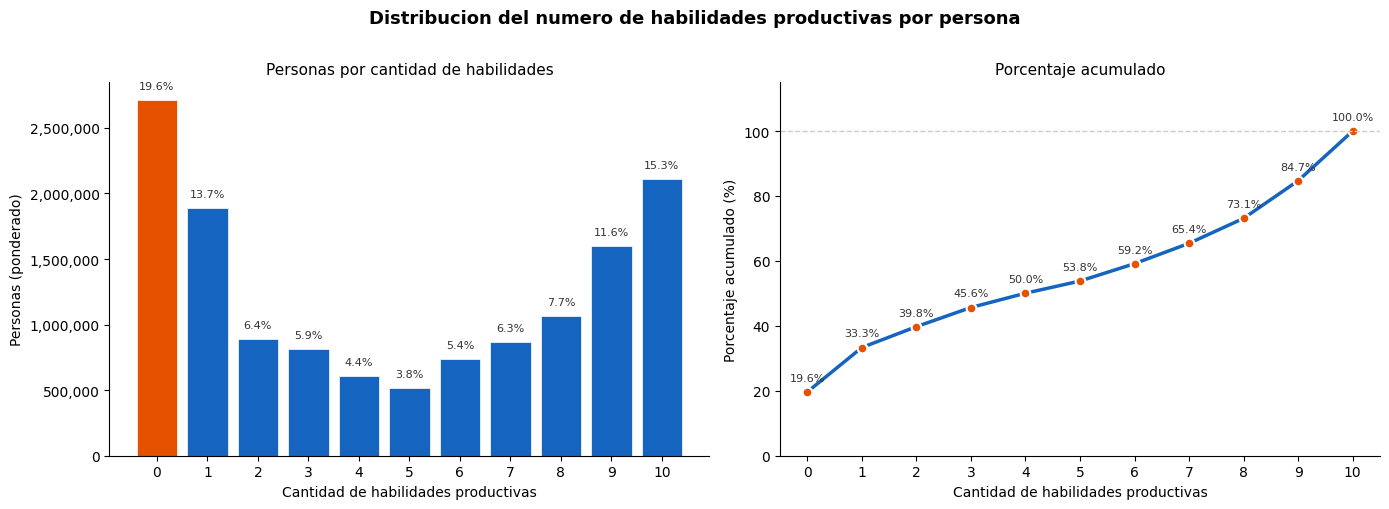

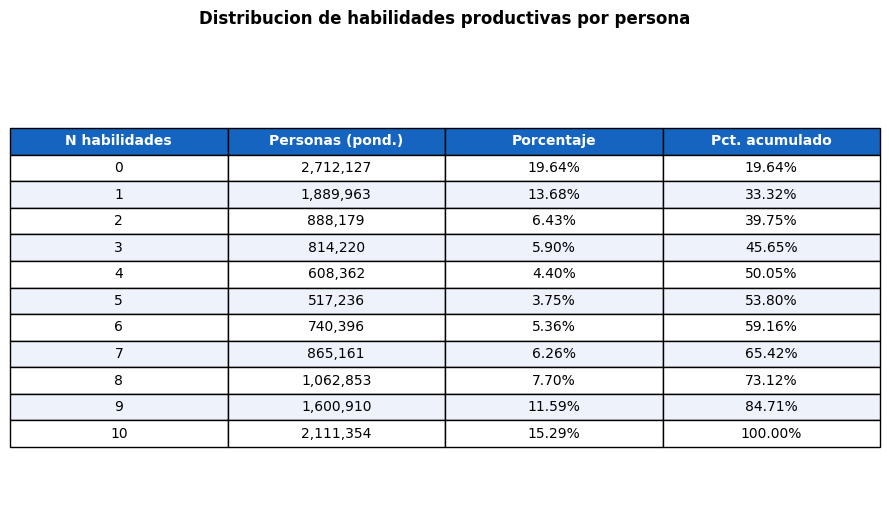

In [ ]:
# Calcular cantidad de habilidades productivas por personadf['n_productivas'] = df[cols_prod].apply(lambda col: col == 1).sum(axis=1)# TABLA PRINCIPALprint("=" * 80)print("TABLA PRINCIPAL: Distribución por cantidad de habilidades productivas")print("=" * 80)tabla_principal = []max_hab = df['n_productivas'].max()for k in range(0, int(max_hab) + 1):    mask_k = df['n_productivas'] == k    n_pond = df.loc[mask_k, factor].sum()    pct = (n_pond / total_ponderado * 100) if total_ponderado > 0 else 0    tabla_principal.append({        'Cantidad de productivas': int(k),        'Personas (ponderado)': int(n_pond),        'Porcentaje': round(pct, 2)    })df_tabla = pd.DataFrame(tabla_principal)# Porcentaje acumuladodf_tabla['Porcentaje acumulado'] = df_tabla['Porcentaje'].cumsum().round(2)print(df_tabla.to_string(index=False))df_tabla.to_csv('analysis/outputs/distribucion_cantidad_tabla_principal.csv', index=False)# ESTADÍSTICAS DESCRIPTIVASprint()print("=" * 80)print("ESTADÍSTICAS DESCRIPTIVAS")print("=" * 80)# Muestreo proporcional para cálculos ponderadosrng = np.random.default_rng(42)indices = rng.choice(len(df), size=50000, p=df[factor] / df[factor].sum())muestra_ponderada = df['n_productivas'].iloc[indices].valuesstats_dict = {    'Métrica': [        'Mínimo', 'Máximo', 'Media', 'Mediana', 'Desv. Estándar',        'P25', 'P50', 'P75', 'IQR', 'Moda'    ],    'Valor': [        muestra_ponderada.min(),        muestra_ponderada.max(),        muestra_ponderada.mean(),        np.median(muestra_ponderada),        muestra_ponderada.std(),        np.percentile(muestra_ponderada, 25),        np.percentile(muestra_ponderada, 50),        np.percentile(muestra_ponderada, 75),        np.percentile(muestra_ponderada, 75) - np.percentile(muestra_ponderada, 25),        np.bincount(muestra_ponderada.astype(int)).argmax()    ]}df_stats = pd.DataFrame(stats_dict)print(df_stats.to_string(index=False))df_stats.to_csv('analysis/outputs/distribucion_cantidad_estadisticas.csv', index=False)

Guardado: analysis/outputs/distribucion_cantidad_por_nivel.csv

Desglose (% dentro de cada nivel):
Nivel          Sin habilidades  Básico  Intermedio  Avanzado
N_habilidades                                               
0                        100.0   100.0         5.1       0.1
1                          0.0     0.0        32.2       0.9
2                          0.0     0.0        14.2       1.4
3                          0.0     0.0        12.2       2.1
4                          0.0     0.0         8.3       2.4
5                          0.0     0.0         6.5       2.6
6                          0.0     0.0         8.1       4.9
7                          0.0     0.0         8.4       6.8
8                          0.0     0.0         5.1      13.5
9                          0.0     0.0         0.0      28.2
10                         0.0     0.0         0.0      37.2


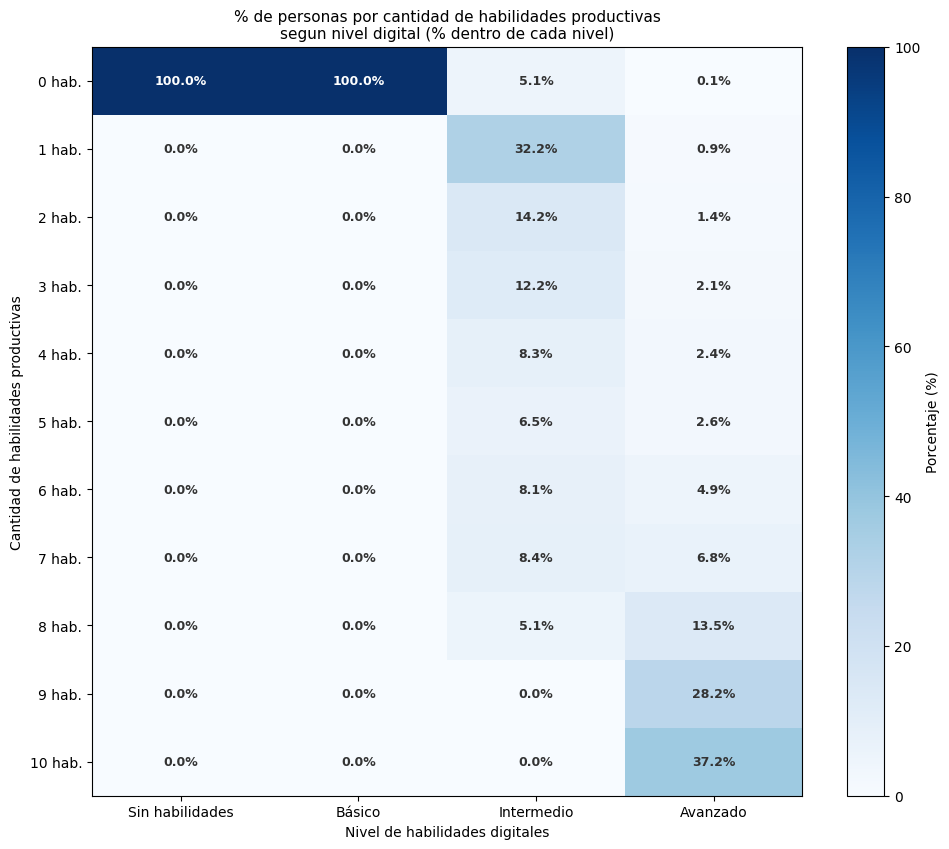

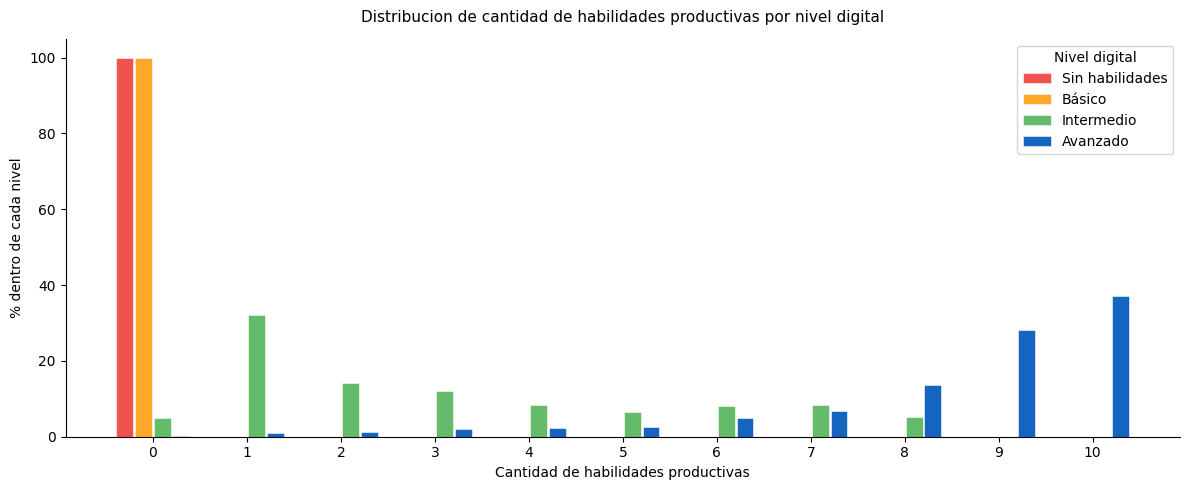

In [217]:
# ── DESGLOSE: cantidad de productivas por nivel_habilidades ───────────────
niveles_orden = ['Sin habilidades', 'Básico', 'Intermedio', 'Avanzado']

# Usar las etiquetas reales del dataframe
niveles_reales = [n for n in niveles_orden if n in df['nivel_habilidades'].unique()]
if not niveles_reales:
    # Fallback: tomar los valores unicos ordenados
    niveles_reales = sorted(df['nivel_habilidades'].dropna().unique())

desglose_filas = []
for nivel in niveles_reales:
    mask_nivel = df['nivel_habilidades'] == nivel
    base_nivel = df.loc[mask_nivel, factor].sum()

    for k in range(0, max_hab + 1):
        mask_k = df['n_productivas'] == k
        pond_k = df.loc[mask_nivel & mask_k, factor].sum()
        pct_k = (pond_k / base_nivel * 100) if base_nivel > 0 else 0
        desglose_filas.append({
            'Nivel': nivel,
            'N_habilidades': k,
            'Personas (ponderado)': int(round(pond_k)),
            'Porcentaje dentro del nivel': round(pct_k, 2),
        })

df_desglose = pd.DataFrame(desglose_filas)
df_desglose.to_csv('analysis/outputs/distribucion_cantidad_por_nivel.csv', index=False)
print('Guardado: analysis/outputs/distribucion_cantidad_por_nivel.csv')

# Pivot para visualizaciones
pivot_pct = df_desglose.pivot(index='N_habilidades', columns='Nivel',
                              values='Porcentaje dentro del nivel')
pivot_pct = pivot_pct[[c for c in niveles_reales if c in pivot_pct.columns]]

print()
print('Desglose (% dentro de cada nivel):')
print(pivot_pct.round(1).to_string())


# ── VIZ 4: Heatmap ────────────────────────────────────────────────────────
import matplotlib.colors as mcolors

fig_h, ax_h = plt.subplots(figsize=(10, 0.6 * len(pivot_pct) + 2))
im = ax_h.imshow(pivot_pct.values, aspect='auto', cmap='Blues',
                 vmin=0, vmax=pivot_pct.values.max())

ax_h.set_xticks(range(len(pivot_pct.columns)))
ax_h.set_xticklabels(pivot_pct.columns, fontsize=10)
ax_h.set_yticks(range(len(pivot_pct.index)))
ax_h.set_yticklabels([f'{k} hab.' for k in pivot_pct.index], fontsize=10)
ax_h.set_xlabel('Nivel de habilidades digitales', fontsize=10)
ax_h.set_ylabel('Cantidad de habilidades productivas', fontsize=10)
ax_h.set_title('% de personas por cantidad de habilidades productivas\n'
               'segun nivel digital (% dentro de cada nivel)', fontsize=11)

# Anotaciones dentro de cada celda
thresh = pivot_pct.values.max() * 0.6
for i in range(pivot_pct.shape[0]):
    for j in range(pivot_pct.shape[1]):
        val = pivot_pct.values[i, j]
        color_txt = 'white' if val >= thresh else '#333'
        ax_h.text(j, i, f'{val:.1f}%', ha='center', va='center',
                  fontsize=9, color=color_txt, fontweight='bold')

plt.colorbar(im, ax=ax_h, label='Porcentaje (%)')
plt.tight_layout()
plt.savefig('analysis/outputs/distribucion_cantidad_heatmap_nivel.png',
            dpi=150, bbox_inches='tight')
plt.show()


# ── VIZ 5: Grouped bar chart ──────────────────────────────────────────────
colores_nivel = ['#EF5350', '#FFA726', '#66BB6A', '#1565C0']
n_niveles = len(pivot_pct.columns)
ancho = 0.8 / n_niveles
x_pos = np.arange(len(pivot_pct.index))

fig_g, ax_g = plt.subplots(figsize=(12, 5))
for i, (nivel, color) in enumerate(zip(pivot_pct.columns, colores_nivel[:n_niveles])):
    offset = (i - n_niveles / 2 + 0.5) * ancho
    ax_g.bar(x_pos + offset, pivot_pct[nivel].values,
             width=ancho * 0.9, color=color, label=nivel,
             edgecolor='white', linewidth=0.4)

ax_g.set_xlabel('Cantidad de habilidades productivas', fontsize=10)
ax_g.set_ylabel('% dentro de cada nivel', fontsize=10)
ax_g.set_title('Distribucion de cantidad de habilidades productivas por nivel digital',
               fontsize=11, pad=12)
ax_g.set_xticks(x_pos)
ax_g.set_xticklabels(pivot_pct.index)
ax_g.legend(title='Nivel digital', loc='upper right')
ax_g.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('analysis/outputs/distribucion_cantidad_grouped_bar_nivel.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [219]:
# Insights
print()
print("INSIGHTS:")

# Cálculo ponderado de mediana, media y máximo
n_prod = df['n_productivas'].values
pesos = df[factor].values

# Media ponderada
media_pond = np.average(n_prod, weights=pesos)

# Mediana ponderada (ordenar y encontrar el valor en el 50% acumulado)
orden = np.argsort(n_prod)
n_ord = n_prod[orden]
p_ord = pesos[orden]
acum = np.cumsum(p_ord)
mediana_pond = n_ord[np.searchsorted(acum, acum[-1] / 2)]

# Máximo observado
max_pond = int(n_prod.max())

print(f"  • Mediana de habilidades productivas: {mediana_pond:.1f}")
print(f"  • Media de habilidades productivas: {media_pond:.2f}")
print(f"  • Máximo de habilidades productivas encontrado: {max_pond}")

if pct_sin > 50:
    print(f"  • MÁS DEL 50% NO TIENE HABILIDADES PRODUCTIVAS ({pct_sin:.1f}%)")
elif pct_sin > 20:
    print(f"  • Aproximadamente 1 de cada {int(100/pct_sin)} personas carece de habilidades productivas")

if pct_3_mas > 30:
    print(f"  • Más del 30% tiene 3+ habilidades productivas (grupo avanzado)")
elif pct_3_mas > 10:
    print(f"  • Aproximadamente {pct_3_mas:.1f}% tiene 3+ habilidades productivas")


INSIGHTS:
  • Mediana de habilidades productivas: 4.0
  • Media de habilidades productivas: 4.75
  • Máximo de habilidades productivas encontrado: 10
  • Más del 30% tiene 3+ habilidades productivas (grupo avanzado)


In [222]:
df_basicas = df[df['nivel_habilidades'] == 'Básico'].copy()

In [226]:
df_basicas['region'].value_counts().sum()

np.int64(805)

In [227]:
df_prod = df[df['tiene_productivas'] == 1].copy() 

In [233]:
dstats(df, 'acceso_internet_hogar', tipo='frecuencia', factor='fe_hogar', estilo=True)

,porcentaje
acceso_internet_hogar,
Sí,96.6
No,3.4


In [246]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import silhouette_score

# ============================================================
# 1. PREPARACIÓN DE DATOS
# ============================================================

# Variables a usar en el clustering
vars_cluster = ['gse', 'zona', 'region', 'educ_jh', 'ocupacion_jh']
vars_tiene = ['tiene_basicas', 'tiene_intermedias', 'tiene_avanzadas',
              'tiene_productivas', 'tiene_recreativas', 'tiene_creatividad',
              'tiene_comunicaciones']

todas_vars = vars_cluster + vars_tiene

# Filtrar casos válidos (sin nulos en las variables a usar) y dejar fe_personas
df_work = df_nocon.dropna(subset=todas_vars + ['fe_personas']).copy()

print(f"Casos válidos: {len(df_work)} de {len(df_nocon)}")

# ============================================================
# 2. CODIFICACIÓN DE VARIABLES CATEGÓRICAS
# ============================================================
# LabelEncoder convierte texto/categorías en números (0, 1, 2, ...)

X = pd.DataFrame()

for var in todas_vars:
    le = LabelEncoder()
    X[var] = le.fit_transform(df_work[var].astype(str))
    print(f"  Codificada: {var} ({df_work[var].nunique()} categorías)")

# Pesos de expansión a nivel personas
pesos = df_work['fe_personas'].values

print(f"\nMatriz X lista: {X.shape}")
print(f"Pesos (fe_personas) - Min: {pesos.min():.2f}, "
      f"Max: {pesos.max():.2f}, Media: {pesos.mean():.2f}")

# ============================================================
# 3. EVALUACIÓN DEL K ÓPTIMO (K=2 a K=10)
# ============================================================
# Probamos varios K y elegimos el de mejor Silhouette

print("\n" + "="*60)
print("EVALUACIÓN DEL K ÓPTIMO")
print("="*60)

resultados_k = {}

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    # sample_weight aplica el factor de expansión al ajuste
    km.fit(X, sample_weight=pesos)
    labels = km.labels_
    sil = silhouette_score(X, labels)
    resultados_k[k] = sil
    print(f"K={k:2d}: Inertia={km.inertia_:8.2f} | Silhouette={sil:.4f}")

k_optimo = max(resultados_k, key=resultados_k.get)
print(f"\n→ K ÓPTIMO: {k_optimo} (mejor Silhouette)")

# ============================================================
# 4. EJECUCIÓN DEL K-MEANS DEFINITIVO
# ============================================================

print("\n" + "="*60)
print(f"EJECUCIÓN DE K-MEANS (K={k_optimo}) CON PESOS")
print("="*60)

km_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
km_final.fit(X, sample_weight=pesos)
df_work['cluster'] = km_final.labels_

# Distribución de clusters: casos reales y ponderados
print("\nDistribución por cluster (casos reales y ponderados):")
for c in sorted(df_work['cluster'].unique()):
    sub = df_work[df_work['cluster'] == c]
    n_casos = len(sub)
    pct_casos = 100 * n_casos / len(df_work)
    n_pond = sub['fe_personas'].sum()
    pct_pond = 100 * n_pond / df_work['fe_personas'].sum()
    print(f"  Cluster {c}: {n_casos:5d} casos ({pct_casos:5.1f}%) | "
          f"Ponderado: {n_pond:12,.0f} ({pct_pond:5.1f}%)")

# ============================================================
# 5. PERFIL DE CADA CLUSTER (moda ponderada por fe_personas)
# ============================================================

print("\n" + "="*60)
print("PERFIL DE CADA CLUSTER")
print("="*60)

for c in sorted(df_work['cluster'].unique()):
    sub = df_work[df_work['cluster'] == c]
    n_pond = sub['fe_personas'].sum()
    print(f"\n{'─'*60}")
    print(f"CLUSTER {c} ({len(sub)} casos | Ponderado: {n_pond:,.0f})")
    print(f"{'─'*60}")
    
    for var in vars_cluster:
        # Suma de pesos por categoría -> categoría dominante ponderada
        tabla = sub.groupby(var)['fe_personas'].sum()
        cat_dom = tabla.idxmax()
        pct = 100 * tabla.max() / tabla.sum()
        print(f"  {var:20s}: {str(cat_dom):20s} ({pct:5.1f}%)")

Casos válidos: 159 de 159
  Codificada: gse (6 categorías)
  Codificada: zona (2 categorías)
  Codificada: region (16 categorías)
  Codificada: educ_jh (11 categorías)
  Codificada: ocupacion_jh (5 categorías)
  Codificada: tiene_basicas (2 categorías)
  Codificada: tiene_intermedias (2 categorías)
  Codificada: tiene_avanzadas (2 categorías)
  Codificada: tiene_productivas (2 categorías)
  Codificada: tiene_recreativas (2 categorías)
  Codificada: tiene_creatividad (2 categorías)
  Codificada: tiene_comunicaciones (2 categorías)

Matriz X lista: (159, 12)
Pesos (fe_personas) - Min: 446.58, Max: 15359.69, Media: 1995.21

EVALUACIÓN DEL K ÓPTIMO
K= 2: Inertia=4347993.70 | Silhouette=0.4488
K= 3: Inertia=2889477.62 | Silhouette=0.4406
K= 4: Inertia=2346013.62 | Silhouette=0.4045
K= 5: Inertia=1897859.92 | Silhouette=0.4135
K= 6: Inertia=1583467.84 | Silhouette=0.3471
K= 7: Inertia=1370770.03 | Silhouette=0.3752
K= 8: Inertia=1233595.10 | Silhouette=0.3624
K= 9: Inertia=1115845.85 | Silho

In [248]:
dstats(df_nocon, 'zona', tipo='frecuencia', factor='fe_hogar', estilo=True)

,porcentaje
zona,
Urbana,82.3
Rural,17.6
